# Carga DATASETS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import requests
import os
import zipfile
import io
import warnings
import itertools
import re

In [2]:
#conectar a drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
folder_path = '/content/drive/MyDrive/Maestría en Data Mining/Taller de Tesis I/Final V6'
os.makedirs(folder_path, exist_ok=True)

path_images = "/content/drive/MyDrive/Maestría en Data Mining/Taller de Tesis I/Final V6/Gráficos"
os.makedirs(path_images, exist_ok=True)

## Carga EMAE

In [4]:
# Descarga del archivo desde INDEC.
url = "https://www.indec.gob.ar/ftp/cuadros/economia/sh_emae_mensual_base2004.xls"
archivo = "sh_emae_mensual.xls"
response = requests.get(url)
with open(archivo, 'wb') as f:
    f.write(response.content)

# Carga inicial, omitiendo las filas de encabezado descriptivo.
df = pd.read_excel(archivo, skiprows=2)

# Limpieza de filas nulas y forward-fill para completar los años.
df = df.dropna(how='all').reset_index(drop=True)
df.iloc[:, 0] = df.iloc[:, 0].ffill()

# Renombramos columnas para facilitar el procesamiento.
df.columns = ['Año', 'Mes',
              'Serie_Original', 'Serie_Original_var%_mes_año_anterior',
              'Serie_Desestacionalizada', 'Serie_Desestacionalizada_var%_mes_anterior',
              'Serie_Ciclo-Tendencia', 'Serie_Ciclo-Tendencia_var%_mes_anterior']

# Creación de un rango de fechas mensual, iniciando desde 2004-01-01 (ajustando a la longitud del df).
fechas = pd.date_range(start='2004-01-01', periods=len(df), freq='MS')

df['periodo'] = fechas.strftime('%Y%m')

cols = ['periodo'] + [c for c in df.columns if c != 'periodo']
df = df[cols]

# Renombramos el df
emae = df

# Visualización del DataFrame procesado.
print("Tabla EMAE procesada:")
display(emae.head(5))

Tabla EMAE procesada:


,periodo,Año,Mes,Serie_Original,Serie_Original_var%_mes_año_anterior,Serie_Desestacionalizada,Serie_Desestacionalizada_var%_mes_anterior,Serie_Ciclo-Tendencia,Serie_Ciclo-Tendencia_var%_mes_anterior
0,200401,2004,Enero,92.627506,0.0,98.476012,NaN,96.070936,NaN
1,200402,2004,Febrero,90.186179,0.0,98.176711,-0.303933,96.665083,0.618446
2,200403,2004,Marzo,101.883298,0.0,97.746588,-0.438111,97.331075,0.688969
3,200404,2004,Abril,102.567430,0.0,95.202216,-2.603029,98.024332,0.712268
4,200405,2004,Mayo,109.877504,0.0,96.869688,1.751505,98.744524,0.734707


In [5]:
# Definición del nombre del archivo y la ruta de guardado
file_name = 'emae_serie_historica.csv'
full_path = os.path.join(folder_path, file_name)

# Guardar el DataFrame como CSV
df.to_csv(full_path, index=False, sep=',', encoding='utf-8-sig')

Carga del archivo guardado

In [6]:
# Recuperar nombre del csv por si se quiere utilizar el guardado
file_name = 'emae_serie_historica.csv'
full_path = os.path.join(folder_path, file_name)

# Lectura del csv
emae = pd.read_csv(full_path, encoding='utf-8-sig')

# Verificación
print("Carga del dataframe de EMAE:")
display(emae.head())

Carga del dataframe de EMAE:


,periodo,Año,Mes,Serie_Original,Serie_Original_var%_mes_año_anterior,Serie_Desestacionalizada,Serie_Desestacionalizada_var%_mes_anterior,Serie_Ciclo-Tendencia,Serie_Ciclo-Tendencia_var%_mes_anterior
0,200401,2004,Enero,92.627506,0.0,98.476012,NaN,96.070936,NaN
1,200402,2004,Febrero,90.186179,0.0,98.176711,-0.303933,96.665083,0.618446
2,200403,2004,Marzo,101.883298,0.0,97.746588,-0.438111,97.331075,0.688969
3,200404,2004,Abril,102.567430,0.0,95.202216,-2.603029,98.024332,0.712268
4,200405,2004,Mayo,109.877504,0.0,96.869688,1.751505,98.744524,0.734707


## Carga de los datos de CAMMESA


In [9]:
# Dirección del archivo de CAMMESA con la demanda diaria de electricidad
url = "https://cammesaweb.cammesa.com/download/base-demanda-diaria-2017-2021/?wpdmdl=39388"
headers = {"User-Agent": "Mozilla/5.0", "Referer": "https://cammesaweb.cammesa.com/"}

try:
    response = requests.get(url, headers=headers, timeout=10)
    if response.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            excel_file_name = z.namelist()[0]
            z.extract(excel_file_name)
    else:
        excel_file_name = '/content/Base Demanda Diaria 2017 2026.xlsx'
except Exception as e:
    print(f"Fallo en la conexión con la web, usando archivo local. Error: {e}")
    excel_file_name = '/content/Base Demanda Diaria 2017 2026.xlsx'

# Cargamos cada hoja saltando las primeras 4 filas
df_region = pd.read_excel(excel_file_name, sheet_name='Datos Región', skiprows=4, engine='openpyxl')
df_tipo_usuario = pd.read_excel(excel_file_name, sheet_name='Datos Tipo Usuario', skiprows=4, engine='openpyxl')
df_gumas = pd.read_excel(excel_file_name, sheet_name='DATOS GUMAs Actividad', skiprows=4, engine='openpyxl')

# Verificamos que la carga sea correcta
print("Previsualización del df_region")
display(df_region.head())

print("Previsualización del df_tipo_usuario")
display(df_tipo_usuario.head())

print("Previsualización del df_gumas")
display(df_gumas.head())

Fallo en la conexión con la web, usando archivo local. Error: HTTPSConnectionPool(host='cammesaweb.cammesa.com', port=443): Max retries exceeded with url: /download/base-demanda-diaria-2017-2021/?wpdmdl=39388 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x791676e4d9a0>, 'Connection to cammesaweb.cammesa.com timed out. (connect timeout=10)'))
Previsualización del df_region


,AÑO,MES,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,CUYO,NOROESTE,NORESTE,COMAHUE,PATAGONICA,DEMANDA TOTAL,TEMPERATURA REFERENCIA MEDIA GBA °C
0,2017,2017-01-01,2017-01-01,Domingo o Feriado,6352.695208,1472.270500,1134.394250,1766.623958,903.135875,1602.126625,1400.333417,561.243208,500.863042,15693.686083,31.30
1,2017,2017-01-01,2017-01-02,Lunes habiles,6617.863750,1779.435208,1363.527292,1963.925833,1091.811167,1627.567250,1585.616708,638.835167,540.577750,17209.160125,25.35
2,2017,2017-01-01,2017-01-03,Martes Habiles,6677.996167,1888.984333,1600.744625,2036.345917,1178.718583,1806.474000,1652.989833,624.649083,536.472333,18003.374875,25.45
3,2017,2017-01-01,2017-01-04,Miercoles habiles,6426.997625,1840.623833,1356.381292,1756.640500,1078.903250,1759.855667,1604.750375,598.400500,528.904083,16951.457125,27.00
4,2017,2017-01-01,2017-01-05,Jueves Habiles,5873.950750,1770.942583,1366.018917,1848.409375,1037.791833,1403.490042,1228.303125,585.206708,524.657125,15638.770458,21.90


Previsualización del df_tipo_usuario


,AÑO,MES,Fecha,Tipo día,DISTRIBUIDOR TOTAL,GUMA/AUTOGENER TOTAL,DEMANDA TOTAL,Unnamed: 7,"ALIMENTACIÓN, COMERCIOS Y SERVICIOS",INDUSTRIAS,ALUAR,PETROLEOS Y MINERALES
0,2017,2017-01-01,2017-01-01,Domingo o Feriado,14124.009292,1569.676792,15693.686083,NaN,297.426083,710.759542,231.023167,330.468000
1,2017,2017-01-01,2017-01-02,Lunes habiles,15262.088833,1947.071292,17209.160125,NaN,420.580917,952.579292,241.644917,332.266167
2,2017,2017-01-01,2017-01-03,Martes Habiles,15884.493458,2118.881417,18003.374875,NaN,459.316833,1089.904958,235.538750,334.120875
3,2017,2017-01-01,2017-01-04,Miercoles habiles,14835.918500,2115.538625,16951.457125,NaN,458.075250,1096.405833,225.502667,335.554875
4,2017,2017-01-01,2017-01-05,Jueves Habiles,13554.603875,2084.166583,15638.770458,NaN,453.858750,1069.324792,220.640167,340.342875


Previsualización del df_gumas


,AÑO,MES,Fecha,Tipo día,CARGAS Y PUERTOS,COMERCIO Y SERVICIOS,INDUSTRIA DE LA ALIMENTACIÓN Y ARTÍCULOS DE CONSUMO MASIVO,SECTOR DE SERVICIOS PÚBLICOS Y TRANSPORTE (AGUA Y TRANSPORTE EN GBA),"ALIMENTACIÓN, COMERCIOS Y SERVICIOS TOTAL",INDUSTRIA AUTOMOTRIZ,...,INDUSTRIA DE PRODUCTOS METÁLICOS NO AUTOMOTORES,INDUSTRIA TEXTIL,"INDUSTRIAS QUÍMICAS, DEL CAUCHO, PLÁSTICO Y OTROS MATERIALES MINERALES NO METÁLICOS",GRAN SIDERURGIA,INDUSTRIAS TOTAL,EXTRACCIÓN DE MINERALES,EXTRACCIÓN DE PETRÓLEO,PETROLEOS Y MINERALES TOTAL,ALUAR,TOTAL ALUAR
0,2017,2017-01-01,2017-01-01,Domingo o Feriado,13.058833,50.155250,158.912167,75.299833,297.426083,17.402542,...,28.418542,8.817792,297.033750,NaN,710.759542,110.903792,219.564208,330.468000,231.023167,231.023167
1,2017,2017-01-01,2017-01-02,Lunes habiles,13.955167,76.659625,250.175458,79.790667,420.580917,26.933375,...,133.292542,31.406417,358.426417,NaN,952.579292,109.275125,222.991042,332.266167,241.644917,241.644917
2,2017,2017-01-01,2017-01-03,Martes Habiles,13.764708,78.301750,287.879500,79.370875,459.316833,28.142042,...,190.301375,38.882625,381.630625,NaN,1089.904958,113.282583,220.838292,334.120875,235.538750,235.538750
3,2017,2017-01-01,2017-01-04,Miercoles habiles,13.491083,76.611542,287.985667,79.986958,458.075250,27.718542,...,189.372458,40.699625,386.007083,NaN,1096.405833,112.109125,223.445750,335.554875,225.502667,225.502667
4,2017,2017-01-01,2017-01-05,Jueves Habiles,12.850333,72.287417,288.951625,79.769375,453.858750,26.250917,...,191.901542,39.924583,386.862667,NaN,1069.324792,114.527500,225.815375,340.342875,220.640167,220.640167


Construimos el dataframe 'demanda' combinando información de de los df_region, df_tipo_usuario y df_gumas.

In [10]:
# Selecciona la columna 'DISTRIBUIDOR TOTAL' de df_tipo_usuario
df_distribuidor = df_tipo_usuario[['DISTRIBUIDOR TOTAL']].reset_index(drop=True)

# Selecciona las columnas de actividad industrial (GUMAs)
df_gumas_cols = df_gumas.iloc[:, 5:].reset_index(drop=True)

# Drop original 'AÑO', 'MES', and 'Fecha' columns from df_region
df_region_cleaned = df_region.drop(columns=['AÑO', 'MES', 'Fecha'], errors='ignore')

# Concatenamos: df_region_cleaned + Distribuidor + GUMAs
demanda = pd.concat([
    df_region_cleaned.reset_index(drop=True),
    df_distribuidor,
    df_gumas_cols
], axis=1)

# Generar la secuencia de fechas diarias y el periodo YYYYMM (desde 2017-01-01)
fechas_nuevas = pd.date_range(start='2017-01-01', periods=len(demanda), freq='D')

# Asigna la secuencias de fechas al df de demanda
demanda['Fecha'] = fechas_nuevas

# Crea 'periodo', 'AÑO', 'MES', 'DIA' desde 'Fecha'
demanda.insert(0, 'periodo', demanda['Fecha'].dt.strftime('%Y%m'))
demanda['AÑO'] = demanda['Fecha'].dt.year
demanda['MES'] = demanda['Fecha'].dt.month
demanda['DIA'] = demanda['Fecha'].dt.day

# Reordena columnas para tener al inicio las temporales
cols_temporales = ['periodo', 'AÑO', 'MES', 'DIA', 'Fecha']
otras_cols = [c for c in demanda.columns if c not in cols_temporales]
demanda = demanda[cols_temporales + otras_cols]

print("DataFrame 'demanda' creado con Regiones, Distribuidor Total y GUMas.")
display(demanda.head())

DataFrame 'demanda' creado con Regiones, Distribuidor Total y GUMas.


,periodo,AÑO,MES,DIA,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,...,INDUSTRIA DE PRODUCTOS METÁLICOS NO AUTOMOTORES,INDUSTRIA TEXTIL,"INDUSTRIAS QUÍMICAS, DEL CAUCHO, PLÁSTICO Y OTROS MATERIALES MINERALES NO METÁLICOS",GRAN SIDERURGIA,INDUSTRIAS TOTAL,EXTRACCIÓN DE MINERALES,EXTRACCIÓN DE PETRÓLEO,PETROLEOS Y MINERALES TOTAL,ALUAR,TOTAL ALUAR
0,201701,2017,1,1,2017-01-01,Domingo o Feriado,6352.695208,1472.270500,1134.394250,1766.623958,...,28.418542,8.817792,297.033750,NaN,710.759542,110.903792,219.564208,330.468000,231.023167,231.023167
1,201701,2017,1,2,2017-01-02,Lunes habiles,6617.863750,1779.435208,1363.527292,1963.925833,...,133.292542,31.406417,358.426417,NaN,952.579292,109.275125,222.991042,332.266167,241.644917,241.644917
2,201701,2017,1,3,2017-01-03,Martes Habiles,6677.996167,1888.984333,1600.744625,2036.345917,...,190.301375,38.882625,381.630625,NaN,1089.904958,113.282583,220.838292,334.120875,235.538750,235.538750
3,201701,2017,1,4,2017-01-04,Miercoles habiles,6426.997625,1840.623833,1356.381292,1756.640500,...,189.372458,40.699625,386.007083,NaN,1096.405833,112.109125,223.445750,335.554875,225.502667,225.502667
4,201701,2017,1,5,2017-01-05,Jueves Habiles,5873.950750,1770.942583,1366.018917,1848.409375,...,191.901542,39.924583,386.862667,NaN,1069.324792,114.527500,225.815375,340.342875,220.640167,220.640167


Guardar df demanda

In [11]:
# Definimos el nombre
nombre_archivo = 'demanda_electrica_procesada.csv'
full_path = os.path.join(folder_path, nombre_archivo)

# Guardar el DataFrame
demanda.to_csv(full_path, index=False, sep=';', encoding='utf-8-sig')


Cargar df demanda

In [12]:
nombre_archivo = 'demanda_electrica_procesada.csv'
full_path = os.path.join(folder_path, nombre_archivo)

# Lectura del csv
demanda = pd.read_csv(full_path, sep=';', encoding='utf-8-sig')

# Verificación
display(demanda.head())

,periodo,AÑO,MES,DIA,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,...,INDUSTRIA DE PRODUCTOS METÁLICOS NO AUTOMOTORES,INDUSTRIA TEXTIL,"INDUSTRIAS QUÍMICAS, DEL CAUCHO, PLÁSTICO Y OTROS MATERIALES MINERALES NO METÁLICOS",GRAN SIDERURGIA,INDUSTRIAS TOTAL,EXTRACCIÓN DE MINERALES,EXTRACCIÓN DE PETRÓLEO,PETROLEOS Y MINERALES TOTAL,ALUAR,TOTAL ALUAR
0,201701,2017,1,1,2017-01-01,Domingo o Feriado,6352.695208,1472.270500,1134.394250,1766.623958,...,28.418542,8.817792,297.033750,NaN,710.759542,110.903792,219.564208,330.468000,231.023167,231.023167
1,201701,2017,1,2,2017-01-02,Lunes habiles,6617.863750,1779.435208,1363.527292,1963.925833,...,133.292542,31.406417,358.426417,NaN,952.579292,109.275125,222.991042,332.266167,241.644917,241.644917
2,201701,2017,1,3,2017-01-03,Martes Habiles,6677.996167,1888.984333,1600.744625,2036.345917,...,190.301375,38.882625,381.630625,NaN,1089.904958,113.282583,220.838292,334.120875,235.538750,235.538750
3,201701,2017,1,4,2017-01-04,Miercoles habiles,6426.997625,1840.623833,1356.381292,1756.640500,...,189.372458,40.699625,386.007083,NaN,1096.405833,112.109125,223.445750,335.554875,225.502667,225.502667
4,201701,2017,1,5,2017-01-05,Jueves Habiles,5873.950750,1770.942583,1366.018917,1848.409375,...,191.901542,39.924583,386.862667,NaN,1069.324792,114.527500,225.815375,340.342875,220.640167,220.640167


## Verificación de duplicados

In [13]:
columnas_temporales = ['periodo', 'AÑO', 'MES', 'DIA', 'Fecha', 'Tipo día']

# Selecciona todas las columnas excepto las temporales
df_sin_temporales = demanda.drop(columns=columnas_temporales, errors='ignore')

# Cuenta filas duplicadas en el DataFrame sin las columnas temporales
duplicados_sin_temporales = df_sin_temporales.duplicated().sum()

print(f"Número de filas duplicadas (excluyendo columnas temporales): {duplicados_sin_temporales}")

Número de filas duplicadas (excluyendo columnas temporales): 0


## Dataset final

### Cálculo de acumulado y variación interanual

Se calcula los acumulados intramensuales para cada día y se calcula la variación interanual para comparar esos acumulados con respecto a la misma fecha del año anterior.

In [14]:
# Definición de la lista de columnas clave para el análisis de variaciones.
cols_var = list(set([
    'TEMPERATURA REFERENCIA MEDIA GBA °C', 'GRAN BS.AS.', 'BUENOS AIRES', 'CENTRO',
    'LITORAL', 'CUYO', 'NOROESTE', 'NORESTE', 'COMAHUE', 'PATAGONICA', 'DEMANDA TOTAL',
    'DISTRIBUIDOR TOTAL', 'COMERCIO Y SERVICIOS',
    'INDUSTRIA DE LA ALIMENTACIÓN Y ARTÍCULOS DE CONSUMO MASIVO',
    'SECTOR DE SERVICIOS PÚBLICOS Y TRANSPORTE (AGUA Y TRANSPORTE EN GBA)',
    'ALIMENTACIÓN, COMERCIOS Y SERVICIOS TOTAL', 'INDUSTRIA AUTOMOTRIZ',
    'INDUSTRIA DE DERIVADOS DE PETRÓLEO',
    'INDUSTRIA DE LA CONSTRUCCIÓN (ELABORACIÓN DE CEMENTO Y CANTERAS)',
    'INDUSTRIA DE LA MADERA Y EL PAPEL',
    'INDUSTRIA DE PRODUCTOS METÁLICOS NO AUTOMOTORES', 'INDUSTRIA TEXTIL',
    'INDUSTRIAS QUÍMICAS, DEL CAUCHO, PLÁSTICO Y OTROS MATERIALES MINERALES NO METÁLICOS',
    'GRAN SIDERURGIA', 'INDUSTRIAS TOTAL', 'EXTRACCIÓN DE MINERALES',
    'EXTRACCIÓN DE PETRÓLEO', 'PETROLEOS Y MINERALES TOTAL', 'ALUAR', 'TOTAL ALUAR'
]))

# Asegurar el orden cronológico estricto del DataFrame original.
demanda['Fecha'] = pd.to_datetime(demanda['Fecha'])
df_temp = demanda.sort_values('Fecha').set_index('Fecha')

# Creación de la estructura base (demanda_var) para el nuevo conjunto de datos de variaciones acumuladas.
demanda_var = demanda[['periodo', 'Fecha', 'AÑO', 'MES', 'DIA', 'Tipo día']].sort_values('Fecha').reset_index(drop=True)
demanda_var['dia_avance'] = demanda_var['DIA']

# Generación de un DataFrame auxiliar indexado por fecha para facilitar los cálculos acumulados.
df_calculo = pd.DataFrame(index=df_temp.index)
df_calculo['AÑO'] = df_temp['AÑO']
df_calculo['MES'] = df_temp['MES']

# Establecer un mapeo temporal preciso para la comparación interanual.
indice_pasado = df_temp.index - pd.DateOffset(years=1)

for col in cols_var:
    # Traemos el valor bruto actual (MW)
    df_calculo[f'{col}_act'] = df_temp[col].values

    # Traemos el valor bruto del año pasado operando sobre las fechas
    series_pasado = df_temp[col].reindex(indice_pasado)
    series_pasado.index = df_temp.index
    df_calculo[f'{col}_pas'] = series_pasado.ffill().values

# Cálculo de la suma acumulada intramesual de los valores absolutos.
# Agrupación por año y mes para acumular diariamente los valores actuales y pasados.
for col in cols_var:
    sum_actual_acum = df_calculo.groupby(['AÑO', 'MES'])[f'{col}_act'].transform(lambda x: x.expanding().sum())
    sum_pasado_acum = df_calculo.groupby(['AÑO', 'MES'])[f'{col}_pas'].transform(lambda x: x.expanding().sum())

    # Determinación de la variación interanual de los valores acumulados (% Delta i.a. acumulado).
    demanda_var[f'{col}_ia'] = np.where(
        (sum_pasado_acum != 0) & (~np.isnan(sum_pasado_acum)),
        ((sum_actual_acum - sum_pasado_acum) / sum_pasado_acum) * 100,
        np.nan
    )

# Filtro del conjunto de datos para el período de análisis relevante (2022-2026).
demanda_var = demanda_var[demanda_var['AÑO'] >= 2022].reset_index(drop=True)

print(f"Dimensiones finales del conjunto de datos: {demanda_var.shape[0]} filas | {demanda_var.shape[1]} columnas.")

Dimensiones finales del conjunto de datos: 1581 filas | 37 columnas.


In [15]:
demanda_var

,periodo,Fecha,AÑO,MES,DIA,Tipo día,dia_avance,ALUAR_ia,INDUSTRIAS TOTAL_ia,PATAGONICA_ia,...,BUENOS AIRES_ia,EXTRACCIÓN DE PETRÓLEO_ia,INDUSTRIA DE LA MADERA Y EL PAPEL_ia,CENTRO_ia,INDUSTRIA DE LA ALIMENTACIÓN Y ARTÍCULOS DE CONSUMO MASIVO_ia,INDUSTRIA AUTOMOTRIZ_ia,PETROLEOS Y MINERALES TOTAL_ia,CUYO_ia,DEMANDA TOTAL_ia,INDUSTRIA DE DERIVADOS DE PETRÓLEO_ia
0,202201,2022-01-01,2022,1,1,Domingo o Feriado,1,-42.845346,-5.919619,-22.577495,...,10.105579,-12.333800,14.482583,36.697838,-12.939956,13.849330,-8.445240,-0.891268,15.657569,-21.724174
1,202201,2022-01-02,2022,1,2,Domingo o Feriado,2,-45.445188,-1.093226,-25.368369,...,5.785366,-12.694269,36.723561,25.209190,-16.020565,6.334290,-8.903719,2.773613,6.672917,-21.012747
2,202201,2022-01-03,2022,1,3,Lunes habiles,3,-45.604949,6.426740,-24.620434,...,14.372707,-11.610311,49.801012,36.402437,-3.089175,16.187206,-8.118978,15.774485,15.375042,-19.589217
3,202201,2022-01-04,2022,1,4,Martes Habiles,4,-46.728335,6.479533,-25.056265,...,15.564960,-11.077668,51.203762,30.704254,-0.110926,0.697490,-7.424364,19.191132,14.192693,-19.427837
4,202201,2022-01-05,2022,1,5,Miercoles habiles,5,-47.451249,5.191234,-25.138353,...,14.880004,-11.466703,49.249910,28.717714,-0.703197,-9.420921,-7.720205,24.325318,10.883688,-18.857936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1576,202604,2026-04-26,2026,4,26,Domingo o Feriado,26,15.332039,9.112229,8.260397,...,4.508656,13.006021,-0.385566,4.103754,20.324758,3.775718,11.688574,3.178528,7.114784,-3.020396
1577,202604,2026-04-27,2026,4,27,Lunes habiles,27,16.474612,9.442355,9.003895,...,5.039710,12.545590,0.038736,4.948940,20.986473,6.207031,11.339931,3.770456,7.690925,-2.849883
1578,202604,2026-04-28,2026,4,28,Martes Habiles,28,17.614825,9.623483,9.688787,...,5.215357,12.094964,-0.097948,5.148775,21.161618,5.880435,11.017871,3.979123,7.840624,-2.666326
1579,202604,2026-04-29,2026,4,29,Miercoles habiles,29,18.661606,9.589428,10.404790,...,5.315904,11.710253,-0.597326,5.067370,21.025246,5.347297,10.715045,3.997346,7.776396,-2.592903


### Creamos la variable binaria "día hábil"

In [16]:
# Creamos la columna 'es_habil'
# 1 si es día de semana hábil, 0 si es Sábado, Domingo o Feriado
demanda_var['es_habil'] = demanda_var['Tipo día'].apply(
    lambda x: 1 if 'habiles' in x.lower() or 'Habiles' in x else 0
)

### Mapeamos los días de la semana

In [17]:
# Mapeo lógico: Días hábiles (1-5), Fin de semana (6-7)
mapeo_ordenado = {
    'Lunes habiles': 1,
    'Martes Habiles': 2,
    'Miercoles habiles': 3,
    'Jueves Habiles': 4,
    'Viernes habiles': 5,
    'Sabado o Semilaborable': 6,
    'Domingo o Feriado': 7
}

demanda_var['dia_semana_num'] = demanda_var['Tipo día'].map(mapeo_ordenado)

# Verificación
display(demanda_var.groupby('Tipo día')['dia_semana_num'].max().sort_values())

,dia_semana_num
Tipo día,
Lunes habiles,1
Martes Habiles,2
Miercoles habiles,3
Jueves Habiles,4
Viernes habiles,5
Sabado o Semilaborable,6
Domingo o Feriado,7


Ordenamiento de columnas

In [18]:
# Definimos el orden de las columnas de contexto/tiempo
columnas_tiempo = ['periodo', 'Fecha', 'AÑO', 'MES', 'DIA', 'Tipo día', 'es_habil', 'dia_semana_num']

# Obtenemos el resto de las columnas (las variables de demanda e i.a.)
otras_columnas = [c for c in demanda_var.columns if c not in columnas_tiempo]

# Reordenamos el DataFrame
demanda_var = demanda_var[columnas_tiempo + otras_columnas]

Guardamos el dataset demanda_var

In [19]:
# Creamos un nombre para el archivo
nombre_archivo = 'demanda_var_preEDA.csv'
full_path = os.path.join(folder_path, nombre_archivo)

# Guardar el DataFrame
demanda_var.to_csv(full_path, index=False, sep=';', encoding='utf-8-sig')

Cargamos el dataset demanda_var

In [20]:
# Cargamos el dataset
nombre_archivo = 'demanda_var_preEDA.csv'
full_path = os.path.join(folder_path, nombre_archivo)

# Lectura del csv
demanda_var = pd.read_csv(full_path, sep=';', encoding='utf-8-sig')

# Convertir la columna 'Fecha' a tipo datetime después de la carga
demanda_var['Fecha'] = pd.to_datetime(demanda_var['Fecha'])

# EDA

In [21]:
# Define path_images

## Analizamos valores nulos

In [22]:
# Calcula la cantidad de nulos por columna
nulos_cantidad = demanda_var.isnull().sum()

# Calcula el porcentaje de nulos
nulos_porcentaje = (nulos_cantidad / len(demanda_var)) * 100

# Crear la tabla de resumen
tabla_nulos = pd.DataFrame({
    'Variable': nulos_cantidad.index,
    'Cantidad de Nulos': nulos_cantidad.values,
    'Porcentaje (%)': nulos_porcentaje.values
})

# Ordena de mayor a menor
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje (%)', ascending=False).reset_index(drop=True)

print(f"Análisis de Nulos en demanda_var (Total filas: {len(demanda_var)})")
display(tabla_nulos)

Análisis de Nulos en demanda_var (Total filas: 1581)


,Variable,Cantidad de Nulos,Porcentaje (%)
0,GRAN SIDERURGIA_ia,1096,69.323213
1,Fecha,0,0.000000
2,periodo,0,0.000000
3,MES,0,0.000000
4,DIA,0,0.000000
5,Tipo día,0,0.000000
6,AÑO,0,0.000000
7,es_habil,0,0.000000
8,dia_semana_num,0,0.000000
9,ALUAR_ia,0,0.000000


### Eliminamos variable con alto porcentaje de nulos

In [23]:
# Eliminar variable Gran siderurgia por gran porcentaje de nulos
demanda_var = demanda_var.drop(columns=['GRAN SIDERURGIA_ia'])

## Análisis de duplicados

In [24]:
# Verificar si el merge duplicó registros
duplicados_final = demanda_var.duplicated(subset=['Fecha']).sum()

# Verificar si hay baches en el calendario (saltos de días)
consecutivos = demanda_var['Fecha'].sort_values().diff().dt.days
saltos = consecutivos[consecutivos > 1]

print(f"Registros con fecha repetida: {duplicados_final}")

Registros con fecha repetida: 0


## Análisis de correlación (multicolinealidad)

In [25]:
# Se define el umbral de correlación a criterio
umbral = 0.95

# Selecciona columnas numéricas de interés (variaciones i.a.)
# Excluimos columnas de fecha, periodo y el target
cols_analisis = [c for c in demanda_var.columns if c.endswith('_ia') and c != 'EMAE_ia']

# Calcular la matriz de correlación en valor absoluto
corr_matrix = demanda_var[cols_analisis].corr().abs()

# Extrae los pares de variables sin repetir
sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

# Crea df para visualizar
df_redundantes = sol[sol > umbral].reset_index()
df_redundantes.columns = ['Variable A', 'Variable B', 'Correlación']

print(f"Pares con correlación superior a {umbral*100}%:")
display(df_redundantes)

Pares con correlación superior a 95.0%:


,Variable A,Variable B,Correlación
0,ALUAR_ia,TOTAL ALUAR_ia,1.000000
1,DISTRIBUIDOR TOTAL_ia,DEMANDA TOTAL_ia,0.996547
2,EXTRACCIÓN DE PETRÓLEO_ia,PETROLEOS Y MINERALES TOTAL_ia,0.992086
3,PATAGONICA_ia,TOTAL ALUAR_ia,0.979414
4,ALUAR_ia,PATAGONICA_ia,0.979414
5,"ALIMENTACIÓN, COMERCIOS Y SERVICIOS TOTAL_ia",INDUSTRIA DE LA ALIMENTACIÓN Y ARTÍCULOS DE CO...,0.964879
6,GRAN BS.AS._ia,DEMANDA TOTAL_ia,0.957515
7,LITORAL_ia,DEMANDA TOTAL_ia,0.954984
8,DISTRIBUIDOR TOTAL_ia,GRAN BS.AS._ia,0.951614


Realizamos el heatmap de correlación

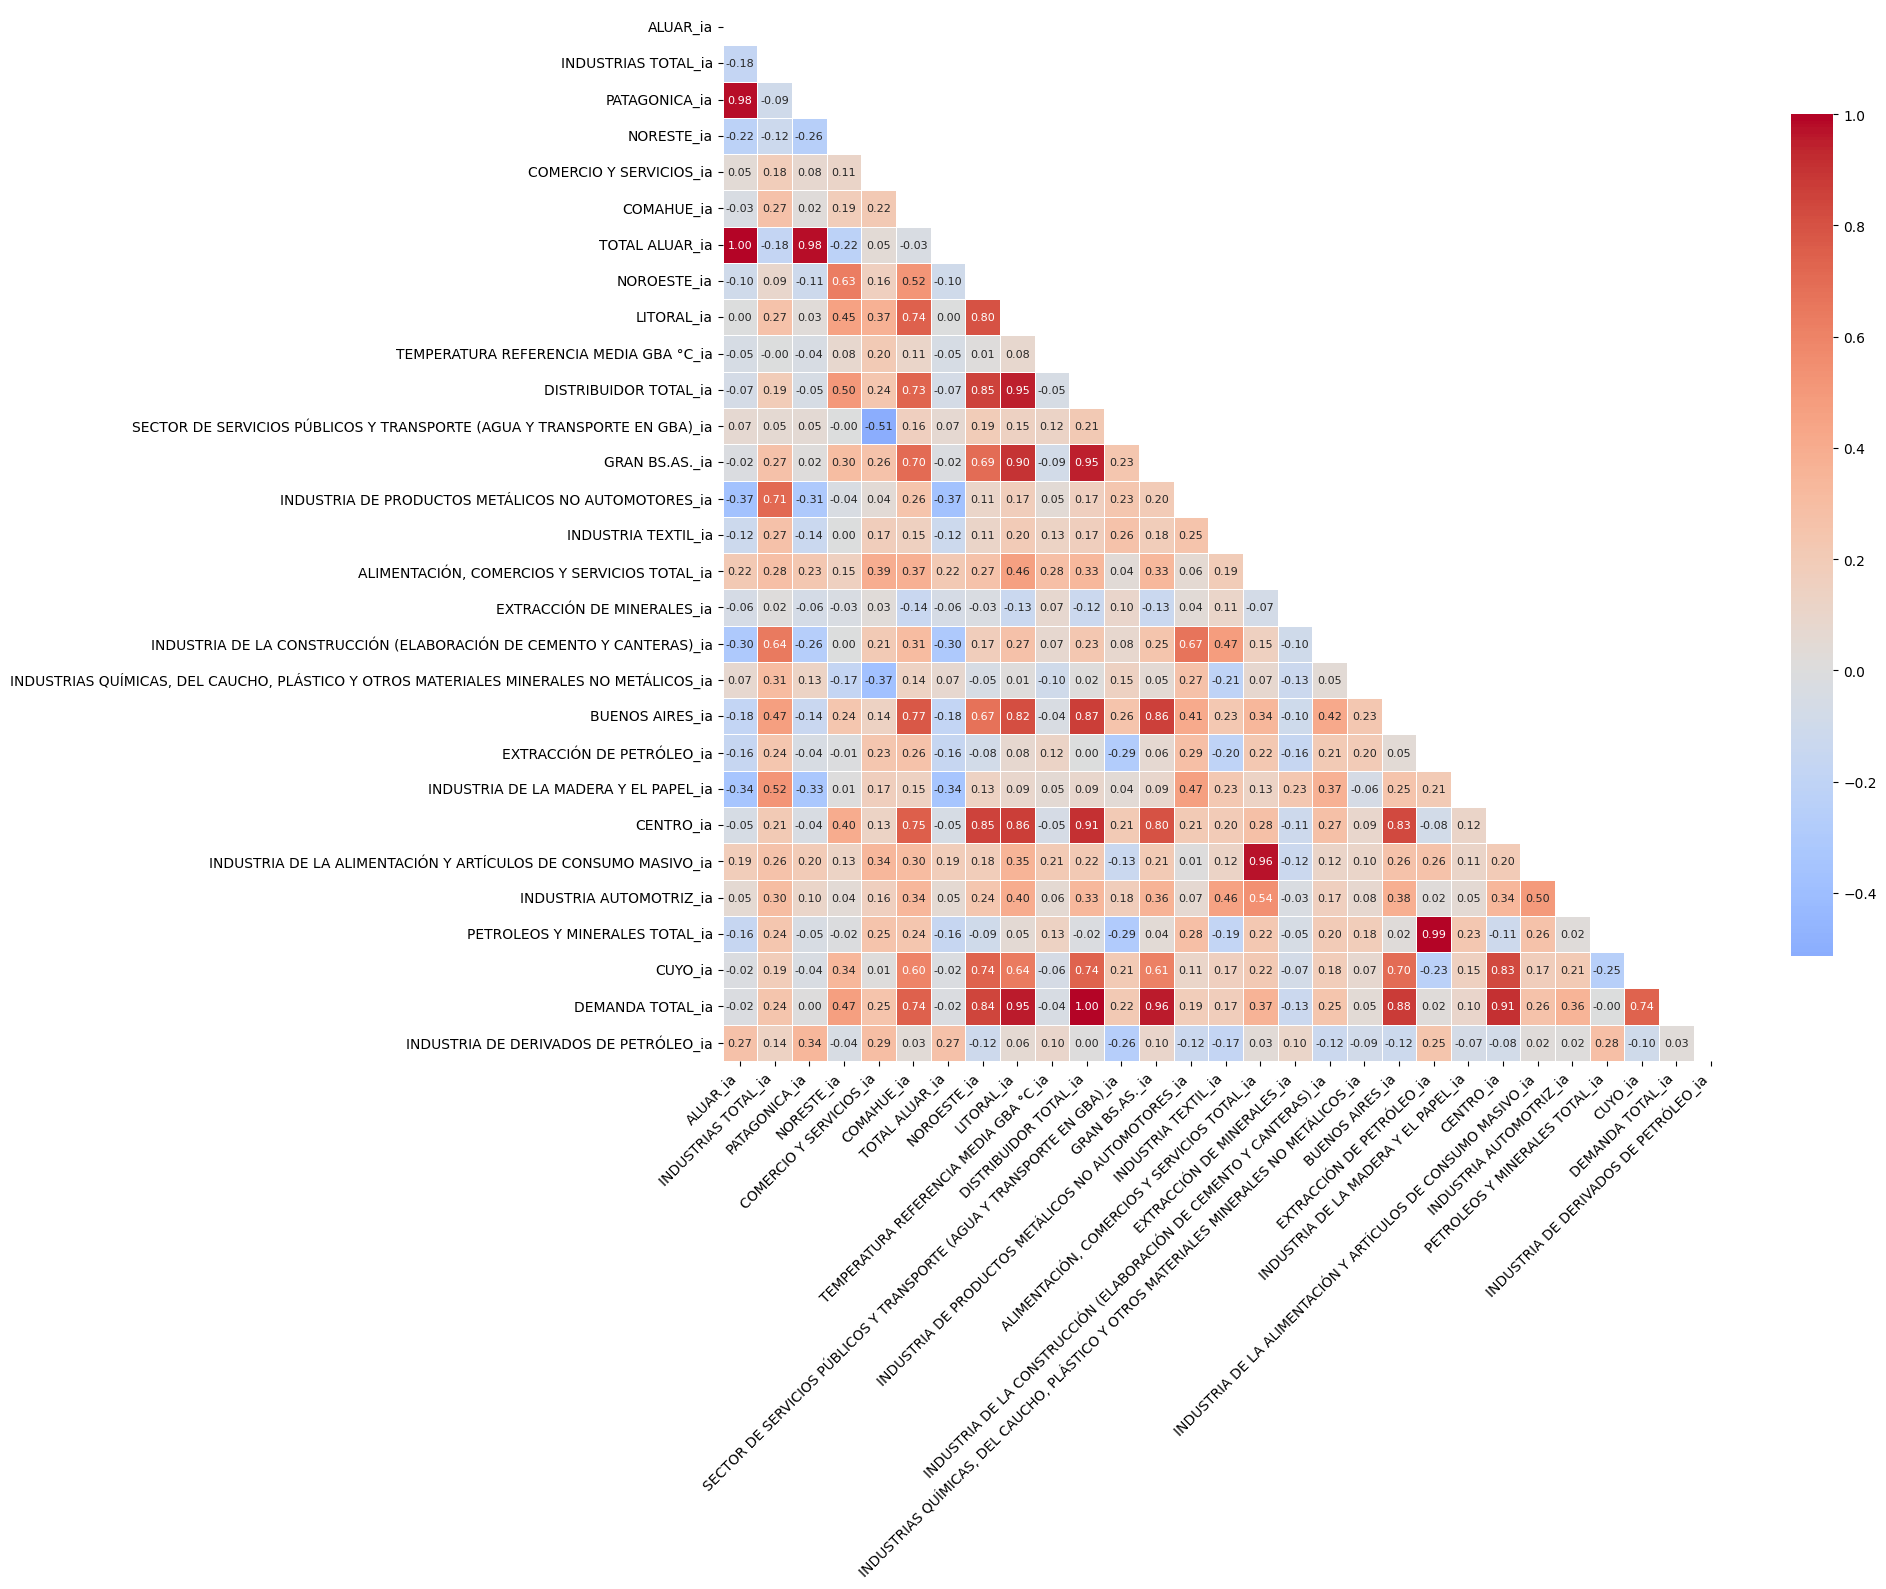

In [26]:
# Calcular la matriz de correlación
corr_matrix = demanda_var[cols_analisis].corr()

# Configura el gráfico
plt.figure(figsize=(20, 16))

# Crear una máscara para la mitad superior para facilitar lectura
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Graficar heatmap
sns.heatmap(corr_matrix,
            mask=mask,
            cmap='coolwarm',
            annot=True,          # Mostrar los números
            fmt=".2f",           # 2 decimales
            center=0,            # El blanco es el 0
            linewidths=.5,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 8})

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Guardamos gráfico
full_path_heatmap = os.path.join(path_images, "heatmap_correlacion_ia.pdf")
plt.savefig(full_path_heatmap, format='pdf', dpi=300)

plt.show()

Reducimos el heatmap para los casos con correlación alta para facilitar lectura

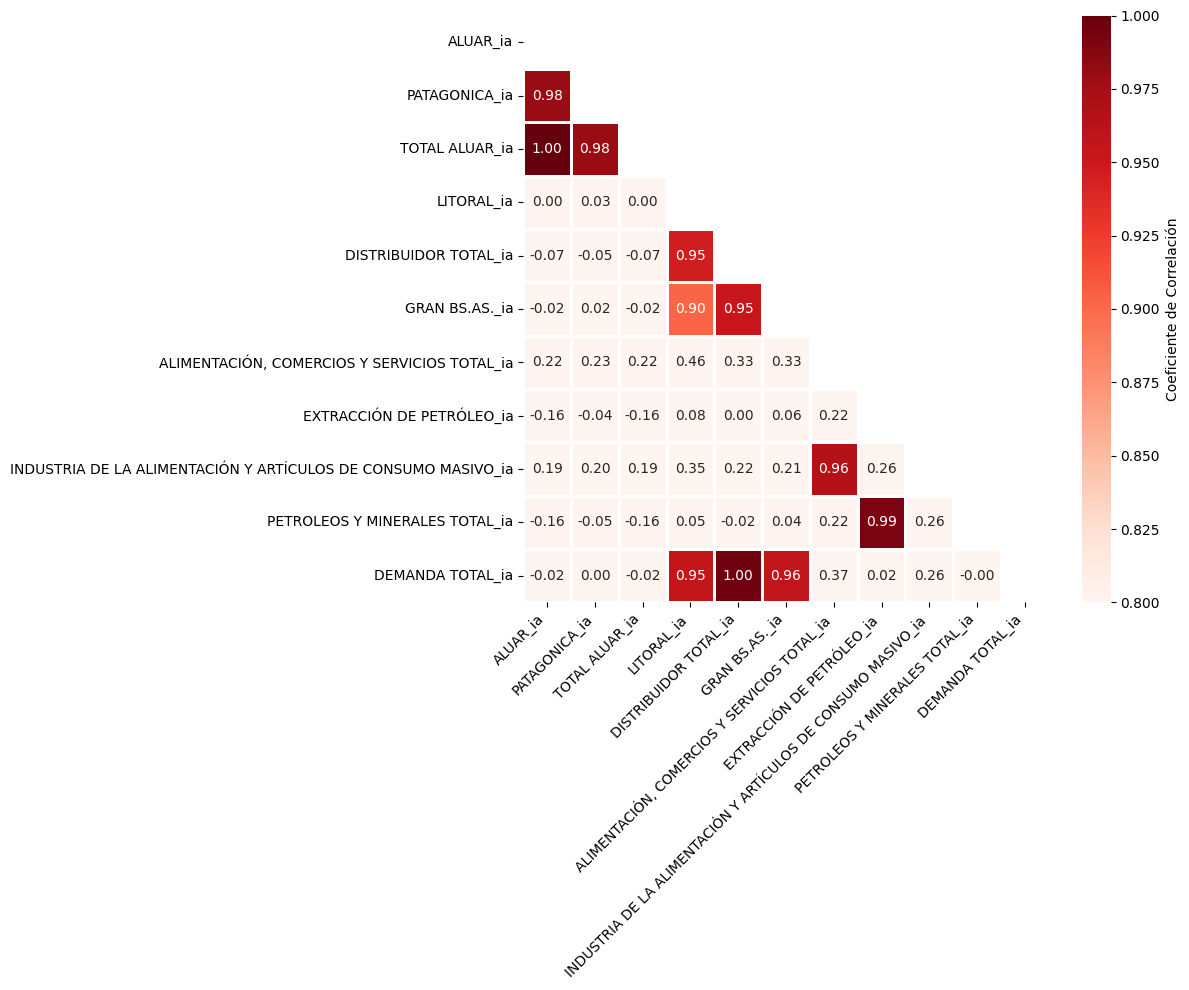

In [27]:
# Definimos el umbral crítico
umbral_critico = 0.95

# Encontramos variables con una correlación al menos más alta que el umbral
filtro_redundancia = corr_matrix[corr_matrix < 1.0].max() > umbral_critico
vars_redundantes = filtro_redundancia[filtro_redundancia].index.tolist()

if len(vars_redundantes) > 0:
    # Crea la sub-matriz solo con esas variables
    matriz_reducida = demanda_var[vars_redundantes].corr()

    # Graficar el Heatmap Reducido
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(matriz_reducida, dtype=bool))

    sns.heatmap(matriz_reducida,
                mask=mask,
                annot=True,
                fmt=".2f",
                cmap='Reds', # Usamos solo rojos para enfatizar la alta correlación
                vmin=0.8,    # Forzamos que el color empiece en 0.8 para resaltar las diferencias
                vmax=1,
                linewidths=1,
                cbar_kws={"label": "Coeficiente de Correlación"})

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Guardar en el path si existe
    plt.savefig(f"{path_images}/heatmap_reducido_critico.pdf", format='pdf')

    plt.show()
else:
    print(f"No hay pares de variables con correlación superior a {umbral_critico}")

### Eliminamos variables con alta correlación

In [28]:
# Define la lista de columnas a eliminar
cols_a_eliminar = ['TOTAL ALUAR_ia', 'DISTRIBUIDOR TOTAL_ia',
                   'ALIMENTACIÓN, COMERCIOS Y SERVICIOS TOTAL_ia',
                   'EXTRACCIÓN DE PETRÓLEO_ia'
                   ]
# Dropeamos las columnas
demanda_var = demanda_var.drop(columns=cols_a_eliminar, errors='ignore')

# Verificamos
print(f"Columnas eliminadas: {cols_a_eliminar}")
print(f"Dimensiones del dataset: {demanda_var.shape}")

Columnas eliminadas: ['TOTAL ALUAR_ia', 'DISTRIBUIDOR TOTAL_ia', 'ALIMENTACIÓN, COMERCIOS Y SERVICIOS TOTAL_ia', 'EXTRACCIÓN DE PETRÓLEO_ia']
Dimensiones del dataset: (1581, 34)


Outliers

# Unión de la variable target al df

In [29]:
# Renombramos la columna que contiene el EMAE_ia
df_emae = emae.rename(columns={'Serie_Original_var%_mes_año_anterior': 'EMAE_ia'})

# Join al df principal
demanda_var = pd.merge(
    demanda_var,
    df_emae[['periodo', 'EMAE_ia']],
    on='periodo',
    how='inner'
)

## Análisis de correlación con respecto al target

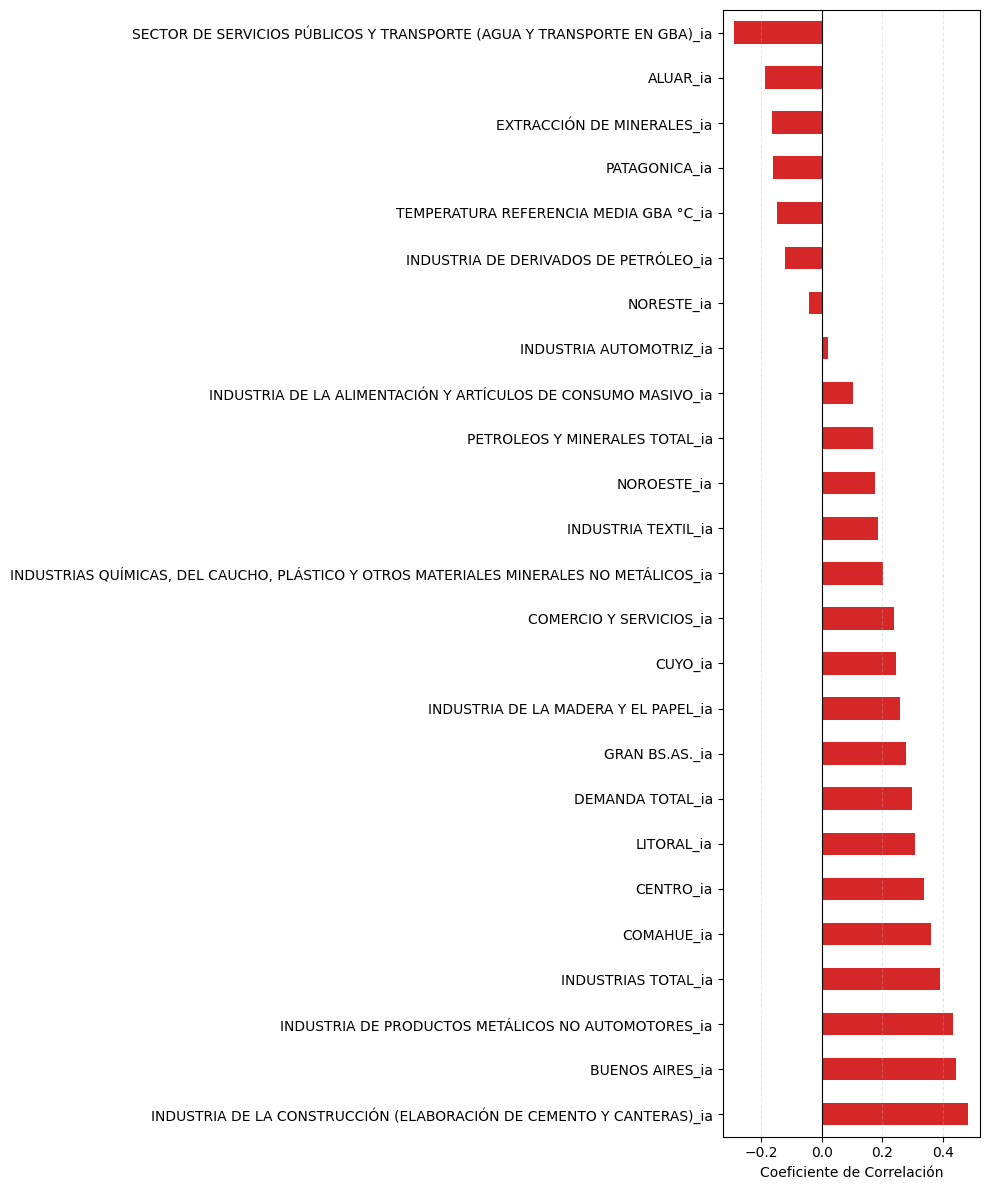

In [30]:
# Seleccionamos variables predictoras
predictoras_finales = [c for c in demanda_var.columns if c.endswith('_ia') and c != 'EMAE_ia']

# Calcular correlación de Pearson
correlacion_target = demanda_var[predictoras_finales].corrwith(demanda_var['EMAE_ia']).sort_values(ascending=False)

# Visualización
plt.figure(figsize=(10, 12), facecolor='white')
correlacion_target.plot(kind='barh', color='#D62728')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Coeficiente de Correlación')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Guardar
plt.savefig(f"{path_images}/correlacion_target_final.pdf", format='pdf')

plt.show()

## Análisis de Outliers

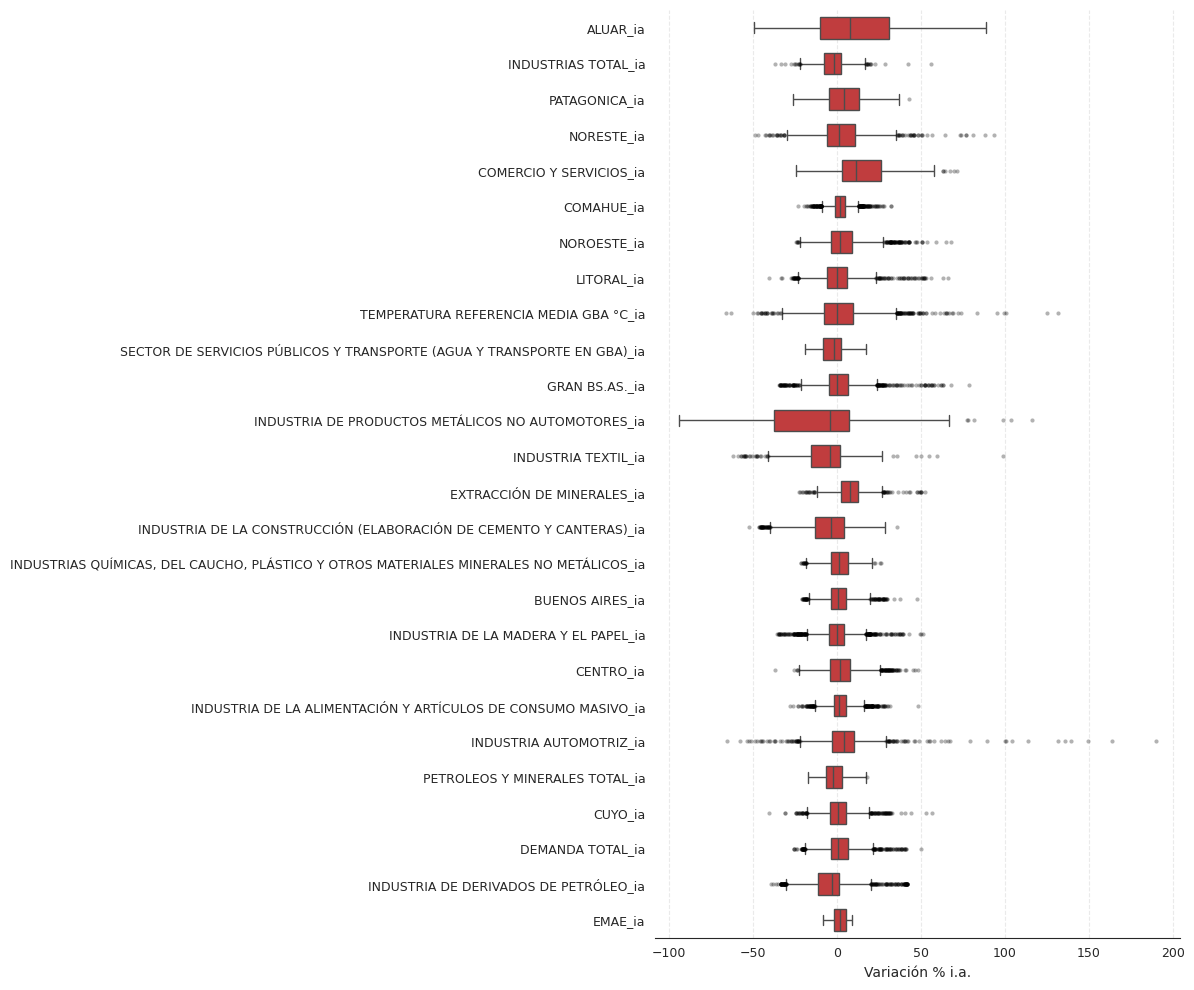

In [31]:
# Selecciona variables
cols_ia = [c for c in demanda_var.columns if c.endswith('_ia')]

# Melt del dataframe
df_melted = demanda_var.melt(value_vars=cols_ia, var_name='Variable', value_name='Variación % i.a.')

# Configuración
plt.figure(figsize=(12, 10), facecolor='white')
sns.set_style("white")

# Crea boxplot
ax = sns.boxplot(data=df_melted,
                 y='Variable',
                 x='Variación % i.a.',
                 color='#D62728',
                 width=0.6,
                 linewidth=1,
                 fliersize=3,
                 flierprops={'marker': 'o', 'markerfacecolor': 'black', 'alpha': 0.3, 'markeredgecolor': 'none'})

plt.xlabel('Variación % i.a.', fontsize=10)
plt.ylabel('', fontsize=10)

plt.yticks(fontsize=9)
plt.xticks(fontsize=9)

# Añadimos eje X
plt.grid(axis='x', linestyle='--', alpha=0.4)

sns.despine(left=True, bottom=False)

# Guardar
plt.tight_layout()

full_path_boxplots_small = os.path.join(path_images, "boxplots_compactos.pdf")
plt.savefig(full_path_boxplots_small, format='pdf', dpi=300)

plt.show()

### Top 5 de outliers
Para simplificación del análisis y mejor visualización

In [32]:
# Función para contar outliers según la regla del IQR
def contar_outliers(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    bajo = q1 - 1.5 * iqr
    alto = q3 + 1.5 * iqr
    # Contar cuántos valores están fuera de los límites
    return ((serie < bajo) | (serie > alto)).sum()

# Aplica la función a cada columna y ordena
conteo_outliers = demanda_var[cols_ia].apply(contar_outliers).sort_values(ascending=False)

# Muestra el Top 5
top_5_outliers = conteo_outliers.head(5).reset_index()
top_5_outliers.columns = ['Variable', 'Cantidad de Outliers']

display(top_5_outliers)



,Variable,Cantidad de Outliers
0,INDUSTRIA DE LA MADERA Y EL PAPEL_ia,183
1,COMAHUE_ia,149
2,GRAN BS.AS._ia,136
3,INDUSTRIA DE LA ALIMENTACIÓN Y ARTÍCULOS DE CO...,132
4,INDUSTRIA DE DERIVADOS DE PETRÓLEO_ia,123


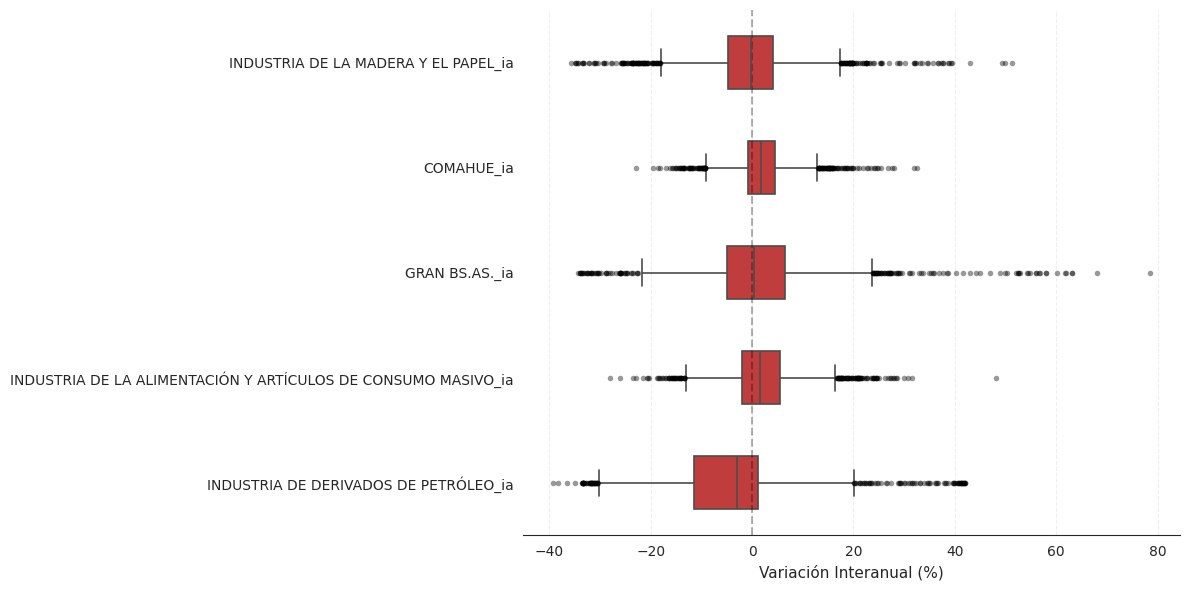

In [33]:
# Extrae la lista de las 5 variables con más outliers detectadas
vars_criticas = top_5_outliers['Variable'].tolist()

# Filtrar y preparar los datos (Melt) solo para estas 5
df_top_outliers = demanda_var.melt(value_vars=vars_criticas,
                                   var_name='Variable',
                                   value_name='Variación % i.a.')

# Configurar el gráfico
plt.figure(figsize=(12, 6), facecolor='white')
sns.set_style("white")

# Crear el Boxplot
ax = sns.boxplot(data=df_top_outliers,
                 y='Variable',
                 x='Variación % i.a.',
                 color='#D62728',
                 width=0.5,
                 linewidth=1.2,
                 fliersize=4,
                 flierprops={'marker': 'o', 'markerfacecolor': 'black', 'alpha': 0.4, 'markeredgecolor': 'none'})

plt.xlabel('Variación Interanual (%)', fontsize=11)
plt.ylabel('', fontsize=11)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)

# Cuadrícula para X
plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True)

# Guardar
plt.tight_layout()

full_path_top5 = os.path.join(path_images, "boxplot_top5_outliers.pdf")
plt.savefig(full_path_top5, format='pdf', dpi=300)

plt.show()

## Análisis de distribuciones

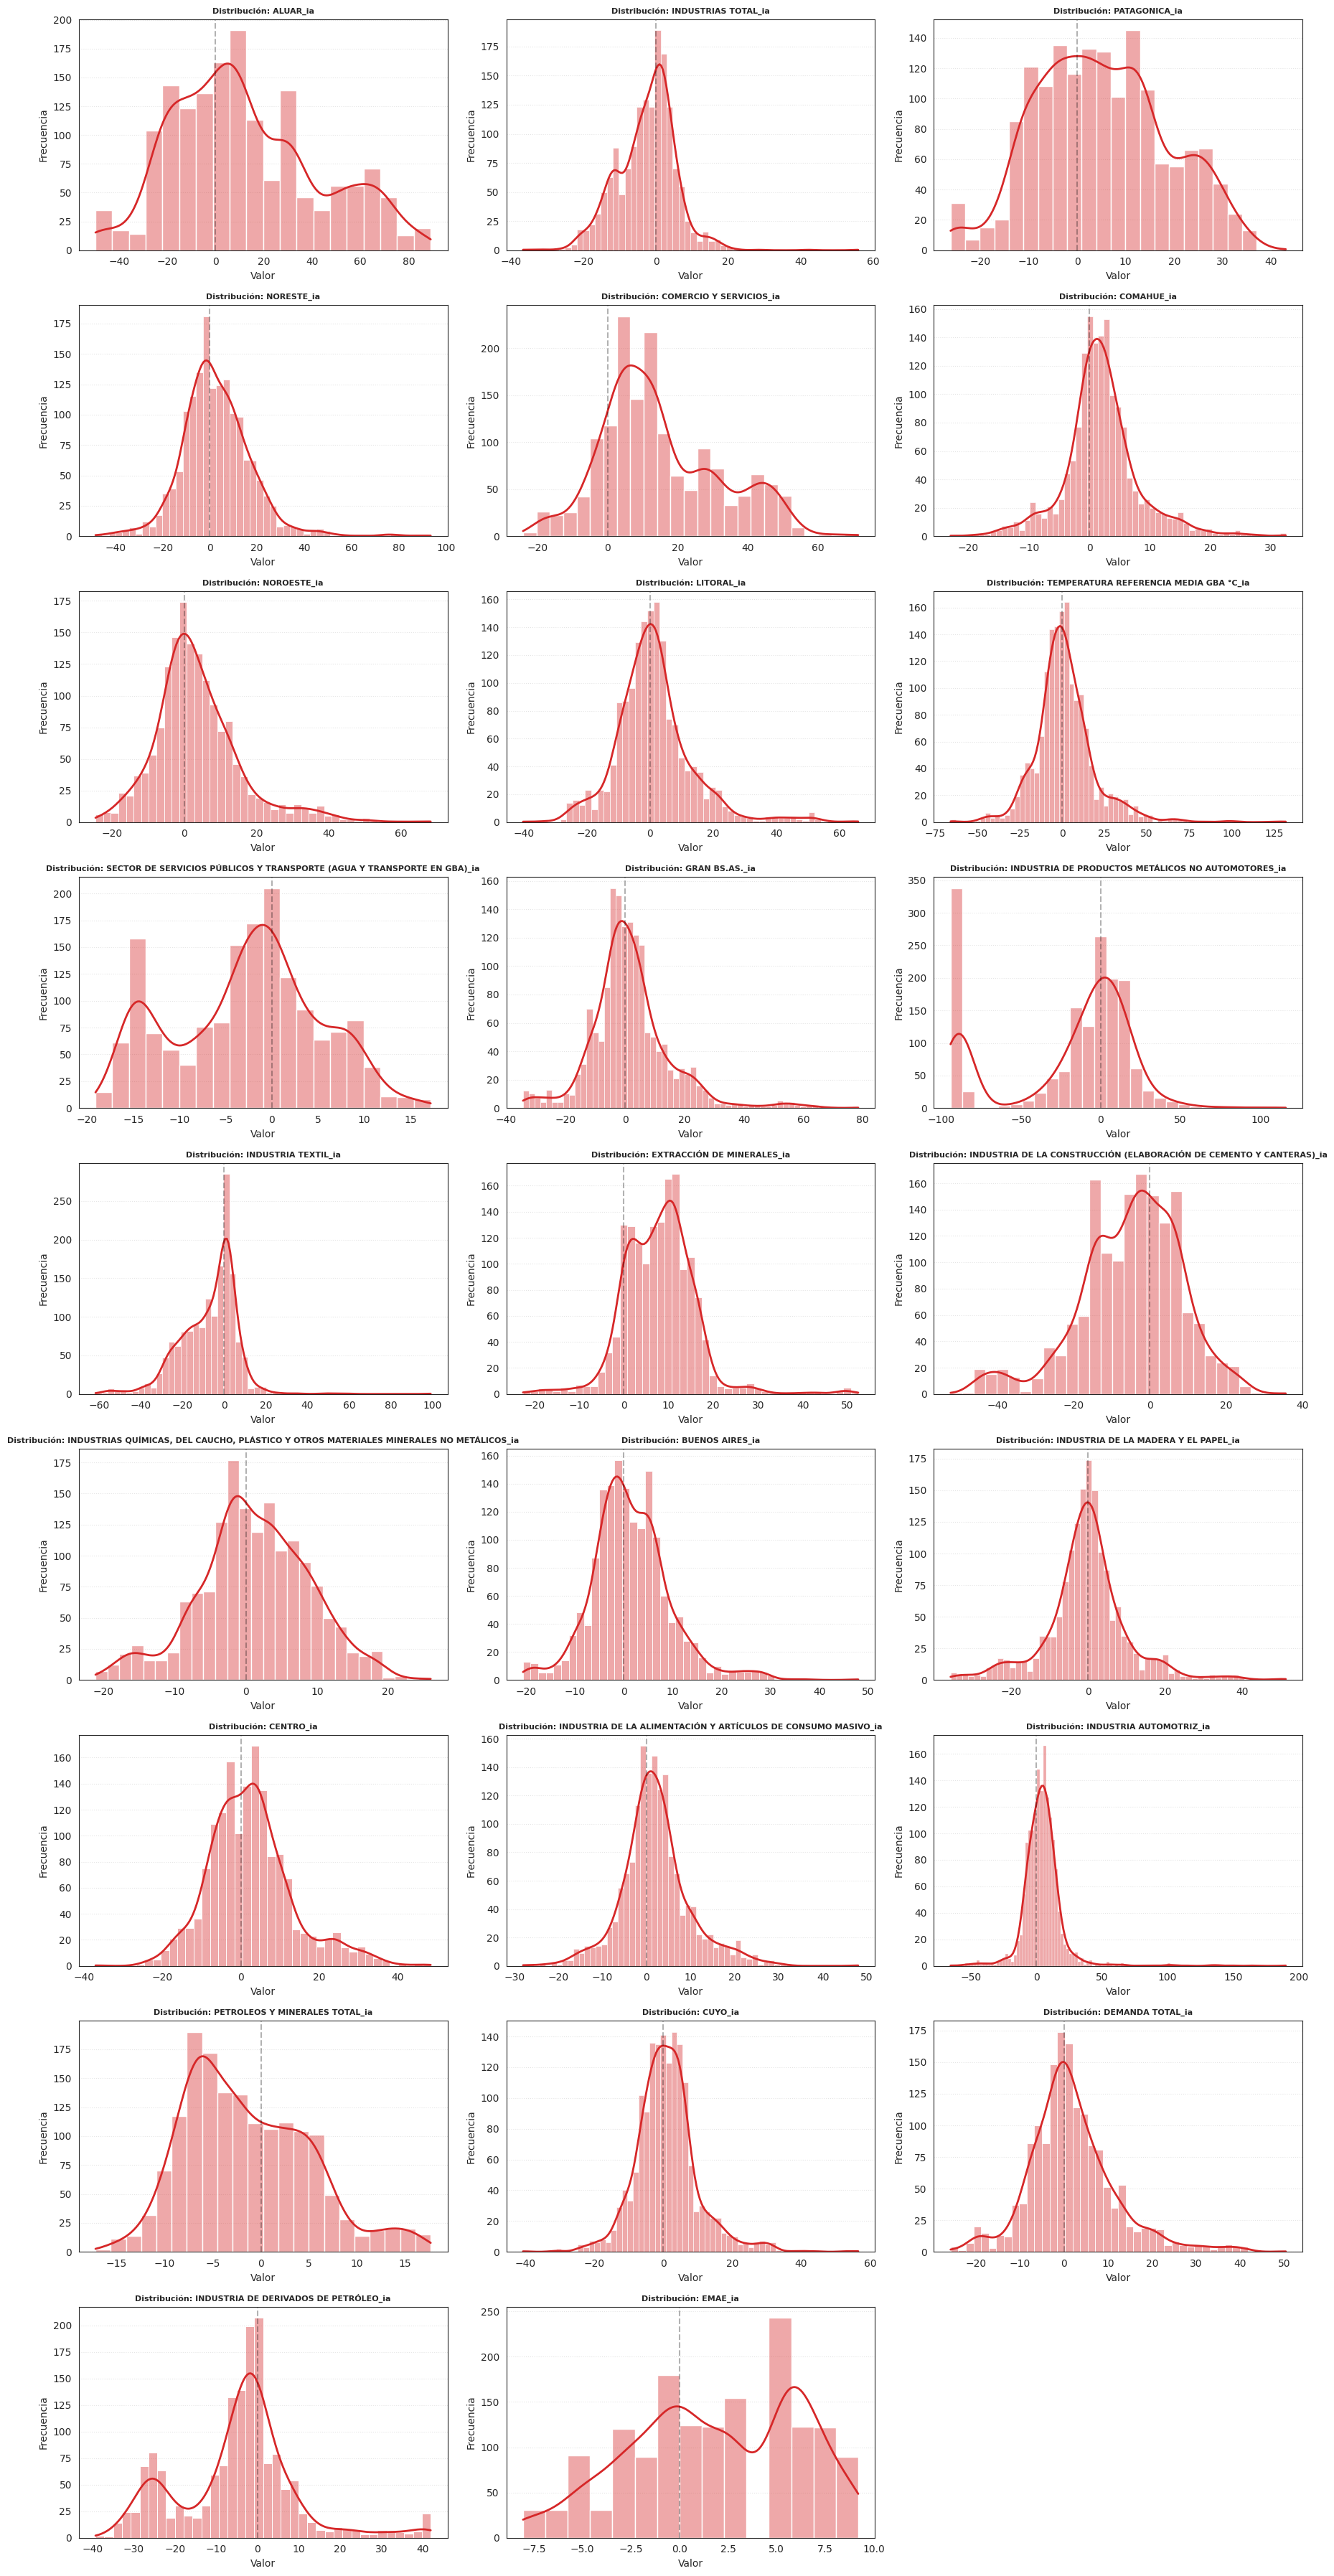

In [34]:
# Seleccionar las variables
cols_dist = [c for c in demanda_var.columns if c.endswith('_ia')]

# Configurar la grilla de subplots
n_cols = 3
n_rows = math.ceil(len(cols_dist) / n_cols)

plt.figure(figsize=(18, 4 * n_rows), facecolor='white')
sns.set_style("white")

# Iterar para graficar cada distribución
for i, var in enumerate(cols_dist):
    plt.subplot(n_rows, n_cols, i + 1)

    # Histograma + KDE
    sns.histplot(demanda_var[var],
                 kde=True,
                 color='#D62728',
                 line_kws={'linewidth': 2},
                 alpha=0.4)

    # Configuración de cada subplot
    plt.title(f'Distribución: {var}', fontsize=8, fontweight='bold')
    plt.xlabel('Valor', fontsize=10)
    plt.ylabel('Frecuencia', fontsize=10)
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.3) # Referencia en 0
    plt.grid(axis='y', linestyle=':', alpha=0.5)

# Guardar
plt.tight_layout()

full_path_dist = os.path.join(path_images, "distribuciones_variables.pdf")
plt.savefig(full_path_dist, format='pdf', dpi=300)

plt.show()

Selección de 4 variables para facilitar visualización

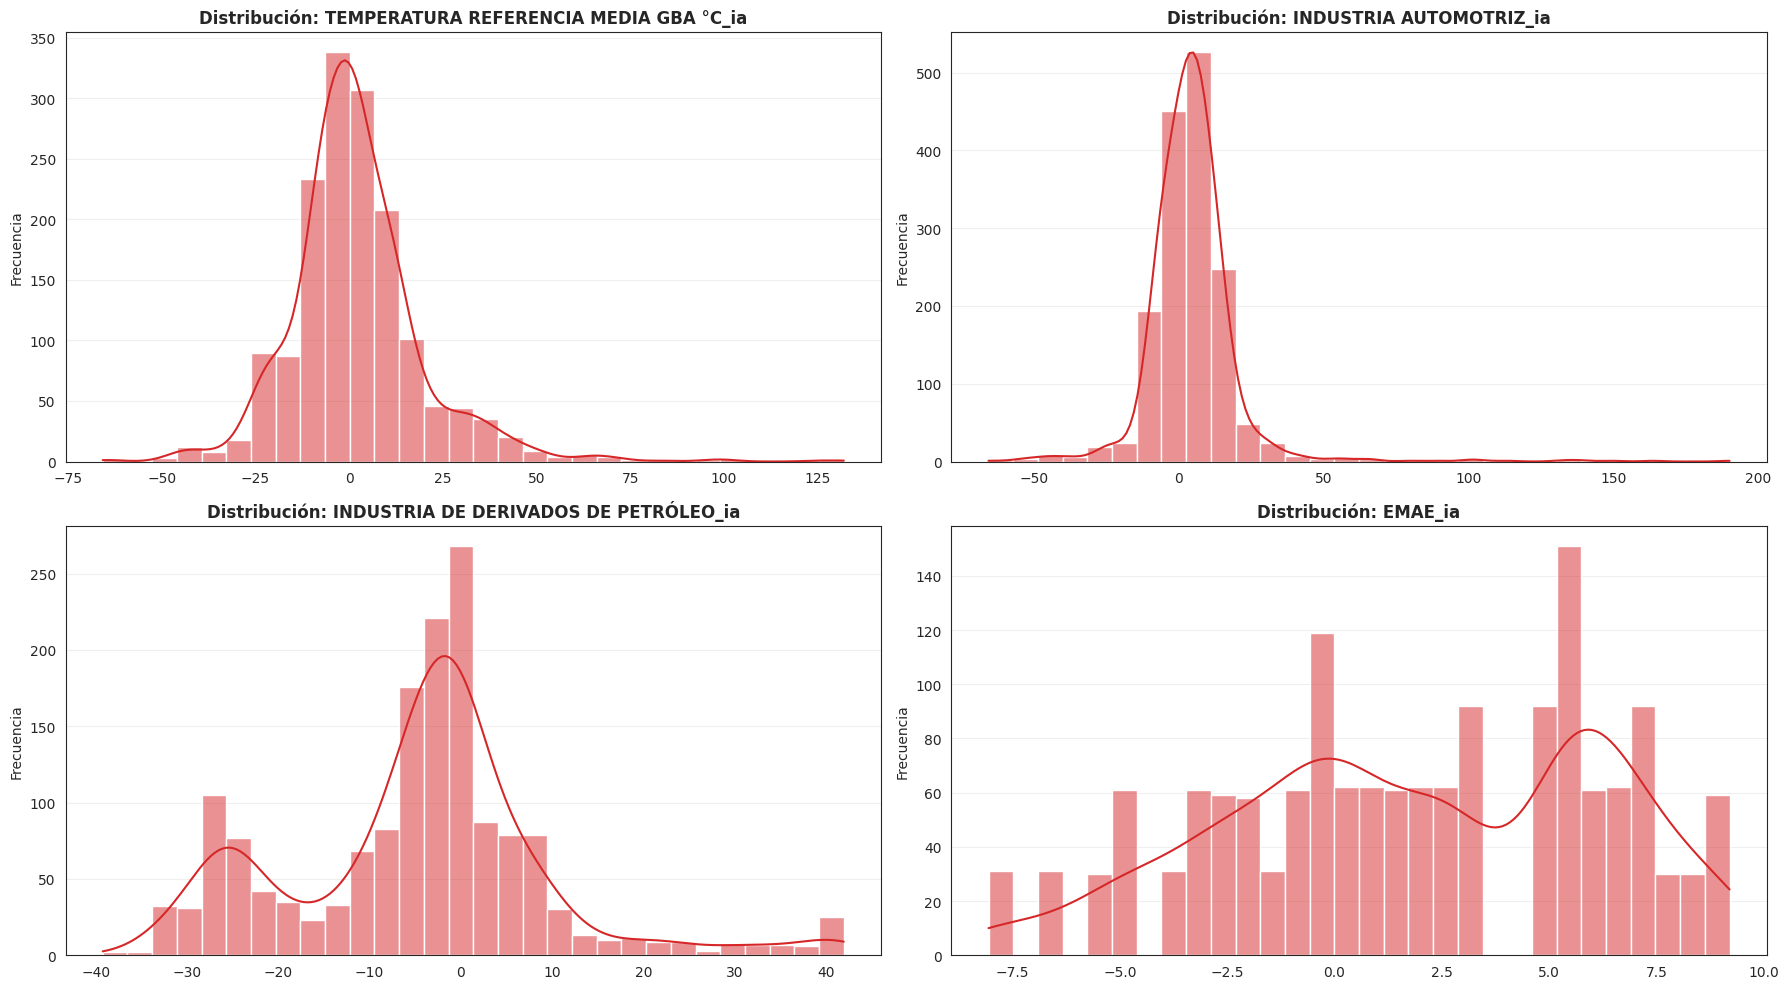

In [35]:
# Selección estratégica
vars_seleccion = [
    'TEMPERATURA REFERENCIA MEDIA GBA °C_ia',
    'INDUSTRIA AUTOMOTRIZ_ia',
    'INDUSTRIA DE DERIVADOS DE PETRÓLEO_ia',
    'EMAE_ia'
]

vars_plot = [v for v in vars_seleccion if v in demanda_var.columns]

# Configuración de la grilla
fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor='white')
axes = axes.flatten()

for i, var in enumerate(vars_plot):
    sns.histplot(demanda_var[var], kde=True, ax=axes[i], color='#D62728', bins=30)
    axes[i].set_title(f'Distribución: {var}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()

# Guardar
plt.savefig(f"{path_images}/distribuciones_seleccionadas.pdf", format='pdf')

plt.show()

## Patrones temporales

Por tipo de día

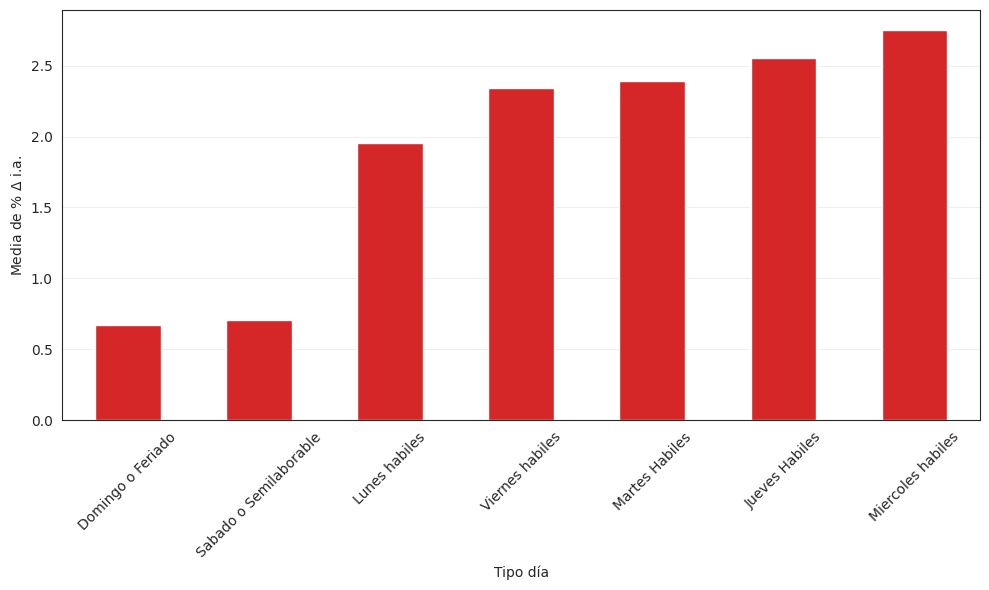

In [36]:
# Agrupa por tipo de día y calcula la media de la variación
patron_semanal = demanda_var.groupby('Tipo día')['DEMANDA TOTAL_ia'].mean().sort_values()

plt.figure(figsize=(10, 6))
patron_semanal.plot(kind='bar', color='#D62728')
plt.ylabel(r'Media de % $\Delta$ i.a.')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Guardar
plt.savefig(f"{path_images}/patron_temporal_tipo_dia.pdf", format='pdf')

plt.show()

Por mes

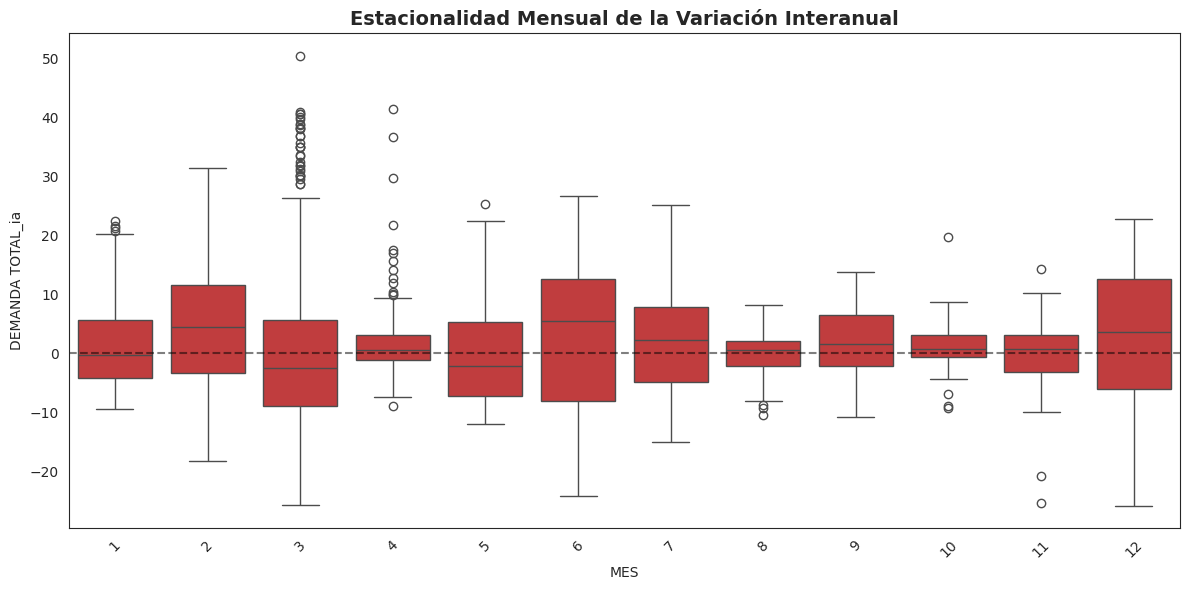

In [37]:
# Boxplot por mes para ver la estacionalidad de la variación
plt.figure(figsize=(12, 6))
sns.boxplot(data=demanda_var, x='MES', y='DEMANDA TOTAL_ia', color='#D62728')
plt.title('Estacionalidad Mensual de la Variación Interanual', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sincronía entre demanda y EMAE

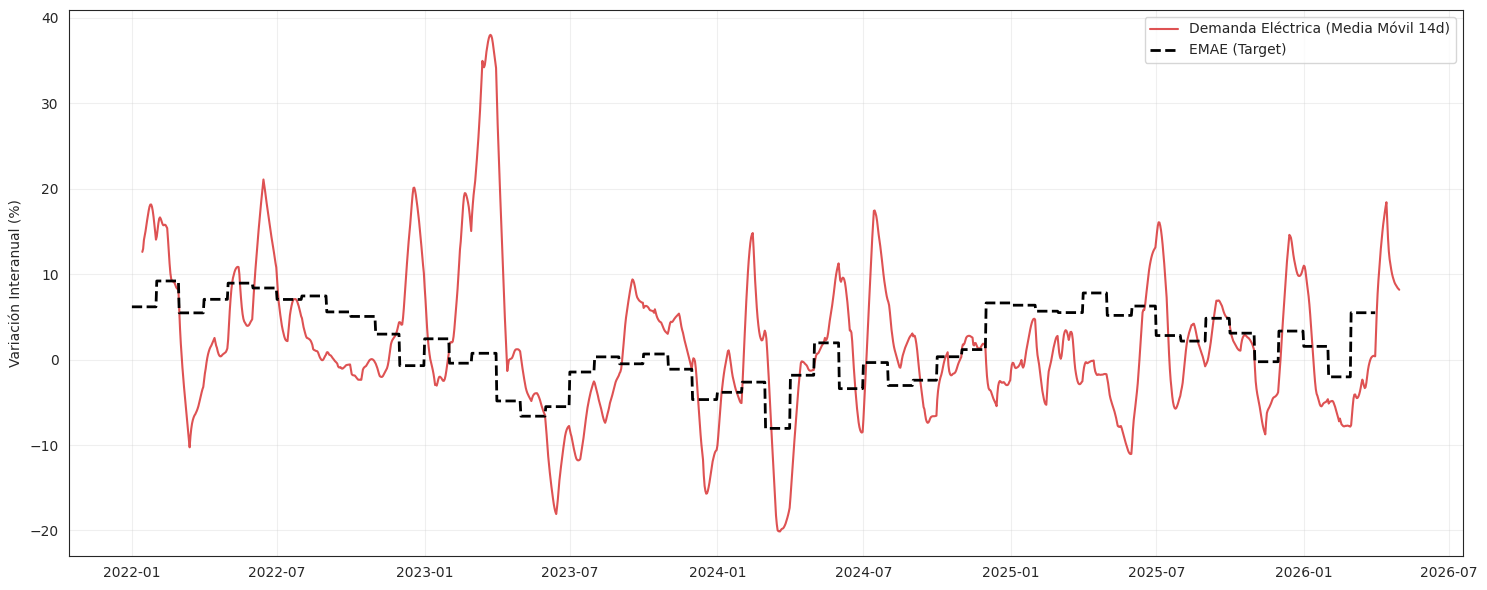

In [38]:
# Gráfico de líneas comparativo suavizado por media móvil de 14 días
demanda_suave = demanda_var.set_index('Fecha')['DEMANDA TOTAL_ia'].rolling(14).mean()
emae_serie = demanda_var.set_index('Fecha')['EMAE_ia']

plt.figure(figsize=(15, 6))
plt.plot(demanda_suave, label='Demanda Eléctrica (Media Móvil 14d)', color='#D62728', alpha=0.8)
plt.plot(emae_serie, label='EMAE (Target)', color='black', linewidth=2, linestyle='--')

plt.legend()
plt.grid(alpha=0.3)
plt.ylabel('Variación Interanual (%)')
plt.tight_layout()


# Guardar
plt.savefig(f"{path_images}/sincronia_demanda_emae.pdf", format='pdf')

plt.show()

Guardamos dataset

In [39]:
path_demanda_var = os.path.join(folder_path, 'dataset_consolidado.csv')
demanda_var.to_csv(path_demanda_var, index=False)


Cargar dataset para modelizar

In [40]:
path_demanda_var = os.path.join(folder_path, 'dataset_consolidado.csv')

# Lectura del csv
demanda_var = pd.read_csv(path_demanda_var, sep=',', encoding='utf-8-sig', parse_dates=['Fecha'])

# Verificación
display(demanda_var.head())

,periodo,Fecha,AÑO,MES,DIA,Tipo día,es_habil,dia_semana_num,dia_avance,ALUAR_ia,...,BUENOS AIRES_ia,INDUSTRIA DE LA MADERA Y EL PAPEL_ia,CENTRO_ia,INDUSTRIA DE LA ALIMENTACIÓN Y ARTÍCULOS DE CONSUMO MASIVO_ia,INDUSTRIA AUTOMOTRIZ_ia,PETROLEOS Y MINERALES TOTAL_ia,CUYO_ia,DEMANDA TOTAL_ia,INDUSTRIA DE DERIVADOS DE PETRÓLEO_ia,EMAE_ia
0,202201,2022-01-01,2022,1,1,Domingo o Feriado,0,7,1,-42.845346,...,10.105579,14.482583,36.697838,-12.939956,13.849330,-8.445240,-0.891268,15.657569,-21.724174,6.171175
1,202201,2022-01-02,2022,1,2,Domingo o Feriado,0,7,2,-45.445188,...,5.785366,36.723561,25.209190,-16.020565,6.334290,-8.903719,2.773613,6.672917,-21.012747,6.171175
2,202201,2022-01-03,2022,1,3,Lunes habiles,1,1,3,-45.604949,...,14.372707,49.801012,36.402437,-3.089175,16.187206,-8.118978,15.774485,15.375042,-19.589217,6.171175
3,202201,2022-01-04,2022,1,4,Martes Habiles,1,2,4,-46.728335,...,15.564960,51.203762,30.704254,-0.110926,0.697490,-7.424364,19.191132,14.192693,-19.427837,6.171175
4,202201,2022-01-05,2022,1,5,Miercoles habiles,1,3,5,-47.451249,...,14.880004,49.249910,28.717714,-0.703197,-9.420921,-7.720205,24.325318,10.883688,-18.857936,6.171175


# Modelos


Guardamos el dataset generado y creamos la carpeta para futuros resultados

In [41]:
# Definir las rutas
path_resultados_general = '/content/drive/MyDrive/Maestría en Data Mining/Taller de Tesis I/Final V6/Resultados'
path_resultados_particular = path_resultados_general

# Crear la carpeta si no existe de forma recursiva
os.makedirs(path_resultados_particular, exist_ok=True)

Renombramos y guardamos nuevamente el dataset

In [42]:
# Definimos el diccionario de mapeo
dicc_renombrar = {
    # Variables de control y calendario
    'periodo': 'periodo',
    'Fecha': 'fecha',
    'AÑO': 'anio',
    'MES': 'mes',
    'DIA': 'dia',
    'Tipo día': 'tipo_dia_texto',
    'es_habil': 'es_habil',
    'dia_semana_num': 'dia_semana_num',
    'dia_avance': 'dia_avance',

    # Target
    'EMAE_ia': 'target_emae_ia',

    # Clima
    'TEMPERATURA REFERENCIA MEDIA GBA °C_ia': 'temp_media_gba_ia',

    # Agregados y Regiones de Demanda Eléctrica
    'DEMANDA TOTAL_ia': 'demanda_total_ia',
    'INDUSTRIAS TOTAL_ia': 'ind_total_ia',
    'COMERCIO Y SERVICIOS_ia': 'comercio_servicios_ia',
    'GRAN BS.AS._ia': 'reg_gba_ia',
    'BUENOS AIRES_ia': 'reg_prov_ba_ia',
    'CENTRO_ia': 'reg_centro_ia',
    'LITORAL_ia': 'reg_litoral_ia',
    'CUYO_ia': 'reg_cuyo_ia',
    'NOROESTE_ia': 'reg_noroeste_ia',
    'NORESTE_ia': 'reg_noreste_ia',
    'COMAHUE_ia': 'reg_comahue_ia',
    'PATAGONICA_ia': 'reg_patagonica_ia',

    # Ramas Industriales Específicas
    'INDUSTRIA DE LA ALIMENTACIÓN Y ARTÍCULOS DE CONSUMO MASIVO_ia': 'ind_alimentacion_ia',
    'INDUSTRIA AUTOMOTRIZ_ia': 'ind_automotriz_ia',
    'INDUSTRIA DE DERIVADOS DE PETRÓLEO_ia': 'ind_derivados_petroleo_ia',
    'INDUSTRIA DE LA CONSTRUCCIÓN (ELABORACIÓN DE CEMENTO Y CANTERAS)_ia': 'ind_construccion_ia',
    'INDUSTRIA DE LA MADERA Y EL PAPEL_ia': 'ind_madera_papel_ia',
    'INDUSTRIA DE PRODUCTOS METÁLICOS NO AUTOMOTORES_ia': 'ind_metalica_no_auto_ia',
    'INDUSTRIA TEXTIL_ia': 'ind_textile_ia',
    'INDUSTRIAS QUÍMICAS, DEL CAUCHO, PLÁSTICO Y OTROS MATERIALES MINERALES NO METÁLICOS_ia': 'ind_quimica_plastico_ia',
    'EXTRACCIÓN DE MINERALES_ia': 'ind_extraccion_minerales_ia',
    'PETROLEOS Y MINERALES TOTAL_ia': 'ind_petroleo_minerales_total_ia',
    'ALUAR_ia': 'ind_aluar_ia',
    'SECTOR DE SERVICIOS PÚBLICOS Y TRANSPORTE (AGUA Y TRANSPORTE EN GBA)_ia': 'serv_publicos_transporte_ia'
}

# Aplicamos el renombramiento sobre las columnas existentes
demanda_var = demanda_var.rename(columns=dicc_renombrar)

# Guardamos esta nueva versión
ruta_archivo_csv = os.path.join(path_resultados_particular, 'dataset_consolidado.csv')
demanda_var.to_csv(ruta_archivo_csv, index=False)


## Clustering

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [44]:
# Definir y crear la carpeta específica para el clustering
path_clustering = os.path.join(path_resultados_particular, 'Clustering')
os.makedirs(path_clustering, exist_ok=True)

### KMeans

In [45]:
# Crear subcarpeta específica
path_kmeans = os.path.join(path_clustering, 'kmeans')
os.makedirs(path_kmeans, exist_ok=True)

#### Caso estandarizado

In [46]:
# Selección automática de predictores económicos y climáticos en tasa
columnas_excluidas = [
    'periodo', 'fecha', 'anio', 'mes', 'dia', 'tipo_dia_texto',
    'es_habil', 'dia_semana_num', 'dia_avance', 'target_emae_ia'
]
# Filtramos las columnas
features_clustering = [c for c in demanda_var.columns if c not in columnas_excluidas]

# Creamos un df auxiliar
df_demanda_aux = demanda_var.reset_index() if 'fecha' not in demanda_var.columns else demanda_var.copy()

# Dropeamos filas con nulos en caso que hayan quedado
df_cluster_input = df_demanda_aux[['periodo', 'fecha'] + features_clustering].dropna().reset_index(drop=True)

# Estandarización de las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_input[features_clustering])

Optimización

In [47]:
# Bucle iterativo de optimización (Rango K de 2 a 30)

# Promedio de 5 semillas para mayor robustez
random_seeds = [1009, 2003, 3001, 4001, 5003]

max_k = 15
all_inercias = {k: [] for k in range(2, max_k)}
all_siluetas = {k: [] for k in range(2, max_k)}
all_davies_bouldin = {k: [] for k in range(2, max_k)}

rango_k = range(2, max_k)

for seed in random_seeds:
    print(f"Running K-Means with random_state = {seed}...")
    for k in rango_k:
        kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = kmeans.fit_predict(X_scaled)

        all_inercias[k].append(kmeans.inertia_)
        all_siluetas[k].append(silhouette_score(X_scaled, labels))
        all_davies_bouldin[k].append(davies_bouldin_score(X_scaled, labels))

# Calculamos el promedio de las métricas
inercias_mean = [np.mean(all_inercias[k]) for k in rango_k]
siluetas_mean = [np.mean(all_siluetas[k]) for k in rango_k]
davies_bouldin_mean = [np.mean(all_davies_bouldin[k]) for k in rango_k]

Running K-Means with random_state = 1009...
Running K-Means with random_state = 2003...
Running K-Means with random_state = 3001...
Running K-Means with random_state = 4001...
Running K-Means with random_state = 5003...


Graficamos las métricas

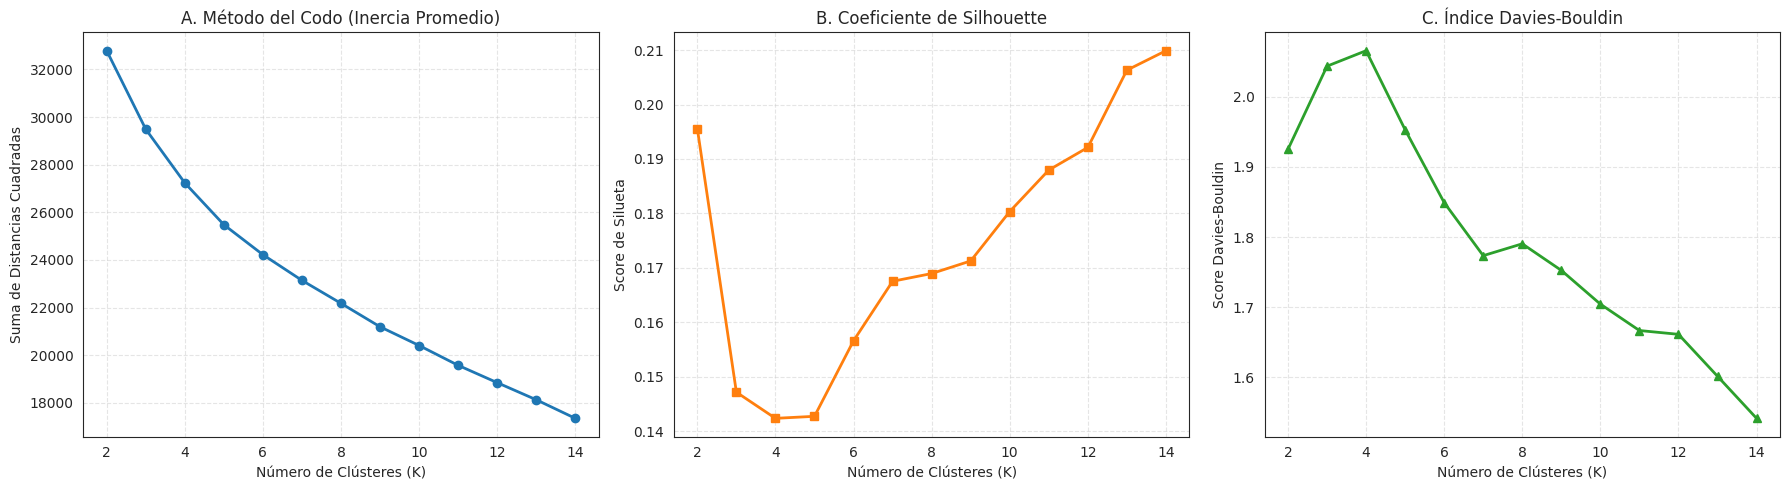

In [48]:
# Generación del gráfico de diagnóstico de tres paneles
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Inercia (Buscar el "Codo")
ax1.plot(rango_k, inercias_mean, marker='o', color='tab:blue', linewidth=2)
ax1.set_title('A. Método del Codo (Inercia Promedio)', fontsize=12)
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Suma de Distancias Cuadradas')
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel 2: Silueta (Buscar el Máximo)
ax2.plot(rango_k, siluetas_mean, marker='s', color='tab:orange', linewidth=2)
ax2.set_title('B. Coeficiente de Silhouette', fontsize=12)
ax2.set_xlabel('Número de Clústeres (K)')
ax2.set_ylabel('Score de Silueta')
ax2.grid(True, linestyle='--', alpha=0.5)

# Panel 3: Davies-Bouldin (Buscar el Mínimo)
ax3.plot(rango_k, davies_bouldin_mean, marker='^', color='tab:green', linewidth=2)
ax3.set_title('C. Índice Davies-Bouldin', fontsize=12)
ax3.set_xlabel('Número de Clústeres (K)')
ax3.set_ylabel('Score Davies-Bouldin')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Guardar reporte de optimización
ruta_grafico_metricas = os.path.join(path_kmeans, 'optimizacion_k_metrics_avg_scaled.png')
plt.savefig(ruta_grafico_metricas, dpi=300, bbox_inches='tight')
plt.show()


Graficamos el espacio con PCA

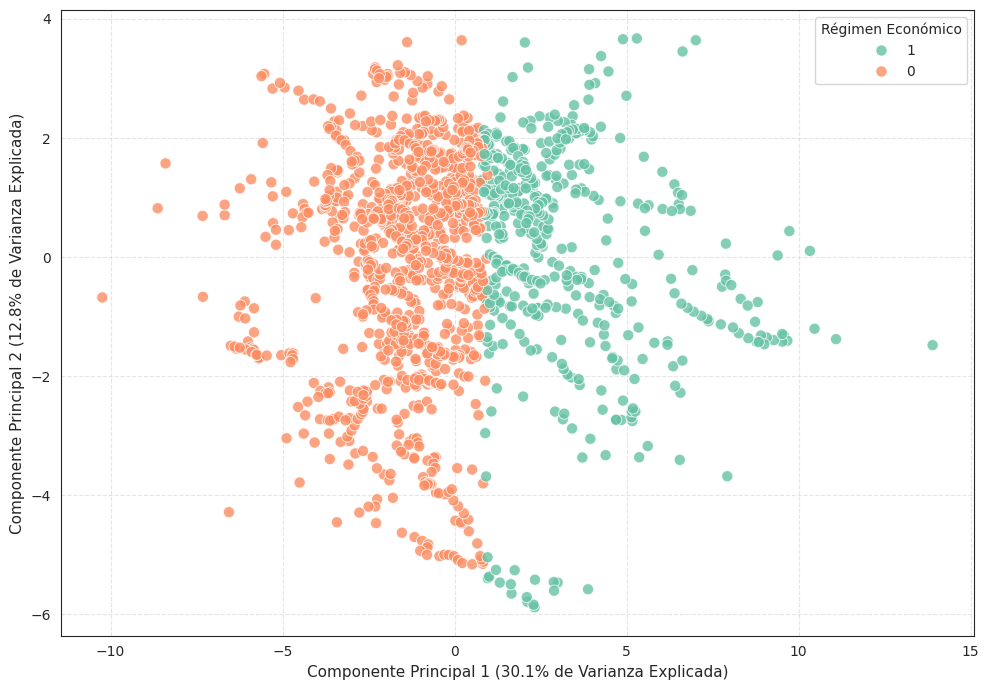

In [49]:
from sklearn.decomposition import PCA

# Si bien no existe un k óptimo, elegimos uno para graficar
k_optimo = 2

# Entrenar el modelo definitivo y asignar etiquetas de régimen
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_cluster_input['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)

# Reducción de dimensionalidad con PCA para visualización espacial 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_visualizacion = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_visualizacion['Régimen (Cluster)'] = df_cluster_input['cluster_kmeans'].astype(str)

# Graficar la dispersión espacial de los regímenes detectados
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='Régimen (Cluster)',
    data=df_visualizacion,
    palette='Set2',
    alpha=0.8,
    edgecolor='w',
    s=65
)

# Capturamos los ratios de varianza para los ejes
var_explicada = pca.explained_variance_ratio_
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.1f}% de Varianza Explicada)', fontsize=11)
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.1f}% de Varianza Explicada)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Régimen Económico', loc='upper right')

# Guardar
ruta_grafico_final_clusters = os.path.join(path_kmeans, f'dispersion_espacial_k{k_optimo}_scaled.png')
plt.tight_layout()
plt.savefig(ruta_grafico_final_clusters, dpi=300)
plt.show()

Análisis de lógica macroeconómica de los clusters

In [50]:
# Creamos la copia explícita con las etiquetas fresquitas del último entrenamiento
df_regimenes = df_cluster_input.copy()
df_regimenes['cluster_kmeans'] = kmeans_final.labels_

# Reseteamos el índice de demanda_var de forma temporal y segura, asegurando una copia explícita
df_demanda_temporal = demanda_var.copy()
if 'fecha' not in df_demanda_temporal.columns:
    df_demanda_temporal = df_demanda_temporal.reset_index()

# BLINDAJE: Si df_demanda_temporal ya arrastra una columna vieja 'cluster_kmeans', la eliminamos
if 'cluster_kmeans' in df_demanda_temporal.columns:
    df_demanda_temporal = df_demanda_temporal.drop(columns=['cluster_kmeans'])

# Limpiamos posibles residuos de sufijos previos por seguridad
columnas_residuales = [c for c in df_demanda_temporal.columns if c.startswith('cluster_kmeans_') or c == 'index']
if columnas_residuales:
    df_demanda_temporal = df_demanda_temporal.drop(columns=columnas_residuales)

# Cruzamos de forma directa usando la columna 'fecha'
df_analisis_macro = pd.merge(
    df_regimenes[['fecha', 'cluster_kmeans']],
    df_demanda_temporal[['fecha', 'target_emae_ia', 'demanda_total_ia', 'ind_total_ia', 'temp_media_gba_ia']],
    on='fecha',
    how='inner'
)

# Calculamos las métricas macroeconómicas por régimen
resumen_regimenes = df_analisis_macro.groupby('cluster_kmeans').agg(
    frecuencia=('fecha', 'count'),
    emae_promedio=('target_emae_ia', 'mean'),
    demanda_total_promedio=('demanda_total_ia', 'mean'),
    industria_promedio=('ind_total_ia', 'mean'),
    temperatura_promedio=('temp_media_gba_ia', 'mean')
).reset_index()

print(f"Caracterización Macroeconómica de los Regímenes Detectados (K={k_optimo}):")
display(resumen_regimenes)

Caracterización Macroeconómica de los Regímenes Detectados (K=2):


,cluster_kmeans,frecuencia,emae_promedio,demanda_total_promedio,industria_promedio,temperatura_promedio
0,0,1102,0.985557,-2.766852,-4.399574,2.511273
1,1,479,3.927190,12.432727,1.630667,0.243509


#### Caso sin escalar

In [51]:
# Selección automática de predictores económicos y climáticos en tasa
columnas_excluidas_unscaled = [
    'periodo', 'fecha', 'anio', 'mes', 'dia', 'tipo_dia_texto',
    'es_habil', 'dia_semana_num', 'dia_avance', 'target_emae_ia'
]
# Filtramos las columnas
features_clustering_unscaled = [c for c in demanda_var.columns if c not in columnas_excluidas_unscaled]

# Creamos un df auxiliar
df_demanda_aux_unscaled = demanda_var.reset_index() if 'fecha' not in demanda_var.columns else demanda_var.copy()

# Dropeamos filas con nulos en caso que hayan quedado
df_cluster_input_unscaled = df_demanda_aux_unscaled[['periodo', 'fecha'] + features_clustering_unscaled].dropna().reset_index(drop=True)

# Asignamos X_unscaled directamente desde las features seleccionadas (sin escalar)
X_unscaled = df_cluster_input_unscaled[features_clustering_unscaled]


Optimizamos

In [52]:
# Promedio de 5 semillas para mayor robustez
random_seeds = [1009, 2003, 3001, 4001, 5003]

max_k = 15
all_inercias_unscaled = {k: [] for k in range(2, max_k)}
all_siluetas_unscaled = {k: [] for k in range(2, max_k)}
all_davies_bouldin_unscaled = {k: [] for k in range(2, max_k)}

rango_k = range(2, max_k)

for seed in random_seeds:
    print(f"  Running K-Means (unscaled) with random_state = {seed}...")
    for k in rango_k:
        kmeans_unscaled = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels_unscaled = kmeans_unscaled.fit_predict(X_unscaled) # Fit en X_unscaled

        all_inercias_unscaled[k].append(kmeans_unscaled.inertia_)
        all_siluetas_unscaled[k].append(silhouette_score(X_unscaled, labels_unscaled))
        all_davies_bouldin_unscaled[k].append(davies_bouldin_score(X_unscaled, labels_unscaled))

# Calculamos el promedio de las métricas
inercias_mean_unscaled = [np.mean(all_inercias_unscaled[k]) for k in rango_k]
siluetas_mean_unscaled = [np.mean(all_siluetas_unscaled[k]) for k in rango_k]
davies_bouldin_mean_unscaled = [np.mean(all_davies_bouldin_unscaled[k]) for k in rango_k]

  Running K-Means (unscaled) with random_state = 1009...
  Running K-Means (unscaled) with random_state = 2003...
  Running K-Means (unscaled) with random_state = 3001...
  Running K-Means (unscaled) with random_state = 4001...
  Running K-Means (unscaled) with random_state = 5003...


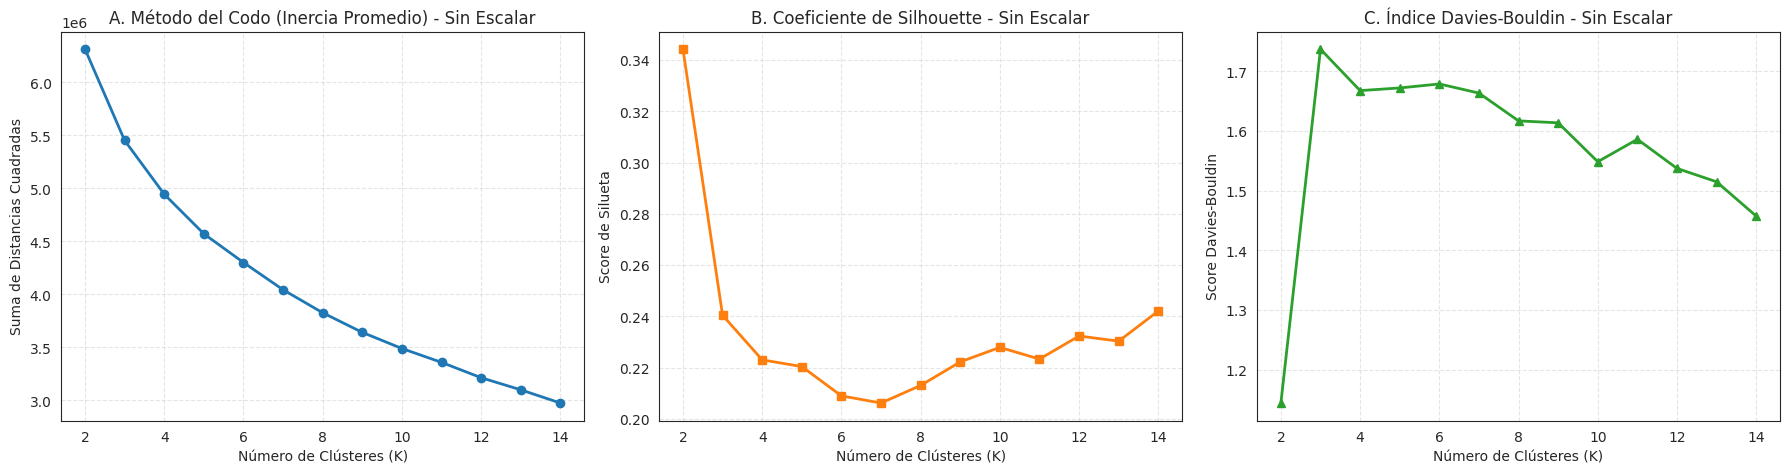

In [53]:
# Graficando
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Inercia (Buscar el \"Codo\")
ax1.plot(rango_k, inercias_mean_unscaled, marker='o', color='tab:blue', linewidth=2)
ax1.set_title('A. Método del Codo (Inercia Promedio) - Sin Escalar', fontsize=12)
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Suma de Distancias Cuadradas')
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel 2: Silueta (Buscar el Máximo)
ax2.plot(rango_k, siluetas_mean_unscaled, marker='s', color='tab:orange', linewidth=2)
ax2.set_title('B. Coeficiente de Silhouette - Sin Escalar', fontsize=12)
ax2.set_xlabel('Número de Clústeres (K)')
ax2.set_ylabel('Score de Silueta')
ax2.grid(True, linestyle='--', alpha=0.5)

# Panel 3: Davies-Bouldin (Buscar el Mínimo)
ax3.plot(rango_k, davies_bouldin_mean_unscaled, marker='^', color='tab:green', linewidth=2)
ax3.set_title('C. Índice Davies-Bouldin - Sin Escalar', fontsize=12)
ax3.set_xlabel('Número de Clústeres (K)')
ax3.set_ylabel('Score Davies-Bouldin')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Guardar reporte de optimización
ruta_grafico_metricas_unscaled = os.path.join(path_kmeans, 'optimizacion_k_metrics_avg_unscaled.png')
plt.savefig(ruta_grafico_metricas_unscaled, dpi=300, bbox_inches='tight')
plt.show()

Visualizamos con PCA para el caso sin estandarizar

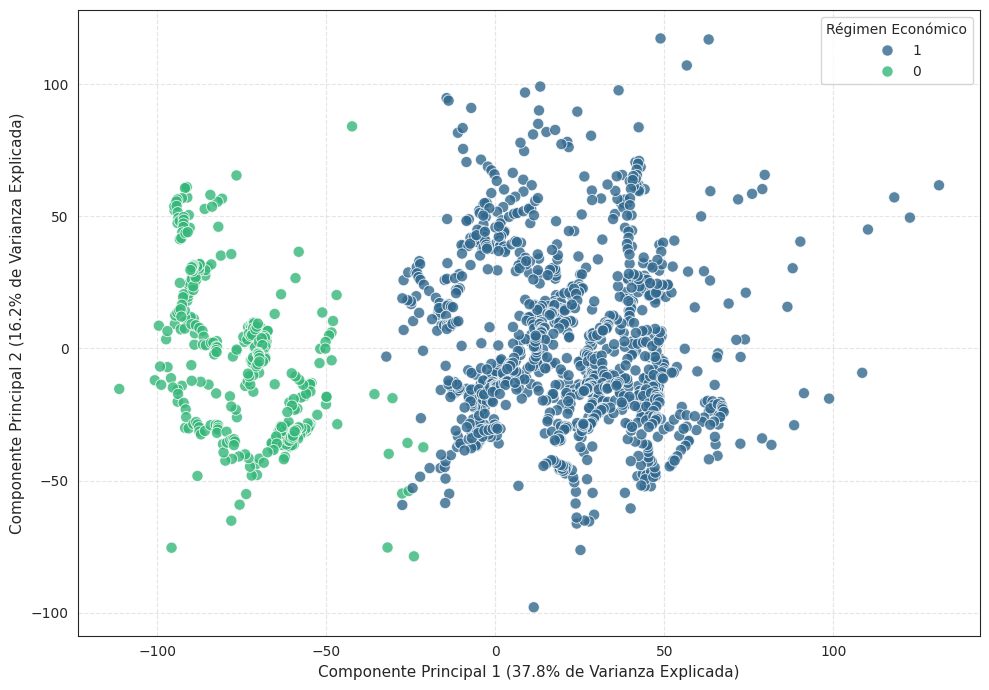

In [54]:
k_optimo_unscaled = 2

# Entrenar el modelo definitivo y asignar etiquetas de régimen
kmeans_final_unscaled = KMeans(n_clusters=k_optimo_unscaled, random_state=42, n_init=10)
df_cluster_input_unscaled['cluster_kmeans_unscaled'] = kmeans_final_unscaled.fit_predict(X_unscaled)

# Reducción de dimensionalidad con PCA para visualización espacial 2D
pca_unscaled = PCA(n_components=2, random_state=42)
X_pca_unscaled = pca_unscaled.fit_transform(X_unscaled)

df_visualizacion_unscaled = pd.DataFrame(data=X_pca_unscaled, columns=['Componente Principal 1', 'Componente Principal 2'])
df_visualizacion_unscaled['Régimen (Cluster)'] = df_cluster_input_unscaled['cluster_kmeans_unscaled'].astype(str)

# Graficar la dispersión espacial de los regímenes detectados
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='Régimen (Cluster)',
    data=df_visualizacion_unscaled,
    palette='viridis',
    alpha=0.8,
    edgecolor='w',
    s=65
)

# Capturamos los ratios de varianza para los ejes
var_explicada_unscaled = pca_unscaled.explained_variance_ratio_
plt.xlabel(f'Componente Principal 1 ({var_explicada_unscaled[0]*100:.1f}% de Varianza Explicada)', fontsize=11)
plt.ylabel(f'Componente Principal 2 ({var_explicada_unscaled[1]*100:.1f}% de Varianza Explicada)', fontsize=11)
# plt.title(f'Dispersión Espacial de Clústeres K-Means (K={k_optimo_unscaled}) - Sin Escalar', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Régimen Económico', loc='upper right')

# Guardar
ruta_grafico_final_clusters_unscaled = os.path.join(path_kmeans, f'dispersion_espacial_k{k_optimo_unscaled}_unscaled.png')
plt.tight_layout()
plt.savefig(ruta_grafico_final_clusters_unscaled, dpi=300)
plt.show()


Análisis de la lógica macroeconómica

In [55]:
# Creamos la copia explícita con las etiquetas fresquitas del último entrenamiento
df_regimenes_unscaled = df_cluster_input_unscaled.copy()
df_regimenes_unscaled['cluster_kmeans_unscaled'] = kmeans_final_unscaled.labels_

# Reseteamos el índice de demanda_var de forma temporal y segura, asegurando una copia explícita
df_demanda_temporal_unscaled = demanda_var.copy()
if 'fecha' not in df_demanda_temporal_unscaled.columns:
    df_demanda_temporal_unscaled = df_demanda_temporal_unscaled.reset_index()

# BLINDAJE: Si df_demanda_temporal ya arrastra una columna vieja 'cluster_kmeans', la eliminamos
if 'cluster_kmeans_unscaled' in df_demanda_temporal_unscaled.columns:
    df_demanda_temporal_unscaled = df_demanda_temporal_unscaled.drop(columns=['cluster_kmeans_unscaled'])

# Cruzamos de forma directa usando la columna 'fecha'
df_analisis_macro_unscaled = pd.merge(
    df_regimenes_unscaled[['fecha', 'cluster_kmeans_unscaled']],
    df_demanda_temporal_unscaled[['fecha', 'target_emae_ia', 'demanda_total_ia', 'ind_total_ia', 'temp_media_gba_ia']],
    on='fecha',
    how='inner'
)

# Calculamos las métricas macroeconómicas por régimen
resumen_regimenes_unscaled = df_analisis_macro_unscaled.groupby('cluster_kmeans_unscaled').agg(
    frecuencia=('fecha', 'count'),
    emae_promedio=('target_emae_ia', 'mean'),
    demanda_total_promedio=('demanda_total_ia', 'mean'),
    industria_promedio=('ind_total_ia', 'mean'),
    temperatura_promedio=('temp_media_gba_ia', 'mean')
).reset_index()

print(f"Caracterización Macroeconómica de los Regímenes Detectados (K={k_optimo_unscaled}) - Sin Escalar:")
display(resumen_regimenes_unscaled)


Caracterización Macroeconómica de los Regímenes Detectados (K=2) - Sin Escalar:


,cluster_kmeans_unscaled,frecuencia,emae_promedio,demanda_total_promedio,industria_promedio,temperatura_promedio
0,0,374,-1.175044,-0.339437,-11.340817,-1.612596
1,1,1207,2.794272,2.512970,0.144345,2.889125


In [56]:
demanda_var_clusters = demanda_var[['fecha']].copy()

demanda_var_clusters = pd.merge(
    demanda_var_clusters,
    df_cluster_input_unscaled[['fecha', 'cluster_kmeans_unscaled']],
    on='fecha',
    how='left'
)

# guardar
ruta_archivo_csv = os.path.join(path_resultados_particular, 'dataset_consolidado_clusters.csv')
demanda_var_clusters.to_csv(ruta_archivo_csv, index=False)

#### Enfoque regional

In [57]:
# Definir y crear la subcarpeta para el análisis regional
path_kmeans_regional = os.path.join(path_clustering, 'kmeans_regional')
os.makedirs(path_kmeans_regional, exist_ok=True)

In [58]:
# Selección estricta de atributos geográficos y climáticos
features_regional = [c for c in demanda_var.columns if c.startswith('reg_')]

print(f"• Variables seleccionadas para el enfoque regional ({len(features_regional)}):")
print(features_regional)

# Aseguramos un reset_index temporal si 'fecha' está actuando como índice en el dataset maestro
df_demanda_aux = demanda_var.reset_index() if 'fecha' not in demanda_var.columns else demanda_var.copy()

# Dropeamos filas con nulos remanentes en caso que hayan quedado
df_cluster_reg_input = df_demanda_aux[['periodo', 'fecha'] + features_regional].dropna().reset_index(drop=True)

# Estandarización de características (Media 0, Varianza 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_reg_input[features_regional])


• Variables seleccionadas para el enfoque regional (9):
['reg_patagonica_ia', 'reg_noreste_ia', 'reg_comahue_ia', 'reg_noroeste_ia', 'reg_litoral_ia', 'reg_gba_ia', 'reg_prov_ba_ia', 'reg_centro_ia', 'reg_cuyo_ia']


Optimización

In [59]:
# Promedio de 5 semillas para mayor robustez
random_seeds = [1009, 2003, 3001, 4001, 5003]

max_k = 15
all_inercias = {k: [] for k in range(2, max_k)}
all_siluetas = {k: [] for k in range(2, max_k)}
all_davies_bouldin = {k: [] for k in range(2, max_k)}

rango_k = range(2, max_k)

for seed in random_seeds:
    print(f"  Running K-Means (regional) with random_state = {seed}...")
    for k in rango_k:
        kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = kmeans.fit_predict(X_scaled)

        all_inercias[k].append(kmeans.inertia_)
        all_siluetas[k].append(silhouette_score(X_scaled, labels))
        all_davies_bouldin[k].append(davies_bouldin_score(X_scaled, labels))

# Calculamos el promedio de las métricas
inercias = [np.mean(all_inercias[k]) for k in rango_k]
siluetas = [np.mean(all_siluetas[k]) for k in rango_k]
davies_bouldin = [np.mean(all_davies_bouldin[k]) for k in rango_k]

  Running K-Means (regional) with random_state = 1009...
  Running K-Means (regional) with random_state = 2003...
  Running K-Means (regional) with random_state = 3001...
  Running K-Means (regional) with random_state = 4001...
  Running K-Means (regional) with random_state = 5003...


Gráficos

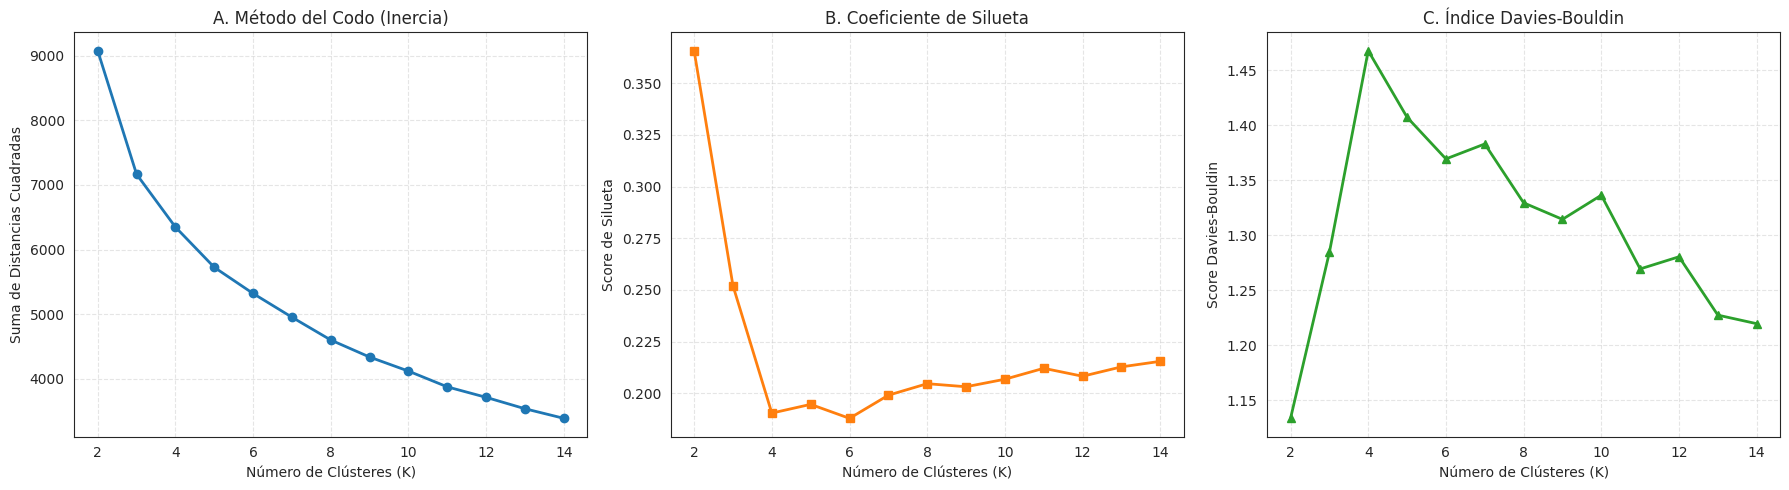

In [60]:
# Generación del gráfico de diagnóstico de tres paneles
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Método del Codo
ax1.plot(rango_k, inercias, marker='o', color='tab:blue', linewidth=2)
ax1.set_title('A. Método del Codo (Inercia)', fontsize=12)
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Suma de Distancias Cuadradas')
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel B: Coeficiente de Silueta (max)
ax2.plot(rango_k, siluetas, marker='s', color='tab:orange', linewidth=2)
ax2.set_title('B. Coeficiente de Silueta', fontsize=12)
ax2.set_xlabel('Número de Clústeres (K)')
ax2.set_ylabel('Score de Silueta')
ax2.grid(True, linestyle='--', alpha=0.5)

# Panel C: Índice Davies-Bouldin (min)
ax3.plot(rango_k, davies_bouldin, marker='^', color='tab:green', linewidth=2)
ax3.set_title('C. Índice Davies-Bouldin', fontsize=12)
ax3.set_xlabel('Número de Clústeres (K)')
ax3.set_ylabel('Score Davies-Bouldin')
ax3.grid(True, linestyle='--', alpha=0.5)

# plt.suptitle('Optimización de Hiperparámetros - K-Means REGIONAL', fontsize=14, y=1.05)
plt.tight_layout()

# Guardar
ruta_grafico_regional = os.path.join(path_kmeans_regional, 'optimizacion_k_regional.png')
plt.savefig(ruta_grafico_regional, dpi=300, bbox_inches='tight')
plt.show()



Visualización del PCA

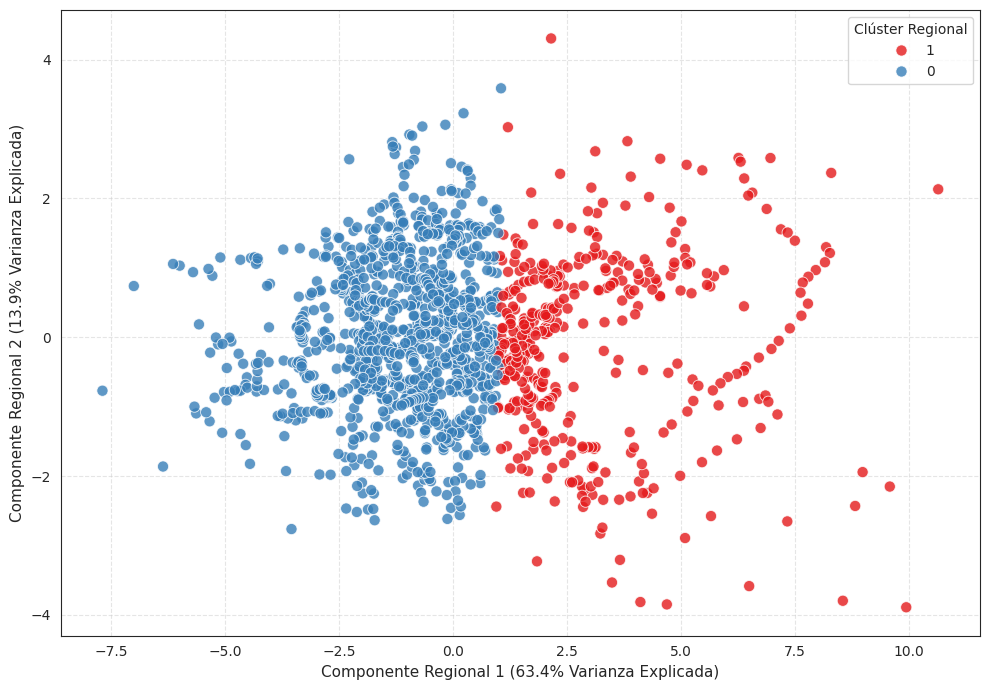

In [61]:
k_optimo_regional = 2

# Entrenar el modelo regional definitivo
kmeans_regional = KMeans(n_clusters=k_optimo_regional, random_state=42, n_init=10)
df_cluster_reg_input['cluster_regional'] = kmeans_regional.fit_predict(X_scaled)

# Creamos una copia temporal de `demanda_var` para realizar las operaciones
df_demanda_temp = demanda_var.reset_index() if 'fecha' not in demanda_var.columns else demanda_var.copy()

# Acoplamos las etiquetas de cluster a la copia temporal limpia
df_unificado = pd.merge(
    df_demanda_temp,
    df_cluster_reg_input[['fecha', 'cluster_regional']],
    on='fecha',
    how='left'
)

# Reducción a 2 componentes con PCA para el espacio geográfico
pca_reg = PCA(n_components=2, random_state=42)
X_pca_reg = pca_reg.fit_transform(X_scaled)

df_vis_reg = pd.DataFrame(data=X_pca_reg, columns=['Componente Regional 1', 'Componente Regional 2'])
df_vis_reg['Régimen Territorial'] = df_cluster_reg_input['cluster_regional'].astype(str)

# Graficar la dispersión espacial de los clústeres regionales
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente Regional 1',
    y='Componente Regional 2',
    hue='Régimen Territorial',
    data=df_vis_reg,
    palette='Set1', # Cambiamos paleta para diferenciarlo del análisis total
    alpha=0.8,
    edgecolor='w',
    s=65
)

var_exp_reg = pca_reg.explained_variance_ratio_
# plt.title(f'Espacio Latente Regional (PCA) y Dispersión de Clústeres (K={k_optimo_regional})', fontsize=13, pad=15)
plt.xlabel(f'Componente Regional 1 ({var_exp_reg[0]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.ylabel(f'Componente Regional 2 ({var_exp_reg[1]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clúster Regional', loc='upper right')

# Guardar gráfico
ruta_grafico_spatial_regional = os.path.join(path_kmeans_regional, f'dispersion_regional_k{k_optimo_regional}.png')
plt.tight_layout()
plt.savefig(ruta_grafico_spatial_regional, dpi=300)
plt.show()

Análisis económico de los Cluster regionales

In [62]:
# Copia con las etiquetas del último entrenamiento regional
df_regimenes_reg = df_cluster_reg_input.copy()
df_regimenes_reg['cluster_regional'] = kmeans_regional.labels_

# Reseteo temporal del índice maestro libre de residuos
df_demanda_temporal = demanda_var.reset_index() if 'fecha' not in demanda_var.columns else demanda_var.copy()

if 'cluster_regional' in df_demanda_temporal.columns:
    df_demanda_temporal = df_demanda_temporal.drop(columns=['cluster_regional'])

columnas_residuales = [c for c in df_demanda_temporal.columns if c.startswith('cluster_regional_') or c == 'index']
if columnas_residuales:
    df_demanda_temporal = df_demanda_temporal.drop(columns=columnas_residuales)

# Cruzar etiquetas regionales con la macro nacional
df_analisis_macro_reg = pd.merge(
    df_regimenes_reg[['fecha', 'cluster_regional']],
    df_demanda_temporal[['fecha', 'target_emae_ia', 'demanda_total_ia', 'ind_total_ia', 'temp_media_gba_ia']],
    on='fecha',
    how='inner'
)

# Tabla de promedios
resumen_regional_macro = df_analisis_macro_reg.groupby('cluster_regional').agg(
    frecuencia=('fecha', 'count'),
    emae_promedio=('target_emae_ia', 'mean'),
    demanda_total_promedio=('demanda_total_ia', 'mean'),
    industria_promedio=('ind_total_ia', 'mean'),
    temperatura_promedio=('temp_media_gba_ia', 'mean')
).reset_index()

print(f"Caracterización Macroeconómica de los Regímenes Regionales (K={k_optimo_regional}):")
display(resumen_regional_macro)

Caracterización Macroeconómica de los Regímenes Regionales (K=2):


,cluster_regional,frecuencia,emae_promedio,demanda_total_promedio,industria_promedio,temperatura_promedio
0,0,1176,1.323943,-2.441711,-3.447702,2.314212
1,1,405,3.446491,14.265821,-0.031464,0.401358


#### Enfoque por actividad

In [63]:
# Definir carpeta
path_kmeans_actividad = os.path.join(path_clustering, 'kmeans_actividad')
os.makedirs(path_kmeans_actividad, exist_ok=True)

Definimos las variables a utilizar

In [64]:
# Selección estricta de ramas industriales y comerciales (excluyendo agregados totales y nulos)
columnas_excluidas_act = [
    'periodo', 'fecha', 'anio', 'mes', 'dia', 'tipo_dia_texto',
    'es_habil', 'dia_semana_num', 'dia_avance', 'target_emae_ia',
    'demanda_total_ia', 'ind_total_ia', 'temp_media_gba_ia'
]

features_actividad = [
    c for c in demanda_var.columns
    if (c.startswith('ind_') or c.startswith('comercio_') or c.startswith('serv_'))
    and c not in columnas_excluidas_act
    and 'lag' not in c
]

print(f"\n• Variables seleccionadas para el enfoque por actividad ({len(features_actividad)}):")
print(features_actividad)

# Aseguramos un reset_index temporal si 'fecha' actúa como índice en el dataset maestro
df_demanda_aux_act = demanda_var.reset_index() if 'fecha' not in demanda_var.columns else demanda_var.copy()

# Dropeamos filas con posibles nulos remanentes
df_cluster_input_act = df_demanda_aux_act[['periodo', 'fecha'] + features_actividad].dropna().reset_index(drop=True)

# Estandarización de características (Media 0, Varianza 1)
scaler_act = StandardScaler()
X_scaled_act = scaler_act.fit_transform(df_cluster_input_act[features_actividad])


• Variables seleccionadas para el enfoque por actividad (13):
['ind_aluar_ia', 'comercio_servicios_ia', 'serv_publicos_transporte_ia', 'ind_metalica_no_auto_ia', 'ind_textile_ia', 'ind_extraccion_minerales_ia', 'ind_construccion_ia', 'ind_quimica_plastico_ia', 'ind_madera_papel_ia', 'ind_alimentacion_ia', 'ind_automotriz_ia', 'ind_petroleo_minerales_total_ia', 'ind_derivados_petroleo_ia']


Optimizamos

In [65]:
# Optimización del número de clústeres (K) para el caso de Actividad
random_seeds = [1009, 2003, 3001, 4001, 5003]
max_k = 15 # Consistent with previous optimizations

all_inercias_act = {k: [] for k in range(2, max_k)}
all_siluetas_act = {k: [] for k in range(2, max_k)}
all_davies_bouldin_act = {k: [] for k in range(2, max_k)}

rango_k = range(2, max_k)

for seed in random_seeds:
    print(f"  Running K-Means (actividad) with random_state = {seed}...")
    for k in rango_k:
        kmeans_act = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels_act = kmeans_act.fit_predict(X_scaled_act)

        all_inercias_act[k].append(kmeans_act.inertia_)
        all_siluetas_act[k].append(silhouette_score(X_scaled_act, labels_act))
        all_davies_bouldin_act[k].append(davies_bouldin_score(X_scaled_act, labels_act))

# Calculamos el promedio de las métricas
inercias_act_mean = [np.mean(all_inercias_act[k]) for k in rango_k]
siluetas_act_mean = [np.mean(all_siluetas_act[k]) for k in rango_k]
davies_bouldin_act_mean = [np.mean(all_davies_bouldin_act[k]) for k in rango_k]

  Running K-Means (actividad) with random_state = 1009...
  Running K-Means (actividad) with random_state = 2003...
  Running K-Means (actividad) with random_state = 3001...
  Running K-Means (actividad) with random_state = 4001...
  Running K-Means (actividad) with random_state = 5003...


Graficamos

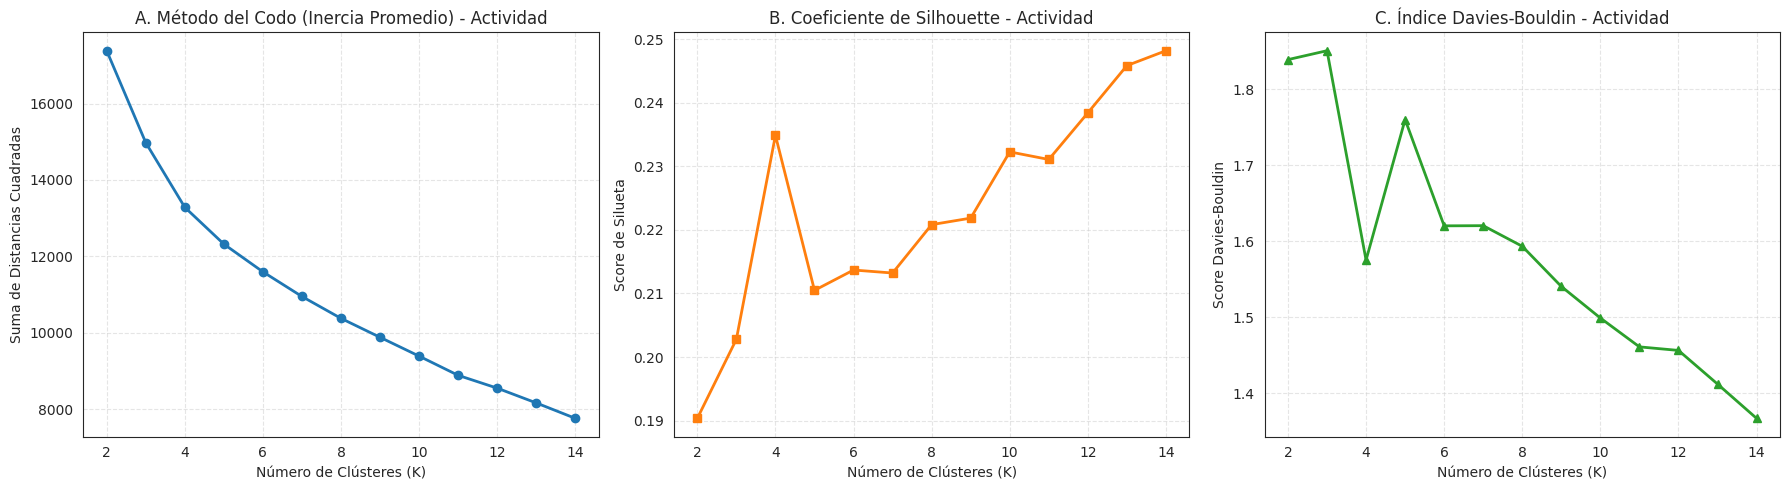

In [66]:
# Graficar las métricas de optimización para el caso de Actividad
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Inercia (Buscar el "Codo")
ax1.plot(rango_k, inercias_act_mean, marker='o', color='tab:blue', linewidth=2)
ax1.set_title('A. Método del Codo (Inercia Promedio) - Actividad', fontsize=12)
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Suma de Distancias Cuadradas')
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel 2: Silueta (Buscar el Máximo)
ax2.plot(rango_k, siluetas_act_mean, marker='s', color='tab:orange', linewidth=2)
ax2.set_title('B. Coeficiente de Silhouette - Actividad', fontsize=12)
ax2.set_xlabel('Número de Clústeres (K)')
ax2.set_ylabel('Score de Silueta')
ax2.grid(True, linestyle='--', alpha=0.5)

# Panel 3: Davies-Bouldin (Buscar el Mínimo)
ax3.plot(rango_k, davies_bouldin_act_mean, marker='^', color='tab:green', linewidth=2)
ax3.set_title('C. Índice Davies-Bouldin - Actividad', fontsize=12)
ax3.set_xlabel('Número de Clústeres (K)')
ax3.set_ylabel('Score Davies-Bouldin')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Guardar
ruta_grafico_metricas_act = os.path.join(path_kmeans_actividad, 'optimizacion_k_metrics_avg_actividad.png')
plt.savefig(ruta_grafico_metricas_act, dpi=300, bbox_inches='tight')
plt.show()

Visualización con PCA

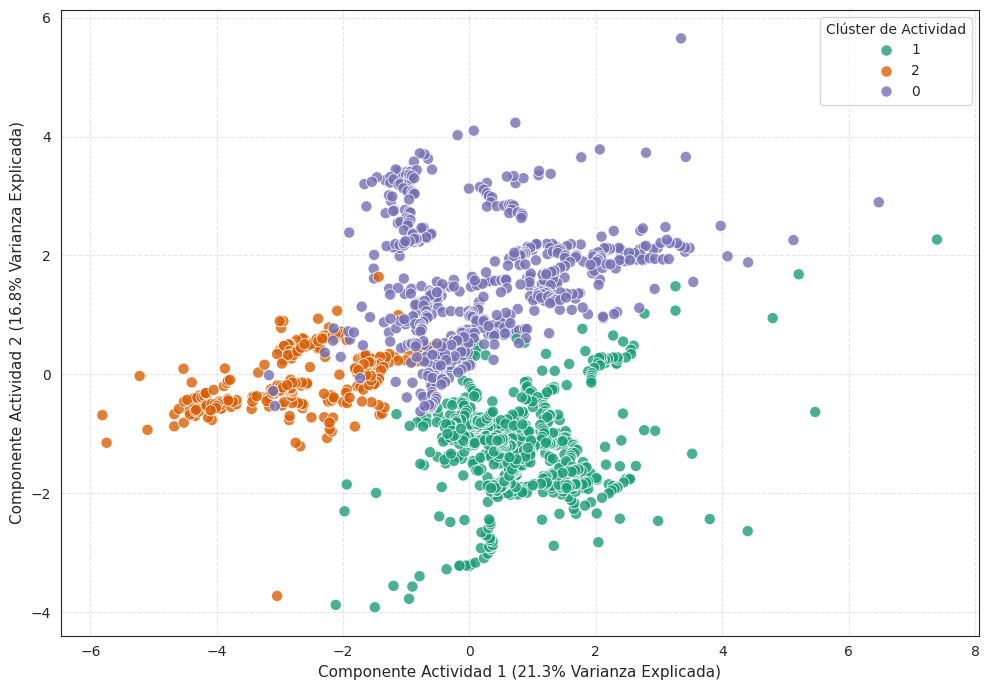

In [67]:
# Visualización con PCA para el caso de Actividad

k_optimo_act = 3 # se debería determinar de los gráficos

# Entrenar el modelo de actividad definitivo
kmeans_act_final = KMeans(n_clusters=k_optimo_act, random_state=42, n_init=10)
df_cluster_input_act['cluster_actividad'] = kmeans_act_final.fit_predict(X_scaled_act)

# Reducción a 2 componentes con PCA para el espacio de actividad
pca_act = PCA(n_components=2, random_state=42)
X_pca_act = pca_act.fit_transform(X_scaled_act)

df_vis_act = pd.DataFrame(data=X_pca_act, columns=['Componente Actividad 1', 'Componente Actividad 2'])
df_vis_act['Régimen Productivo'] = df_cluster_input_act['cluster_actividad'].astype(str)

# Graficar la dispersión espacial de los clústeres de actividad
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente Actividad 1',
    y='Componente Actividad 2',
    hue='Régimen Productivo',
    data=df_vis_act,
    palette='Dark2', # Paleta diferenciada
    alpha=0.8,
    edgecolor='w',
    s=65
)

var_exp_act = pca_act.explained_variance_ratio_
# plt.title(f'Espacio Latente Industrial (PCA) y Dispersión de Clústeres (K={k_optimo_act}) - Actividad', fontsize=13, pad=15)
plt.xlabel(f'Componente Actividad 1 ({var_exp_act[0]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.ylabel(f'Componente Actividad 2 ({var_exp_act[1]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clúster de Actividad', loc='upper right')

# Guardar gráfico
ruta_grafico_spatial_act = os.path.join(path_kmeans_actividad, f'dispersion_actividad_k{k_optimo_act}.png')
plt.tight_layout()
plt.savefig(ruta_grafico_spatial_act, dpi=300)
plt.show()




Análisis económico de los clusters por actividad

In [68]:
# Copia con las etiquetas del último entrenamiento de actividad
df_regimenes_act = df_cluster_input_act.copy()
df_regimenes_act['cluster_actividad'] = kmeans_act_final.labels_

# Reseteo temporal del índice maestro libre de residuos (sin modificar demanda_var)
df_demanda_temporal = demanda_var.reset_index() if 'fecha' not in demanda_var.columns else demanda_var.copy()

# Cruzar etiquetas de actividad con la macro nacional
df_analisis_macro_act = pd.merge(
    df_regimenes_act[['fecha', 'cluster_actividad']],
    df_demanda_temporal[['fecha', 'target_emae_ia', 'demanda_total_ia', 'ind_total_ia', 'temp_media_gba_ia']],
    on='fecha',
    how='inner'
)

# Calcular tabla de promedios
resumen_act_macro = df_analisis_macro_act.groupby('cluster_actividad').agg(
    frecuencia=('fecha', 'count'),
    emae_promedio=('target_emae_ia', 'mean'),
    demanda_total_promedio=('demanda_total_ia', 'mean'),
    industria_promedio=('ind_total_ia', 'mean'),
    temperatura_promedio=('temp_media_gba_ia', 'mean')
).reset_index()

print(f"Caracterización Macroeconómica de los Regímenes por Actividad (K={k_optimo_act}):")
display(resumen_act_macro)

Caracterización Macroeconómica de los Regímenes por Actividad (K=3):


,cluster_actividad,frecuencia,emae_promedio,demanda_total_promedio,industria_promedio,temperatura_promedio
0,0,602,3.825049,1.129348,-0.122453,3.015282
1,1,706,1.892438,3.383291,-1.141341,3.868249
2,2,273,-2.471053,-0.594380,-11.676692,-6.088355


### DBSCAN

In [69]:
# Crear subcarpeta específica para DBSCAN
path_dbscan = os.path.join(path_clustering, 'dbscan')
os.makedirs(path_dbscan, exist_ok=True)

Definición de variables y del df auxiliar

In [70]:
# Definición de columnas no features para el clustering
columnas_no_features = [
    'periodo', 'fecha', 'anio', 'mes', 'dia', 'tipo_dia_texto',
    'es_habil', 'dia_semana_num', 'dia_avance', 'target_emae_ia'
]

# Seleccionamos todas las variables que terminan en '_ia' y no son las excluidas
features_dbscan_all = [
    c for c in demanda_var.columns
    if c.endswith('_ia') and c not in columnas_no_features
]

print(f"\n• Variables seleccionadas para el enfoque DBSCAN:")
print(features_dbscan_all)



• Variables seleccionadas para el enfoque DBSCAN:
['ind_aluar_ia', 'ind_total_ia', 'reg_patagonica_ia', 'reg_noreste_ia', 'comercio_servicios_ia', 'reg_comahue_ia', 'reg_noroeste_ia', 'reg_litoral_ia', 'temp_media_gba_ia', 'serv_publicos_transporte_ia', 'reg_gba_ia', 'ind_metalica_no_auto_ia', 'ind_textile_ia', 'ind_extraccion_minerales_ia', 'ind_construccion_ia', 'ind_quimica_plastico_ia', 'reg_prov_ba_ia', 'ind_madera_papel_ia', 'reg_centro_ia', 'ind_alimentacion_ia', 'ind_automotriz_ia', 'ind_petroleo_minerales_total_ia', 'reg_cuyo_ia', 'demanda_total_ia', 'ind_derivados_petroleo_ia']


In [71]:
# Reset temporal de fecha para el procesamiento
df_demanda_aux = demanda_var.copy()
if 'fecha' not in df_demanda_aux.columns and 'fecha' in demanda_var.index.names:
    df_demanda_aux = df_demanda_aux.reset_index()

df_cluster_input = df_demanda_aux[['periodo', 'fecha'] + features_dbscan_all].dropna().reset_index(drop=True)

# Estandarización estricta
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_input[features_dbscan_all])

Optimización

In [72]:
k_vecinos = 2 * len(features_dbscan_all)

# Calcular las distancias de los vecinos más cercanos
neighbors = NearestNeighbors(n_neighbors=k_vecinos)
neighbors_fit = neighbors.fit(X_scaled)
distancias, indices = neighbors_fit.kneighbors(X_scaled)

distancias_ordenadas = np.sort(distancias[:, k_vecinos-1], axis=0)

Gráfico

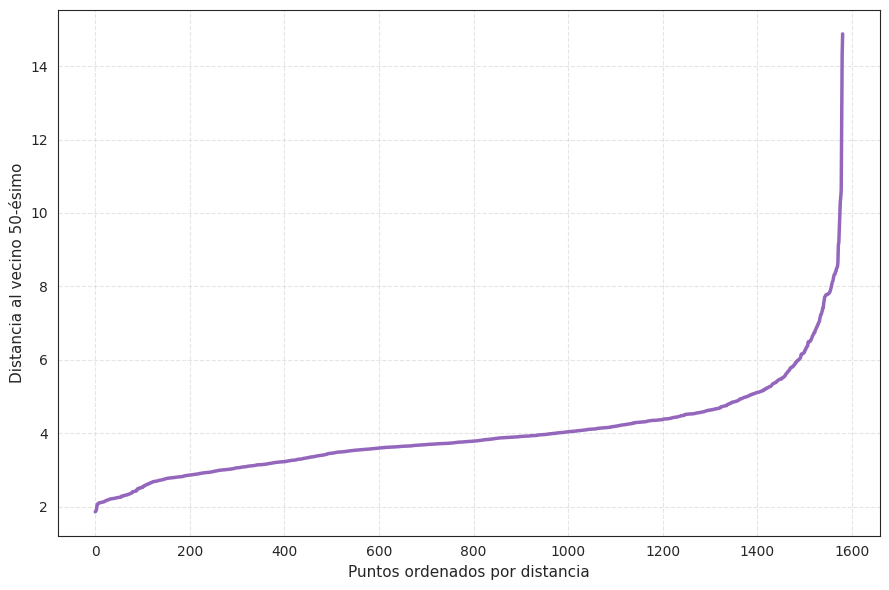

In [73]:
# Graficar el método del codo para el radio EPS
plt.figure(figsize=(9, 6))
plt.plot(distancias_ordenadas, color='tab:purple', linewidth=2.5)
# plt.title('Gráfico de K-Distancia para Optimizar EPS en DBSCAN (Todas las variables)', fontsize=13, pad=15)
plt.xlabel('Puntos ordenados por distancia', fontsize=11)
plt.ylabel(f'Distancia al vecino {k_vecinos}-ésimo', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Guardar diagnóstico en Drive
ruta_grafico_kdist = os.path.join(path_dbscan, 'optimizacion_eps_kdistance_all_features.png')
plt.tight_layout()
plt.savefig(ruta_grafico_kdist, dpi=300)
plt.show()

Entrenamiento del DBSCAN

In [74]:
#Configuración
eps_optimo = 5
min_samples_optimo = k_vecinos

# Entrenar el modelo de Densidad DBSCAN
dbscan_model = DBSCAN(eps=eps_optimo, min_samples=min_samples_optimo)
df_cluster_input['cluster_dbscan'] = dbscan_model.fit_predict(X_scaled)

# Merge del df unificado en un dataframe auxiliar
demanda_var_with_dbscan_clusters = pd.merge(
    demanda_var.copy(),
    df_cluster_input[['fecha', 'cluster_dbscan']],
    on='fecha',
    how='left'
)

# Establecemos 'fecha' como índice en el nuevo DataFrame
demanda_var_with_dbscan_clusters = demanda_var_with_dbscan_clusters.set_index('fecha')
if 'index' in demanda_var_with_dbscan_clusters.columns:
    demanda_var_with_dbscan_clusters = demanda_var_with_dbscan_clusters.drop(columns=['index'])

# Contamos la cantidad de clústeres reales y el ruido
etiquetas = df_cluster_input['cluster_dbscan'].unique()
num_clusters = len([x for x in etiquetas if x >= 0])
num_ruido = list(df_cluster_input['cluster_dbscan']).count(-1)

print(f"DBSCAN detectó: {num_clusters} clústeres densos y {num_ruido} puntos de ruido (outliers).")


DBSCAN detectó: 1 clústeres densos y 48 puntos de ruido (outliers).


Gráfico con PCA

In [75]:
# Reducción a 2 Componentes con PCA para evaluar visualmente las fronteras de densidad
pca_db = PCA(n_components=2, random_state=42)
X_pca_db = pca_db.fit_transform(X_scaled)

df_vis_db = pd.DataFrame(data=X_pca_db, columns=['Componente 1', 'Componente 2'])
# Mapeamos a string y cambiamos el '-1' por 'Ruido / Outlier' para el gráfico
df_vis_db['Régimen de Densidad'] = df_cluster_input['cluster_dbscan'].astype(str).replace('-1', 'Ruido / Outlier')

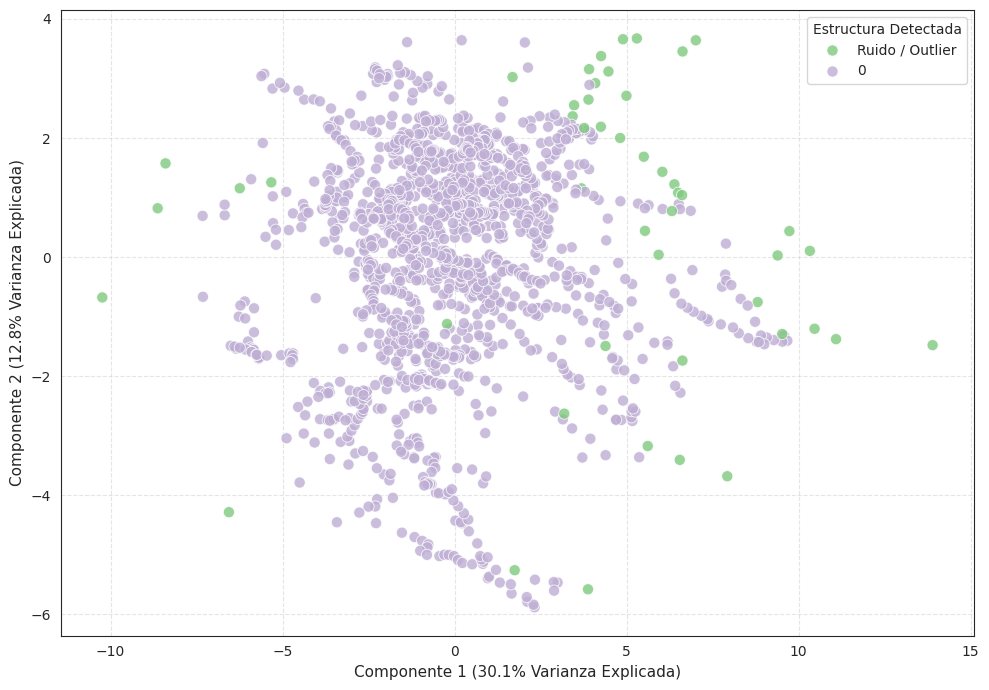

In [76]:
# Graficar la dispersión espacial de DBSCAN
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente 1',
    y='Componente 2',
    hue='Régimen de Densidad',
    data=df_vis_db,
    palette='Accent',
    alpha=0.8,
    edgecolor='w',
    s=65
)

var_exp_db = pca_db.explained_variance_ratio_
#plt.title(f'Espacio Latente Industrial (PCA) - Regímenes por Densidad DBSCAN', fontsize=13, pad=15)
plt.xlabel(f'Componente 1 ({var_exp_db[0]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.ylabel(f'Componente 2 ({var_exp_db[1]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Estructura Detectada', loc='upper right')

# Guardar gráfico
ruta_grafico_spatial_dbscan = os.path.join(path_dbscan, 'dispersion_spatial_dbscan.png')
plt.tight_layout()
plt.savefig(ruta_grafico_spatial_dbscan, dpi=300)
plt.show()

Análisis económico de los clusters

In [77]:
# Copia limpia con las últimas etiquetas de densidad
df_regimenes_db = df_cluster_input.copy()

# Preparamos una copia de demanda_var
df_demanda_temporal = demanda_var.copy()
if df_demanda_temporal.index.name == 'fecha':
    df_demanda_temporal = df_demanda_temporal.reset_index()

# Merge y agrupación macroeconómica
df_analisis_macro_db = pd.merge(
    df_regimenes_db[['fecha', 'cluster_dbscan']],
    df_demanda_temporal[['fecha', 'target_emae_ia', 'demanda_total_ia', 'ind_total_ia', 'temp_media_gba_ia']],
    on='fecha',
    how='inner'
)

resumen_dbscan_macro = df_analisis_macro_db.groupby('cluster_dbscan').agg(
    frecuencia=('fecha', 'count'),
    emae_promedio=('target_emae_ia', 'mean'),
    demanda_total_promedio=('demanda_total_ia', 'mean'),
    industria_promedio=('ind_total_ia', 'mean'),
    temperatura_promedio=('temp_media_gba_ia', 'mean')
).reset_index()

# Formateamos el ID para la presentación
resumen_dbscan_macro['cluster_dbscan'] = resumen_dbscan_macro['cluster_dbscan'].astype(str).replace('-1', '-1 (Ruido/Outlier)')
print("Caracterización Macroeconómica - Regímenes de Densidad DBSCAN:")
display(resumen_dbscan_macro)

Caracterización Macroeconómica - Regímenes de Densidad DBSCAN:


,cluster_dbscan,frecuencia,emae_promedio,demanda_total_promedio,industria_promedio,temperatura_promedio
0,-1 (Ruido/Outlier),48,3.609270,13.368733,2.233531,11.931665
1,0,1533,1.785391,1.477173,-2.723059,1.507725


In [78]:
demanda_var_clusters = pd.merge(
    demanda_var_clusters,
    df_cluster_input[['fecha', 'cluster_dbscan']],
    on='fecha',
    how='left'
)

# Optionally, save the updated DataFrame to CSV
ruta_archivo_csv = os.path.join(path_resultados_particular, 'dataset_consolidado_clusters.csv')
demanda_var_clusters.to_csv(ruta_archivo_csv, index=False)

#### Enfoque regional

In [79]:
# Crear subcarpeta específica para DBSCAN Regional
path_dbscan_reg = os.path.join(path_clustering, 'dbscan_regional')
os.makedirs(path_dbscan_reg, exist_ok=True)

Selección de variables y estandarización

In [80]:
# Selección de variables regionales + temperatura
features_regional = [c for c in demanda_var.columns if c.startswith('reg_') and 'lag' not in c]
if 'temp_media_gba_ia' in demanda_var.columns:
    features_regional.append('temp_media_gba_ia')

# Reset temporal seguro de fecha
df_demanda_aux = demanda_var.reset_index() if 'fecha' not in demanda_var.columns else demanda_var.copy()
df_input_reg = df_demanda_aux[['periodo', 'fecha'] + features_regional].dropna().reset_index(drop=True)

# Estandarización
scaler_reg = StandardScaler()
X_scaled_reg = scaler_reg.fit_transform(df_input_reg[features_regional])

# Cálculo de K-Distancia
min_samples_reg = 2 * len(features_regional)
print(f"min_samples regional sugerido = {min_samples_reg} (basado en {len(features_regional)} variables)")

neighbors_reg = NearestNeighbors(n_neighbors=min_samples_reg)
neighbors_reg.fit(X_scaled_reg)
distancias_reg, _ = neighbors_reg.kneighbors(X_scaled_reg)
dist_ordenadas_reg = np.sort(distancias_reg[:, min_samples_reg-1], axis=0)

min_samples regional sugerido = 20 (basado en 10 variables)


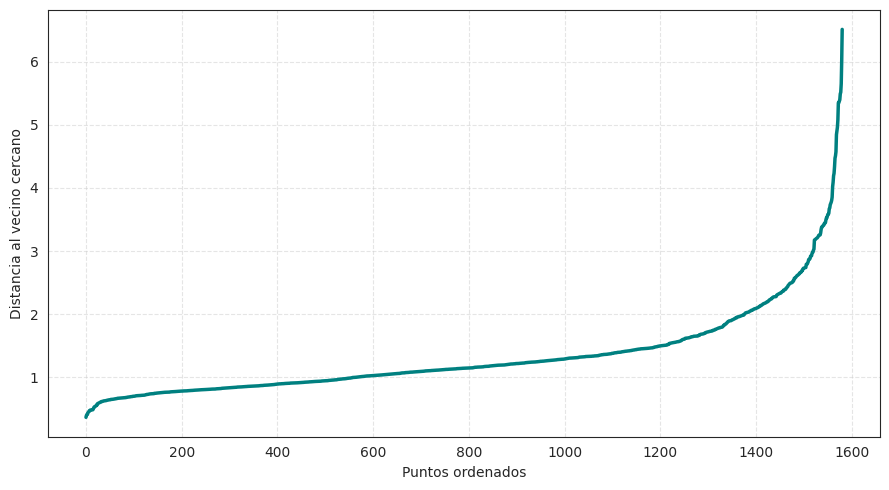

In [81]:
# Graficar
plt.figure(figsize=(9, 5))
plt.plot(dist_ordenadas_reg, color='teal', linewidth=2.5)
# plt.title('Gráfico de K-Distancia - DBSCAN REGIONAL', fontsize=12)
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al vecino cercano')
plt.grid(True, linestyle='--', alpha=0.5)

ruta_kdist_reg = os.path.join(path_dbscan_reg, 'kdistance_regional.png')
plt.tight_layout()
plt.savefig(ruta_kdist_reg, dpi=300)
plt.show()


DBSCAN Regional detectó: 1 clústeres densos y 103 puntos de ruido (outliers).


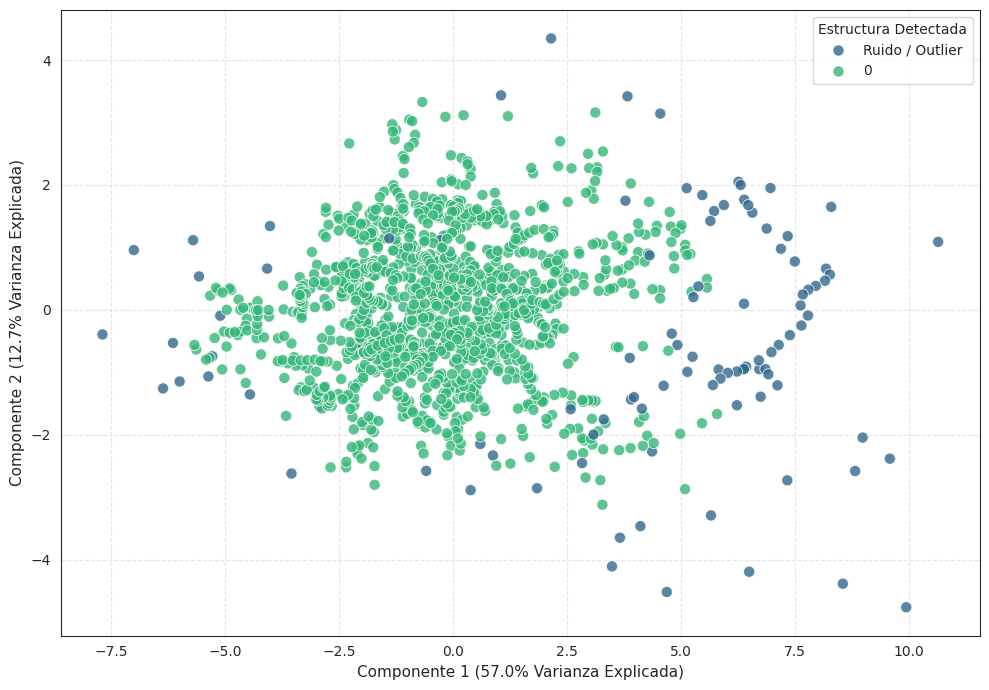

In [82]:
# Configuración
eps_reg_optimo = 2.0

# Entrenar DBSCAN Regional
dbscan_reg = DBSCAN(eps=eps_reg_optimo, min_samples=min_samples_reg)
df_input_reg['cluster_dbscan_regional'] = dbscan_reg.fit_predict(X_scaled_reg)

# Contamos la cantidad de clústeres reales y el ruido
etiquetas_reg = df_input_reg['cluster_dbscan_regional'].unique()
num_clusters_reg = len([x for x in etiquetas_reg if x >= 0])
num_ruido_reg = list(df_input_reg['cluster_dbscan_regional']).count(-1)
print(f"\nDBSCAN Regional detectó: {num_clusters_reg} clústeres densos y {num_ruido_reg} puntos de ruido (outliers).")

# Crear una copia de demanda_var para el análisis
df_temp_demanda_var_for_analysis = demanda_var.copy()
if df_temp_demanda_var_for_analysis.index.name == 'fecha':
    df_temp_demanda_var_for_analysis = df_temp_demanda_var_for_analysis.reset_index()

# Eliminar cualquier columna de cluster regional antigua para evitar duplicados en el merge
if 'cluster_dbscan_regional' in df_temp_demanda_var_for_analysis.columns:
    df_temp_demanda_var_for_analysis = df_temp_demanda_var_for_analysis.drop(columns=['cluster_dbscan_regional'])

df_unificado_reg_dbscan_for_analysis = pd.merge(
    df_temp_demanda_var_for_analysis,
    df_input_reg[['fecha', 'cluster_dbscan_regional']],
    on='fecha',
    how='left'
)

# Reestablecer el índice 'fecha' si era el original y no se perdió en el proceso
if 'fecha' in df_unificado_reg_dbscan_for_analysis.columns:
    df_unificado_reg_dbscan_for_analysis = df_unificado_reg_dbscan_for_analysis.set_index('fecha')

# Visualización con PCA
pca_db_reg = PCA(n_components=2, random_state=42)
X_pca_db_reg = pca_db_reg.fit_transform(X_scaled_reg)

df_vis_db_reg = pd.DataFrame(data=X_pca_db_reg, columns=['Componente 1', 'Componente 2'])
df_vis_db_reg['Régimen de Densidad Regional'] = df_input_reg['cluster_dbscan_regional'].astype(str).replace('-1', 'Ruido / Outlier')

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente 1',
    y='Componente 2',
    hue='Régimen de Densidad Regional',
    data=df_vis_db_reg,
    palette='viridis',
    alpha=0.8,
    edgecolor='w',
    s=65
)

var_exp_db_reg = pca_db_reg.explained_variance_ratio_
plt.xlabel(f'Componente 1 ({var_exp_db_reg[0]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.ylabel(f'Componente 2 ({var_exp_db_reg[1]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Estructura Detectada', loc='upper right')

ruta_grafico_spatial_dbscan_reg = os.path.join(path_dbscan_reg, 'dispersion_spatial_dbscan_regional.png')
plt.tight_layout()
plt.savefig(ruta_grafico_spatial_dbscan_reg, dpi=300)
plt.show()


Análisis económico de los clusters

In [83]:
# Caracterización macroeconómica
df_macro_reg = pd.merge(
    df_input_reg[['fecha', 'cluster_dbscan_regional']],
    df_unificado_reg_dbscan_for_analysis.reset_index()[['fecha', 'target_emae_ia', 'demanda_total_ia', 'ind_total_ia', 'temp_media_gba_ia']],
    on='fecha',
    how='inner'
)

resumen_reg = df_macro_reg.groupby('cluster_dbscan_regional').agg(
    frecuencia=('fecha', 'count'),
    emae_promedio=('target_emae_ia', 'mean'),
    demanda_total_promedio=('demanda_total_ia', 'mean'),
    industria_promedio=('ind_total_ia', 'mean'),
    temperatura_promedio=('temp_media_gba_ia', 'mean')
).reset_index()

resumen_reg['cluster_dbscan_regional'] = resumen_reg['cluster_dbscan_regional'].astype(str).replace('-1', '-1 (Ruido)')
print("Caracterización Macroeconómica - DBSCAN REGIONAL:")
display(resumen_reg)

Caracterización Macroeconómica - DBSCAN REGIONAL:


,cluster_dbscan_regional,frecuencia,emae_promedio,demanda_total_promedio,industria_promedio,temperatura_promedio
0,-1 (Ruido),103,2.116856,17.166769,-0.471358,18.196735
1,0,1478,1.818471,0.769979,-2.719006,0.683220


#### Enfoque por actividad

In [84]:
# Crear subcarpeta
path_dbscan_sec = os.path.join(path_clustering, 'dbscan_sectorial')
os.makedirs(path_dbscan_sec, exist_ok=True)

print(f"Carpeta creada para resultados de DBSCAN Sectorial: {path_dbscan_sec}")

Carpeta creada para resultados de DBSCAN Sectorial: /content/drive/MyDrive/Maestría en Data Mining/Taller de Tesis I/Final V6/Resultados/Clustering/dbscan_sectorial


In [85]:
# Selección de variables de ramas (excluyendo totales e índices agregados)
columnas_excluidas_act_dbscan = [
    'periodo', 'fecha', 'anio', 'mes', 'dia', 'tipo_dia_texto',
    'es_habil', 'dia_semana_num', 'dia_avance', 'target_emae_ia',
    'demanda_total_ia', 'ind_total_ia', 'temp_media_gba_ia'
]

features_sectorial = [
    c for c in demanda_var.columns
    if (c.startswith('ind_') or c.startswith('comercio_') or c.startswith('serv_'))
    and c not in columnas_excluidas_act_dbscan
    and 'lag' not in c
]

print(f"• Variables seleccionadas para el enfoque DBSCAN Sectorial ({len(features_sectorial)}):")
print(features_sectorial)

# Reset temporal seguro de fecha
df_demanda_aux_sec = demanda_var.reset_index() if 'fecha' not in demanda_var.columns else demanda_var.copy()
df_input_sec = df_demanda_aux_sec[['periodo', 'fecha'] + features_sectorial].dropna().reset_index(drop=True)

# Estandarización
scaler_sec = StandardScaler()
X_scaled_sec = scaler_sec.fit_transform(df_input_sec[features_sectorial])

# Cálculo de K-Distancia (min_samples = 2 * num_features)
min_samples_sec = 2 * len(features_sectorial)
print(f"\n• min_samples sectorial sugerido = {min_samples_sec} (basado en {len(features_sectorial)} variables)")

neighbors_sec = NearestNeighbors(n_neighbors=min_samples_sec)
neighbors_sec.fit(X_scaled_sec)
distancias_sec, _ = neighbors_sec.kneighbors(X_scaled_sec)
dist_ordenadas_sec = np.sort(distancias_sec[:, min_samples_sec-1], axis=0)

• Variables seleccionadas para el enfoque DBSCAN Sectorial (13):
['ind_aluar_ia', 'comercio_servicios_ia', 'serv_publicos_transporte_ia', 'ind_metalica_no_auto_ia', 'ind_textile_ia', 'ind_extraccion_minerales_ia', 'ind_construccion_ia', 'ind_quimica_plastico_ia', 'ind_madera_papel_ia', 'ind_alimentacion_ia', 'ind_automotriz_ia', 'ind_petroleo_minerales_total_ia', 'ind_derivados_petroleo_ia']

• min_samples sectorial sugerido = 26 (basado en 13 variables)


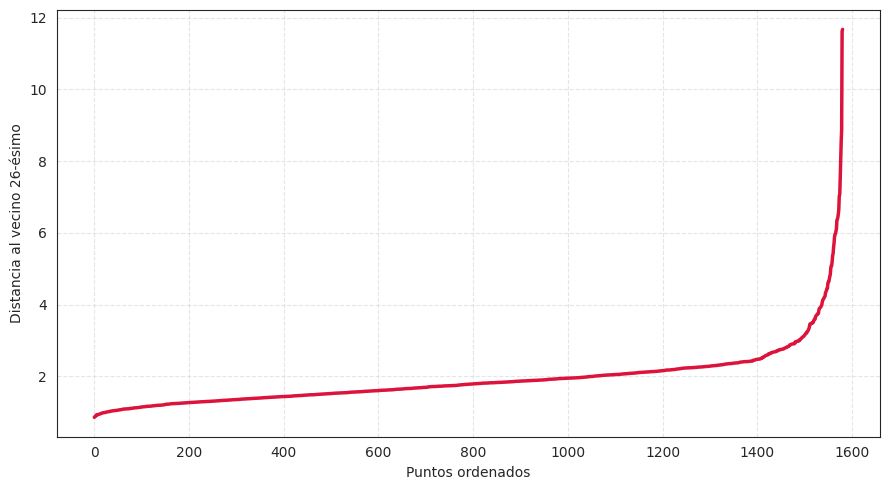

In [86]:
# Graficar el K-Distancia
plt.figure(figsize=(9, 5))
plt.plot(dist_ordenadas_sec, color='crimson', linewidth=2.5)
# plt.title('Gráfico de K-Distancia - DBSCAN SECTORIAL', fontsize=12)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al vecino {min_samples_sec}-ésimo')
plt.grid(True, linestyle='--', alpha=0.5)

ruta_kdist_sec = os.path.join(path_dbscan_sec, 'kdistance_sectorial.png')
plt.tight_layout()
plt.savefig(ruta_kdist_sec, dpi=300)
plt.show()


DBSCAN Sectorial detectó: 1 clústeres densos y 38 puntos de ruido (outliers).


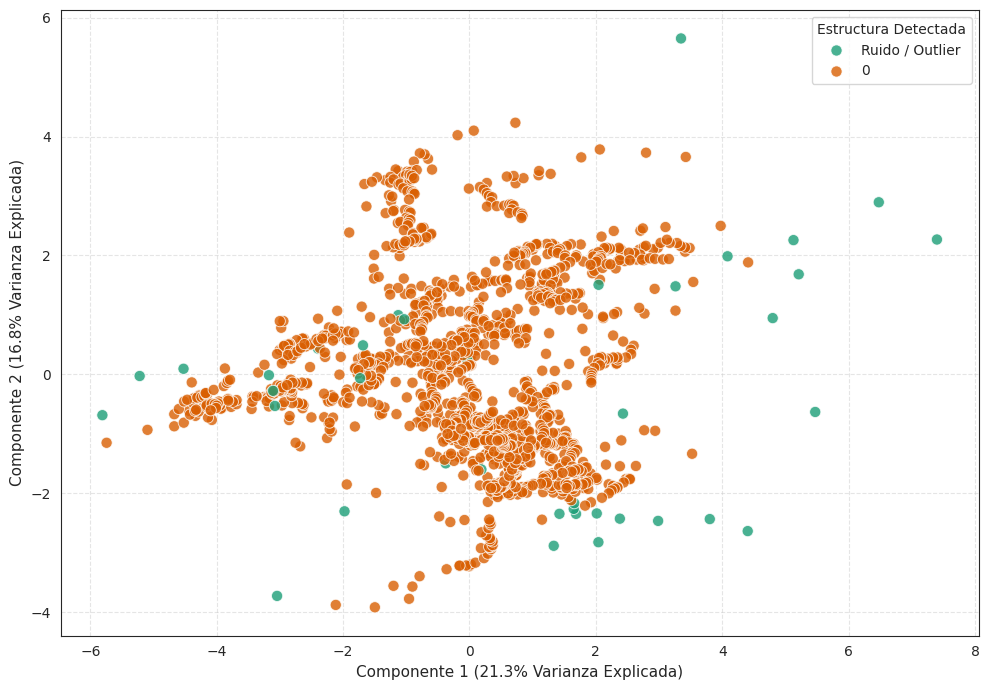

In [87]:
# Configuración
eps_sec_optimo = 3.0

# Entrenar DBSCAN Sectorial
dbscan_sec = DBSCAN(eps=eps_sec_optimo, min_samples=min_samples_sec)
df_input_sec['cluster_dbscan_sectorial'] = dbscan_sec.fit_predict(X_scaled_sec)

# Contamos la cantidad de clústeres reales y el ruido
etiquetas_sec = df_input_sec['cluster_dbscan_sectorial'].unique()
num_clusters_sec = len([x for x in etiquetas_sec if x >= 0])
num_ruido_sec = list(df_input_sec['cluster_dbscan_sectorial']).count(-1)
print(f"\nDBSCAN Sectorial detectó: {num_clusters_sec} clústeres densos y {num_ruido_sec} puntos de ruido (outliers).")

# Reducción a 2 componentes con PCA para visualización
pca_db_sec = PCA(n_components=2, random_state=42)
X_pca_db_sec = pca_db_sec.fit_transform(X_scaled_sec)

df_vis_db_sec = pd.DataFrame(data=X_pca_db_sec, columns=['Componente 1', 'Componente 2'])
df_vis_db_sec['Régimen de Densidad Sectorial'] = df_input_sec['cluster_dbscan_sectorial'].astype(str).replace('-1', 'Ruido / Outlier')

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente 1',
    y='Componente 2',
    hue='Régimen de Densidad Sectorial',
    data=df_vis_db_sec,
    palette='Dark2',
    alpha=0.8,
    edgecolor='w',
    s=65
)

var_exp_db_sec = pca_db_sec.explained_variance_ratio_
plt.xlabel(f'Componente 1 ({var_exp_db_sec[0]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.ylabel(f'Componente 2 ({var_exp_db_sec[1]*100:.1f}% Varianza Explicada)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Estructura Detectada', loc='upper right')

ruta_grafico_spatial_dbscan_sec = os.path.join(path_dbscan_sec, 'dispersion_spatial_dbscan_sectorial.png')
plt.tight_layout()
plt.savefig(ruta_grafico_spatial_dbscan_sec, dpi=300)
plt.show()

Análisis económicos de los clusters

In [88]:
# Caracterización Macroeconómica
df_temp_demanda_var_for_analysis_sec = demanda_var.copy()
if df_temp_demanda_var_for_analysis_sec.index.name == 'fecha':
    df_temp_demanda_var_for_analysis_sec = df_temp_demanda_var_for_analysis_sec.reset_index()

# Eliminar cualquier columna de cluster sectorial antigua para evitar duplicados en el merge
if 'cluster_dbscan_sectorial' in df_temp_demanda_var_for_analysis_sec.columns:
    df_temp_demanda_var_for_analysis_sec = df_temp_demanda_var_for_analysis_sec.drop(columns=['cluster_dbscan_sectorial'])

df_macro_sec = pd.merge(
    df_input_sec[['fecha', 'cluster_dbscan_sectorial']],
    df_temp_demanda_var_for_analysis_sec[['fecha', 'target_emae_ia', 'demanda_total_ia', 'ind_total_ia', 'temp_media_gba_ia']],
    on='fecha',
    how='inner'
)

resumen_sec = df_macro_sec.groupby('cluster_dbscan_sectorial').agg(
    frecuencia=('fecha', 'count'),
    emae_promedio=('target_emae_ia', 'mean'),
    demanda_total_promedio=('demanda_total_ia', 'mean'),
    industria_promedio=('ind_total_ia', 'mean'),
    temperatura_promedio=('temp_media_gba_ia', 'mean')
).reset_index()

resumen_sec['cluster_dbscan_sectorial'] = resumen_sec['cluster_dbscan_sectorial'].astype(str).replace('-1', '-1 (Ruido)')
print("Caracterización Macroeconómica - DBSCAN SECTORIAL:")
display(resumen_sec)

Caracterización Macroeconómica - DBSCAN SECTORIAL:


,cluster_dbscan_sectorial,frecuencia,emae_promedio,demanda_total_promedio,industria_promedio,temperatura_promedio
0,-1 (Ruido),38,3.256694,3.248044,-0.740677,-1.158789
1,0,1543,1.801479,1.803487,-2.617689,1.897665


## Modelos predictivos

In [89]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
!pip install pmdarima
import pmdarima as pm
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
!pip install optuna
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.3 MB/s eta 0:00:00


In [90]:
# Definición de la ruta
path_predictivo = os.path.join(path_resultados_particular, 'Modelo Predictivo')
os.makedirs(path_predictivo, exist_ok=True)

### Creación de Lags

In [91]:
demanda_var = pd.merge(
    demanda_var,
    demanda_var_clusters[['fecha', 'cluster_kmeans_unscaled', 'cluster_dbscan']],
    on='fecha',
    how='left'
)

In [92]:
# Verificar/Ordenar el dataset cronológicamente antes de calcular lags
if 'fecha' not in demanda_var.columns:
    demanda_var = demanda_var.sort_index()
else:
    demanda_var = demanda_var.sort_values('fecha').reset_index(drop=True)

# Selección estricta de variables originales (Evita ruidos si re-corrés la celda)
columnas_excluir = [
    'periodo', 'fecha', 'anio', 'mes', 'dia', 'tipo_dia_texto',
    'es_habil', 'dia_semana_num', 'dia_avance', 'target_emae_ia'
]

# Modificamos el filtro para ignorar lags previos Y promedios móviles previos (_ma)
variables_para_lags = [
    c for c in demanda_var.columns
    if c not in columnas_excluir
    and not c.endswith(('_lag1', '_lag2', '_lag3', '_lag10', '_lag15', '_lag30'))
    and '_lag' not in c
    and '_ma' not in c  # <-- Agregado para ignorar columnas _ma si re-corrés
]

# =========================================================
# 1. Creación de los Lags
# =========================================================
lags_a_calcular = [1, 2, 3, 10, 15, 30]
df_lags_list = []

for lag in lags_a_calcular:
    lags_dict = {col: f"{col}_lag{lag}" for col in variables_para_lags}
    df_lagged = demanda_var[variables_para_lags].shift(lag).rename(columns=lags_dict)
    df_lags_list.append(df_lagged)

df_lags_features = pd.concat(df_lags_list, axis=1)

# =========================================================
# 2. Creación de Promedios Móviles (Rolling Means)
# =========================================================
ventanas_ma = [7, 14] # Podés agregar más si querés (ej: 21, 30)
df_ma_list = []

for ventana in ventanas_ma:
    ma_dict = {col: f"{col}_ma{ventana}" for col in variables_para_lags}
    # Usamos min_periods=1 para que calcule con los días disponibles al inicio
    # y no genere nulos innecesarios antes del día 7
    df_ma = demanda_var[variables_para_lags].rolling(window=ventana, min_periods=1).mean().rename(columns=ma_dict)
    df_ma_list.append(df_ma)

df_ma_features = pd.concat(df_ma_list, axis=1)

# =========================================================
# 3. Ensamblado Final y Limpieza
# =========================================================

# Blindaje para evitar duplicados (Borramos lags Y rolling means viejos)
columnas_viejas = [c for c in demanda_var.columns if '_lag' in c or '_ma' in c]
if columnas_viejas:
    demanda_var = demanda_var.drop(columns=columnas_viejas)

# Unimos las variables originales, los lags Y los promedios móviles al df
demanda_var = pd.concat([demanda_var, df_lags_features, df_ma_features], axis=1)

# Eliminación de nulos (Guiada por el lag máximo, que es el limitante)
lag_maximo = max(lags_a_calcular)
columnas_lag_max_reales = [c for c in demanda_var.columns if c.endswith(f'_lag{lag_maximo}')]

filas_antes = len(demanda_var)
demanda_var = demanda_var.dropna(subset=[columnas_lag_max_reales[0]])

demanda_var = demanda_var.reset_index(drop=True)

filas_despues = len(demanda_var)

# GUARDAR
ruta_guardado_csv = os.path.join(path_predictivo, 'demanda_var_predictivo.csv')
demanda_var.to_csv(ruta_guardado_csv, index=False)

In [93]:
demanda_var

,periodo,fecha,anio,mes,dia,tipo_dia_texto,es_habil,dia_semana_num,dia_avance,ind_aluar_ia,...,reg_prov_ba_ia_ma14,reg_centro_ia_ma14,ind_alimentacion_ia_ma14,ind_automotriz_ia_ma14,ind_petroleo_minerales_total_ia_ma14,reg_cuyo_ia_ma14,demanda_total_ia_ma14,ind_derivados_petroleo_ia_ma14,cluster_kmeans_unscaled_ma14,cluster_dbscan_ma14
0,202201,2022-01-31,2022,1,31,Lunes habiles,1,1,31,-48.580371,...,17.096778,24.505446,-0.535978,-7.112691,-7.675268,16.434943,14.031462,-18.899580,1.0,0.000000
1,202202,2022-02-01,2022,2,1,Martes Habiles,1,2,1,-47.917751,...,17.131107,25.324691,0.899879,-6.550028,-7.259451,17.651772,14.385216,-19.178529,1.0,-0.071429
2,202202,2022-02-02,2022,2,2,Miercoles habiles,1,3,2,-46.298158,...,17.464946,26.201753,2.005767,-5.859364,-6.738128,18.622081,15.187599,-19.513954,1.0,-0.142857
3,202202,2022-02-03,2022,2,3,Jueves Habiles,1,4,3,-44.428022,...,17.743744,26.904741,2.851975,-5.360305,-6.251661,19.381741,15.933893,-19.849352,1.0,-0.214286
4,202202,2022-02-04,2022,2,4,Viernes habiles,1,5,4,-42.892858,...,17.942407,27.182596,3.574332,-4.787939,-5.830662,19.750833,16.479943,-20.195187,1.0,-0.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1546,202604,2026-04-26,2026,4,26,Domingo o Feriado,0,7,26,15.332039,...,5.187977,5.219131,23.435136,7.278916,13.548864,3.335869,8.690814,-3.170920,1.0,0.000000
1547,202604,2026-04-27,2026,4,27,Lunes habiles,1,1,27,16.474612,...,5.137016,5.142682,23.174505,7.221859,13.368060,3.389407,8.523539,-3.131255,1.0,0.000000
1548,202604,2026-04-28,2026,4,28,Martes Habiles,1,2,28,17.614825,...,5.106284,5.082677,22.891759,7.125187,13.128103,3.438584,8.378790,-3.073200,1.0,0.000000
1549,202604,2026-04-29,2026,4,29,Miercoles habiles,1,3,29,18.661606,...,5.117343,5.045810,22.650700,7.049356,12.790013,3.512342,8.263445,-3.030729,1.0,0.000000


### Modelo Lineal Múltiple

In [94]:
# Crea carpeta
path_modelo_lineal = os.path.join(path_resultados_particular, 'Modelo Predictivo', 'Modelo Lineal')
os.makedirs(path_modelo_lineal, exist_ok=True)

Configuración del modelo

In [95]:
# Configuración
meses_test = ['2026-01', '2026-02', '2026-03']
mes_pred = '2026-04'
usar_estandarizacion = True

In [96]:
# Carga y limpieza de datos
ruta_dataset = os.path.join(path_resultados_particular, 'Modelo Predictivo', 'demanda_var_predictivo.csv')
df_modelado = pd.read_csv(ruta_dataset)

if 'fecha' in df_modelado.columns:
    df_modelado['fecha'] = pd.to_datetime(df_modelado['fecha'])
    df_modelado = df_modelado.set_index('fecha')
df_modelado = df_modelado.sort_index()

Modelado

In [97]:
# Separacion de matriz de features y target
target_col = 'target_emae_ia'
columnas_no_predictoras = ['periodo', 'anio', 'mes', 'dia', 'tipo_dia_texto', 'es_habil', 'dia_semana_num', 'dia_avance', target_col]

X_completo = df_modelado.drop(columns=[c for c in columnas_no_predictoras if c in df_modelado.columns])
X_completo = X_completo.ffill().bfill()
y_completo = df_modelado[target_col]

# Aplicacion de la estandarización
paso_scaler = StandardScaler() if usar_estandarizacion else 'passthrough'

pipe_ridge = Pipeline([
    ('scaler', paso_scaler),
    ('ridge', Ridge(random_state=42))
])

# Grilla de búsqueda
param_grid = {'ridge__alpha': np.logspace(-3, 4, 20)}
tscv_interno = TimeSeriesSplit(n_splits=3)

# Variables para guardar resultados
reales_mensuales = []
preds_mensuales = []

Entrenamiento, validación y resultados

In [98]:
# Bucle de validacion Walk-Forward
print(f"Validación por ventanas:")

for mes in meses_test:
    # Corte de datos: entrenamiento hasta el primer día del mes, testeo en el mes exacto
    X_train = X_completo[X_completo.index < f"{mes}-01"]
    y_train = y_completo[y_completo.index < f"{mes}-01"]

    X_test = X_completo[X_completo.index.strftime('%Y-%m') == mes]
    y_test = y_completo[y_completo.index.strftime('%Y-%m') == mes]

    # Optimización y ajuste
    grid = GridSearchCV(pipe_ridge, param_grid, cv=tscv_interno, scoring='neg_root_mean_squared_error', n_jobs=-1)
    grid.fit(X_train, y_train)

    # Predicción
    preds_diarias = grid.predict(X_test)

    # Agrupación mensual
    real_mes = y_test.mean()
    pred_mes = preds_diarias.mean()

    reales_mensuales.append(real_mes)
    preds_mensuales.append(pred_mes)

    mejor_alpha = grid.best_params_['ridge__alpha']
    print(f"Mes: {mes} | Real: {real_mes:5.2f}% | Pred: {pred_mes:5.2f}% | Alpha óptimo: {mejor_alpha:.2f}")

# Cálculo del error global de la validación
rmse_global = root_mean_squared_error(reales_mensuales, preds_mensuales)
mape_global = mean_absolute_percentage_error(reales_mensuales, preds_mensuales)

print("\nMetricas globales del período evaluado:")
print(f"RMSE: {rmse_global:.4f}")
print(f"MAPE: {mape_global*100:.2f}%\n")

# Prediccion futura
print(f"Proyección para el nuevo mes de {mes_pred}:")

X_train_final = X_completo[X_completo.index < f"{mes_pred}-01"]
y_train_final = y_completo[y_completo.index < f"{mes_pred}-01"]
X_test_final = X_completo[X_completo.index.strftime('%Y-%m') == mes_pred]

if X_test_final.empty:
    print(f"No hay datos exogenos disponibles para {mes_pred} en el dataset.")
else:
    grid_final = GridSearchCV(pipe_ridge, param_grid, cv=tscv_interno, scoring='neg_root_mean_squared_error', n_jobs=-1)
    grid_final.fit(X_train_final, y_train_final)

    preds_ciegas = grid_final.predict(X_test_final)
    pred_ciega_mensual = preds_ciegas.mean()

    print(f"{pred_ciega_mensual:.2f}%")

Validación por ventanas:
Mes: 2026-01 | Real:  1.54% | Pred:  2.96% | Alpha óptimo: 4281.33
Mes: 2026-02 | Real: -2.03% | Pred:  4.10% | Alpha óptimo: 4281.33
Mes: 2026-03 | Real:  5.48% | Pred:  4.38% | Alpha óptimo: 10000.00

Metricas globales del período evaluado:
RMSE: 3.6854
MAPE: 138.22%

Proyección para el nuevo mes de 2026-04:
4.60%


Importancia de variables

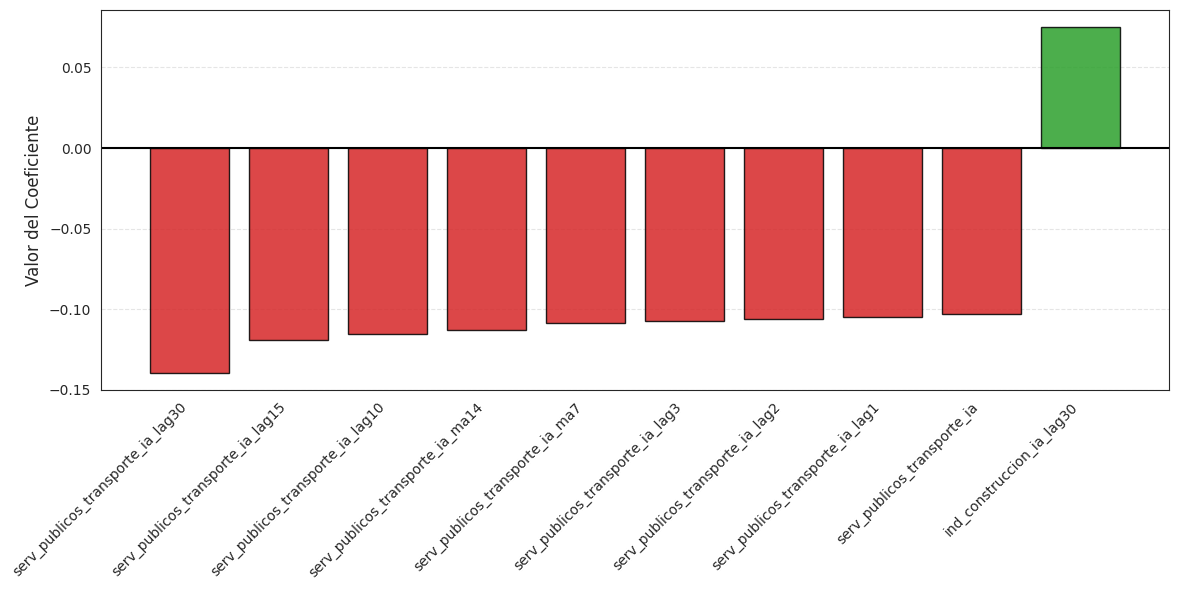

In [99]:
# Extraemos el mejor modelo del Pipeline
mejor_pipeline = grid_final.best_estimator_
modelo_ridge = mejor_pipeline.named_steps['ridge']

# Extraemos los coeficientes exactos
coeficientes = modelo_ridge.coef_
nombres_variables = X_train_final.columns

# 3. Armamos un DataFrame para ordenar y analizar
df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': abs(coeficientes)
})

# Filtramos el Top 10 ordenando por la fuerza de impacto
top_10 = df_importancia.sort_values(by='Importancia_Absoluta', ascending=False).head(10)

# VISUALIZACIÓN
plt.figure(figsize=(12, 6))

# Definimos los colores basados en el signo real del coeficiente
colores = ['#2ca02c' if c > 0 else '#d62728' for c in top_10['Coeficiente']]
plt.bar(top_10['Variable'], top_10['Coeficiente'], color=colores, edgecolor='black', alpha=0.85)
# plt.title('Top 10 Variables de Mayor Impacto en el EMAE - Regresión Ridge', fontsize=14, pad=15)
plt.ylabel('Valor del Coeficiente', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)

# Rotamos las etiquetas del Eje X a 45 grados para que sean legibles
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Guardar
ruta_grafico_importancia = os.path.join(path_modelo_lineal, 'importancia_variables_ridge.png')
plt.savefig(ruta_grafico_importancia, dpi=300)

plt.show()

### SARIMAX

In [100]:
# Crea carpeta
path_modelo_sarimax = os.path.join(path_resultados_particular, 'Modelo Predictivo', 'Modelo SARIMAX')
os.makedirs(path_modelo_sarimax, exist_ok=True)

Configuración

In [101]:
# Configuración
meses_test = ['2026-01', '2026-02', '2026-03']
mes_pred = '2026-04'

# Como SARIMAX no soporta alta dimensionalidad, se seleccionan variables que se crean más relevantes
variables_top_ridge = [
    'demanda_total_ia',
    'serv_publicos_transporte_ia',
    'ind_construccion_ia',
    'temp_media_gba_ia',
    'ind_total_ia'
]

In [102]:
# Carga y limpieza de datos
ruta_dataset = os.path.join(path_resultados_particular, 'Modelo Predictivo', 'demanda_var_predictivo.csv')
df_modelado = pd.read_csv(ruta_dataset)

if 'fecha' in df_modelado.columns:
    df_modelado['fecha'] = pd.to_datetime(df_modelado['fecha'])
    df_modelado = df_modelado.set_index('fecha')
df_modelado = df_modelado.sort_index()

Modelado

In [103]:
target_col = 'target_emae_ia'

# Filtramos la matriz X solo con las variables seleccionadas para evitar el colapso del MLE
X_sarimax = df_modelado[variables_top_ridge].ffill().bfill()
y_completo = df_modelado[target_col]

reales_mensuales = []
preds_mensuales = []

print(f"Validación por ventanas (Modelo SARIMAX):")

for mes in meses_test:
    # 1. Corte temporal
    X_train = X_sarimax[X_sarimax.index < f"{mes}-01"]
    y_train = y_completo[y_completo.index < f"{mes}-01"]

    X_test = X_sarimax[X_sarimax.index.strftime('%Y-%m') == mes]
    y_test = y_completo[y_completo.index.strftime('%Y-%m') == mes]

    print(f"• Optimizando hiperparámetros para {mes}")

    # 2. Optimización y ajuste (Equivalente al GridSearchCV)
    # m=7 asume estacionalidad semanal en los datos diarios de energía
    modelo_auto = pm.auto_arima(
        y_train,
        X=X_train,
        seasonal=True,
        m=7,                      # Estacionalidad semanal estricta (Lunes con Lunes)
        d=0, D=0,                 # Forzamos no diferenciar porque es var. interanual
        information_criterion='bic', # Castiga fuerte el sobreajuste
        stepwise=True,
        suppress_warnings=True,
        max_p=5, max_q=5,         # Le damos un poco más de margen de memoria diaria
        max_P=2, max_Q=2,         # Margen para la memoria estacional
        trace=False
    )

    # 3. Predicción (Exige indicarle cuántos pasos hacia el futuro y pasarle las exógenas de esos días)
    preds_diarias = modelo_auto.predict(n_periods=len(y_test), X=X_test)

    # 4. Agrupación mensual
    real_mes = y_test.mean()
    pred_mes = preds_diarias.mean()

    reales_mensuales.append(real_mes)
    preds_mensuales.append(pred_mes)

    mejor_orden = modelo_auto.order
    mejor_estacional = modelo_auto.seasonal_order
    print(f"Real: {real_mes:5.2f}% | Pred: {pred_mes:5.2f}% | ARIMA: {mejor_orden} Estacional: {mejor_estacional}")

# Cálculo del error global
rmse_global = root_mean_squared_error(reales_mensuales, preds_mensuales)
mape_global = mean_absolute_percentage_error(reales_mensuales, preds_mensuales)

print("\nMétricas globales del período evaluado (SARIMAX):")
print(f"RMSE: {rmse_global:.4f}")
print(f"MAPE: {mape_global*100:.2f}%\n")

# Predicción futura
print(f"Proyección para el nuevo mes de {mes_pred}:")

X_train_final = X_sarimax[X_sarimax.index < f"{mes_pred}-01"]
y_train_final = y_completo[y_completo.index < f"{mes_pred}-01"]
X_test_final = X_sarimax[X_sarimax.index.strftime('%Y-%m') == mes_pred]

if X_test_final.empty:
    print(f"No hay datos exógenos disponibles para {mes_pred} en el dataset.")
else:
    print(f"Reentrenando modelo final con toda la historia...")
    modelo_final = pm.auto_arima(
        y_train_final, X=X_train_final,
        seasonal=True, m=7,
        stepwise=True, suppress_warnings=True
    )

    preds_ciegas = modelo_final.predict(n_periods=len(X_test_final), X=X_test_final)
    pred_ciega_mensual = preds_ciegas.mean()

    print(f"Proyección SARIMAX para {mes_pred}: {pred_ciega_mensual:.2f}%")

Validación por ventanas (Modelo SARIMAX):
• Optimizando hiperparámetros para 2026-01
Real:  1.54% | Pred:  2.06% | ARIMA: (1, 0, 1) Estacional: (0, 0, 0, 7)
• Optimizando hiperparámetros para 2026-02
Real: -2.03% | Pred:  1.28% | ARIMA: (1, 0, 1) Estacional: (0, 0, 0, 7)
• Optimizando hiperparámetros para 2026-03
Real:  5.48% | Pred: -2.33% | ARIMA: (1, 0, 1) Estacional: (0, 0, 0, 7)

Métricas globales del período evaluado (SARIMAX):
RMSE: 4.9051
MAPE: 113.06%

Proyección para el nuevo mes de 2026-04:
Reentrenando modelo final con toda la historia...
Proyección SARIMAX para 2026-04: 6.44%


Importancia de variables

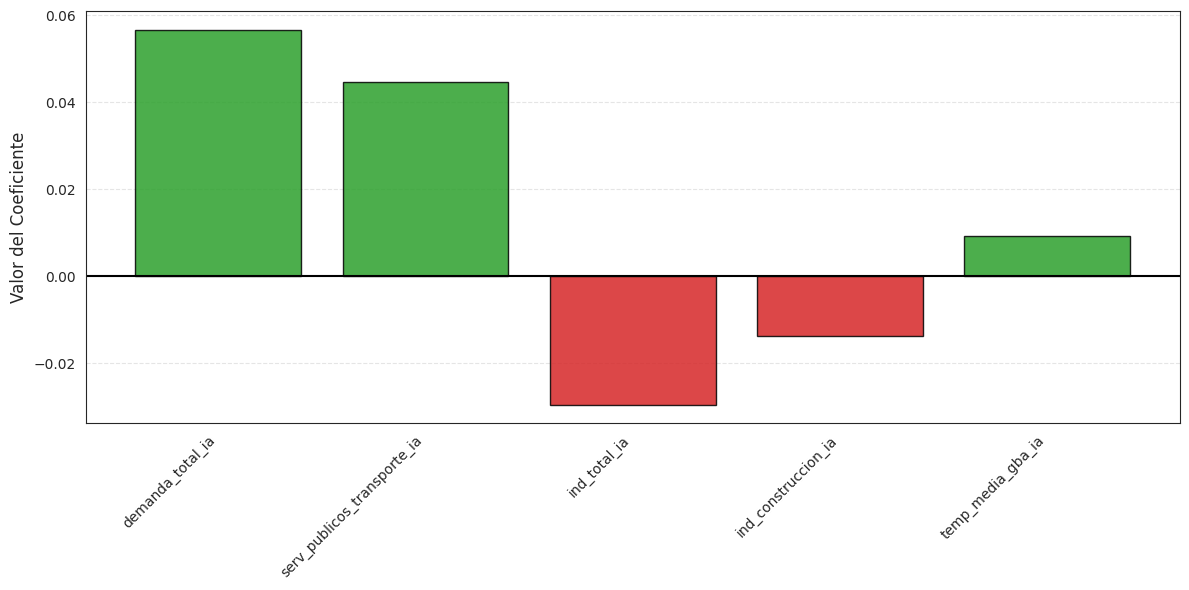

In [104]:
# Extraemos TODOS los coeficientes (incluye AR, MA, sigma2 y variables exógenas)
coeficientes_totales = modelo_final.params()

# Filtramos para quedarnos SOLO con los coeficientes de las variables exógenas
nombres_exogenas = X_train_final.columns
coefs_exogenas = []
nombres_filtrados = []

for col in nombres_exogenas:
    if col in coeficientes_totales.index:
        coefs_exogenas.append(coeficientes_totales[col])
        nombres_filtrados.append(col)

# Armamos un DataFrame para ordenar y analizar
df_importancia_sari = pd.DataFrame({
    'Variable': nombres_filtrados,
    'Coeficiente': coefs_exogenas,
    'Importancia_Absoluta': [abs(c) for c in coefs_exogenas]
})

# Filtramos el Top 10 ordenando por la fuerza de impacto
top_10_sari = df_importancia_sari.sort_values(by='Importancia_Absoluta', ascending=False).head(10)

# Visualización
plt.figure(figsize=(12, 6))


colores_sari = ['#2ca02c' if c > 0 else '#d62728' for c in top_10_sari['Coeficiente']]
plt.bar(top_10_sari['Variable'], top_10_sari['Coeficiente'], color=colores_sari, edgecolor='black', alpha=0.85)
# Títulos y ejes
# plt.title('Impacto de Variables Exógenas en el EMAE - SARIMAX', fontsize=14, pad=15)
plt.ylabel('Valor del Coeficiente', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Guardar
ruta_grafico_sari = os.path.join(path_modelo_sarimax, 'importancia_variables_sarimax.png')
plt.savefig(ruta_grafico_sari, dpi=300)

plt.show()

### Random Forest

In [105]:
# Crea carpeta
path_modelo_rf = os.path.join(path_resultados_particular, 'Modelo Predictivo', 'Modelo Random Forest')
os.makedirs(path_modelo_rf, exist_ok=True)

Configuración

In [106]:
# Configuración
meses_test = ['2026-01', '2026-02', '2026-03']
mes_pred = '2026-04'

usar_pesos_avance = True

# Semillas
# Para la optimización de hiperparámetros
semillas_opt = [1009
                #, 2003, 3001, 4001, 5003
                ]
# Para el entrenamiento y ensamble final
semillas_train = [1009, 2003, 3001, 4001, 5003]


# Carga y limpieza del dataset
ruta_dataset = os.path.join(path_resultados_particular, 'Modelo Predictivo', 'demanda_var_predictivo.csv')
df_modelado = pd.read_csv(ruta_dataset)

if 'fecha' in df_modelado.columns:
    df_modelado['fecha'] = pd.to_datetime(df_modelado['fecha'])
    df_modelado = df_modelado.set_index('fecha')

df_modelado = df_modelado.sort_index()

# Separación de Features y Target
target_col = 'target_emae_ia'
columnas_no_predictoras = ['periodo', 'anio', 'mes', 'dia', 'tipo_dia_texto', 'es_habil', 'dia_semana_num', target_col]

X_completo_raw = df_modelado.drop(columns=[c for c in columnas_no_predictoras if c in df_modelado.columns])
X_completo_raw = X_completo_raw.ffill().bfill()
y_completo = df_modelado[target_col]

# Extracción de la variable de maduración y limpieza final
pesos_completos = X_completo_raw['dia_avance'].values
X_completo = X_completo_raw.drop(columns=['dia_avance'])

# Grilla de hiperparámetros y TSCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 8, 10, 15, 20, 25, None],
    'min_samples_leaf': [2, 5, 10, 50, 100],
    'max_features': ['sqrt', 'log2']
}

tscv_interno = TimeSeriesSplit(n_splits=3)

reales_mensuales = []
preds_mensuales = []

Optimización

In [107]:

# Bucle walk-forward
print(f"Iniciando Optimización del modelo Random Forest")
print(f"• Semillas Optimización: {len(semillas_opt)} | Semillas Ensamble: {len(semillas_train)}\n")

for mes in meses_test:
    # 1. Cortes de datos para el mes
    mask_train = X_completo.index < f"{mes}-01"
    mask_test = X_completo.index.strftime('%Y-%m') == mes

    X_train, y_train = X_completo[mask_train], y_completo[mask_train]
    X_test, y_test = X_completo[mask_test], y_completo[mask_test]

    w_train = pesos_completos[mask_train] if usar_pesos_avance else None
    w_test = pesos_completos[mask_test] if usar_pesos_avance else None
    fit_params = {'sample_weight': w_train} if usar_pesos_avance else {}

    # Fase de optimización (Multi-Seed opcional)
    print(f"• Optimizando hiperparámetros para {mes}...")
    mejor_score_cv = float('inf')
    mejores_params_global = None

    for seed_opt in semillas_opt:
        rf_base = RandomForestRegressor(random_state=seed_opt, n_jobs=-1)
        grid = GridSearchCV(rf_base, param_grid, cv=tscv_interno, scoring='neg_root_mean_squared_error', n_jobs=-1)
        grid.fit(X_train, y_train, **fit_params)

        score_actual = abs(grid.best_score_)

        if score_actual < mejor_score_cv:
            mejor_score_cv = score_actual
            mejores_params_global = grid.best_params_


    # Entrenamiento y ensamble
    preds_diarias_semillas = []

    for seed_train in semillas_train:
        # Entrenamos con los parámetros ganadores, iterando las semillas de estabilización
        rf_semilla = RandomForestRegressor(**mejores_params_global, random_state=seed_train, n_jobs=-1)
        rf_semilla.fit(X_train, y_train, **fit_params)
        preds_diarias_semillas.append(rf_semilla.predict(X_test))

    # Consolidación de la predicción
    preds_diarias_ensamble = np.mean(preds_diarias_semillas, axis=0)
    real_mes = y_test.mean()
    pred_mes = np.average(preds_diarias_ensamble, weights=w_test) if usar_pesos_avance else preds_diarias_ensamble.mean()

    reales_mensuales.append(real_mes)
    preds_mensuales.append(pred_mes)

    print(f"Real: {real_mes:5.2f}% | Pred Promediada: {pred_mes:5.2f}%")
    print(f"Params ganadores (Score CV: {mejor_score_cv:.4f}): {mejores_params_global}\n")

# Error global
rmse_global = root_mean_squared_error(reales_mensuales, preds_mensuales)
mape_global = mean_absolute_percentage_error(reales_mensuales, preds_mensuales)

print("Métricas globales del período evaluado:")
print(f"RMSE: {rmse_global:.4f}")
print(f"MAPE: {mape_global*100:.2f}%\n")

# Predicción futura
print(f"Generando proyección para el mes {mes_pred}...")

mask_train_final = X_completo.index < f"{mes_pred}-01"
mask_test_final = X_completo.index.strftime('%Y-%m') == mes_pred

X_train_final, y_train_final = X_completo[mask_train_final], y_completo[mask_train_final]
X_test_final = X_completo[mask_test_final]

w_train_final = pesos_completos[mask_train_final] if usar_pesos_avance else None
w_test_final = pesos_completos[mask_test_final] if usar_pesos_avance else None
fit_params_final = {'sample_weight': w_train_final} if usar_pesos_avance else {}

if X_test_final.empty:
    print(f"No hay datos exógenos disponibles para {mes_pred} en el dataset.")
else:
    mejor_score_cv_final = float('inf')
    mejores_params_global_final = None

    for seed_opt in semillas_opt:
        rf_base_final = RandomForestRegressor(random_state=seed_opt, n_jobs=-1)
        grid_final = GridSearchCV(rf_base_final, param_grid, cv=tscv_interno, scoring='neg_root_mean_squared_error', n_jobs=-1)
        grid_final.fit(X_train_final, y_train_final, **fit_params_final)

        score_actual = abs(grid_final.best_score_)
        if score_actual < mejor_score_cv_final:
            mejor_score_cv_final = score_actual
            mejores_params_global_final = grid_final.best_params_

    preds_ciegas_semillas = []

    for seed_train in semillas_train:
        rf_final_semilla = RandomForestRegressor(**mejores_params_global_final, random_state=seed_train, n_jobs=-1)
        rf_final_semilla.fit(X_train_final, y_train_final, **fit_params_final)
        preds_ciegas_semillas.append(rf_final_semilla.predict(X_test_final))

    preds_ciegas_ensamble = np.mean(preds_ciegas_semillas, axis=0)
    pred_ciega_mensual = np.average(preds_ciegas_ensamble, weights=w_test_final) if usar_pesos_avance else preds_ciegas_ensamble.mean()

    print(f"{pred_ciega_mensual:.2f}%")

Iniciando Optimización del modelo Random Forest
• Semillas Optimización: 1 | Semillas Ensamble: 5

• Optimizando hiperparámetros para 2026-01...
Real:  1.54% | Pred Promediada:  2.05%
Params ganadores (Score CV: 4.9658): {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}

• Optimizando hiperparámetros para 2026-02...
Real: -2.03% | Pred Promediada: -0.17%
Params ganadores (Score CV: 4.8121): {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 50, 'n_estimators': 50}

• Optimizando hiperparámetros para 2026-03...
Real:  5.48% | Pred Promediada:  4.18%
Params ganadores (Score CV: 4.7476): {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 5, 'n_estimators': 50}

Métricas globales del período evaluado:
RMSE: 1.3378
MAPE: 49.31%

Generando proyección para el mes 2026-04...
4.61%


Importancia de variables

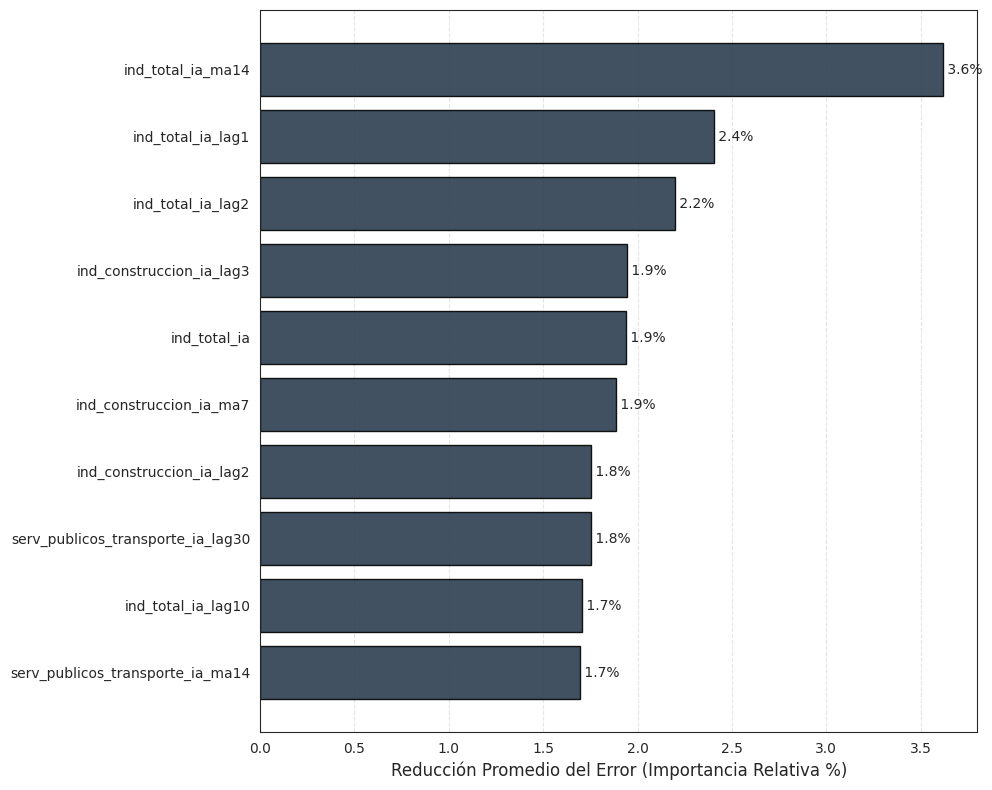

In [108]:
# Matriz para guardar las importancias de cada bosque
importancias_por_semilla = []

# Extraemos las importancias de las 5 semillas finales
for seed_train in semillas_train:
    # Usamos los hiperparámetros ganadores de la optimización final
    rf_importancia = RandomForestRegressor(**mejores_params_global_final, random_state=seed_train, n_jobs=-1)
    rf_importancia.fit(X_train_final, y_train_final, **fit_params_final)

    # Guardamos el vector de importancia de este bosque
    importancias_por_semilla.append(rf_importancia.feature_importances_)

# Calculamos la esperanza matemática (promedio) de la importancia
importancia_promedio = np.mean(importancias_por_semilla, axis=0)
nombres_variables = X_train_final.columns

# Consolidamos en un DataFrame
df_importancia_rf = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia_Promedio': importancia_promedio
}).sort_values(by='Importancia_Promedio', ascending=False)

# Convertir a porcentaje
df_importancia_rf['Importancia_Porcentual'] = (df_importancia_rf['Importancia_Promedio'] / df_importancia_rf['Importancia_Promedio'].sum()) * 100

# Aislamos el Top 10 para visualizar
top_10_rf = df_importancia_rf.head(10).sort_values(by='Importancia_Porcentual', ascending=True)

# Visualización
plt.figure(figsize=(10, 8))

# Gráfico de barras horizontales
plt.barh(top_10_rf['Variable'], top_10_rf['Importancia_Porcentual'], color='#2c3e50', edgecolor='black', alpha=0.9)
# plt.title('Top 10 Variables Más Importantes (Impureza Gini)\nEnsamble Random Forest Multi-Seed', fontsize=14, pad=15)
plt.xlabel('Reducción Promedio del Error (Importancia Relativa %)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
for index, value in enumerate(top_10_rf['Importancia_Porcentual']):
    plt.text(value, index, f' {value:.1f}%', va='center', fontsize=10)

plt.tight_layout()

# Guardar
ruta_grafico_rf_ensamble = os.path.join(path_modelo_rf, 'importancia_rf_multiseed.png')
plt.savefig(ruta_grafico_rf_ensamble, dpi=300)

plt.show()

### LightGBM

In [109]:
# Crea carpeta
path_modelo_lightgbm = os.path.join(path_resultados_particular, 'Modelo Predictivo', 'LightGBM')
os.makedirs(path_modelo_lightgbm, exist_ok=True)

Configuración

In [110]:
# Silenciamos los logs de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configuración
meses_test = ['2026-01', '2026-02', '2026-03']
mes_pred = '2026-04'

usar_pesos_avance = True

# Semillas
semillas_opt = [1009
                #, 2003, 3001, 4001, 5003
                ]
semillas_train = [1009, 2003, 3001, 4001, 5003]

n_trials_optuna = 30 # Cantidad de combinaciones inteligentes que probará por ventana

# Carga y limpieza del dataset
ruta_dataset = os.path.join(path_resultados_particular, 'Modelo Predictivo', 'demanda_var_predictivo.csv')
df_modelado = pd.read_csv(ruta_dataset)

if 'fecha' in df_modelado.columns:
    df_modelado['fecha'] = pd.to_datetime(df_modelado['fecha'])
    df_modelado = df_modelado.set_index('fecha')

df_modelado = df_modelado.sort_index()

# Separación de Features y Target
target_col = 'target_emae_ia'
columnas_no_predictoras = ['periodo', 'anio', 'mes', 'dia', 'tipo_dia_texto', 'es_habil', 'dia_semana_num', target_col]

X_completo_raw = df_modelado.drop(columns=[c for c in columnas_no_predictoras if c in df_modelado.columns])
X_completo_raw = X_completo_raw.ffill().bfill()

X_completo_raw = X_completo_raw.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

y_completo = df_modelado[target_col]

pesos_completos = X_completo_raw['dia_avance'].values
X_completo = X_completo_raw.drop(columns=['dia_avance'])

tscv_interno = TimeSeriesSplit(n_splits=3)

reales_mensuales = []
preds_mensuales = []

Optimización y entrenamiento

In [111]:
print(f"Optimización del modelo LightGBM (Bayesiana)")
print(f"Semillas Optimización: {len(semillas_opt)} | Semillas Ensamble: {len(semillas_train)}\n")

for mes in meses_test:
    mask_train = X_completo.index < f"{mes}-01"
    mask_test = X_completo.index.strftime('%Y-%m') == mes

    X_train, y_train = X_completo[mask_train], y_completo[mask_train]
    X_test, y_test = X_completo[mask_test], y_completo[mask_test]

    w_train = pesos_completos[mask_train] if usar_pesos_avance else None
    w_test = pesos_completos[mask_test] if usar_pesos_avance else None

    # Fase de optimización
    print(f"• Optimizando hiperparámetros para {mes}...")
    mejor_score_cv = float('inf')
    mejores_params_global = None

    for seed_opt in semillas_opt:

        # Definimos la función objetivo que Optuna intentará minimizar
        def objective(trial):
            # Espacio de búsqueda Bayesiano para LightGBM
            param_lgbm = {
                'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 300]),
                'learning_rate': trial.suggest_float('learning_rate', 0.0001, 0.1, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 10, 100),
                'max_depth': trial.suggest_int('max_depth', 5, 30),
                'min_child_samples': trial.suggest_int('min_child_samples', 2, 200),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'random_state': seed_opt,
                'n_jobs': -1,
                'verbose': -1
            }

            # Validación cruzada interna
            cv_scores = []
            for train_idx, val_idx in tscv_interno.split(X_train):
                X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

                # Rescatamos los pesos para este fold específico
                w_tr = w_train[train_idx] if usar_pesos_avance else None

                modelo = LGBMRegressor(**param_lgbm)
                modelo.fit(X_tr, y_tr, sample_weight=w_tr)

                preds_va = modelo.predict(X_va)
                cv_scores.append(root_mean_squared_error(y_va, preds_va))

            return np.mean(cv_scores)

        # Creamos el "Estudio" de Optuna y le pasamos la semilla
        sampler = optuna.samplers.TPESampler(seed=seed_opt)
        study = optuna.create_study(direction='minimize', sampler=sampler)
        study.optimize(objective, n_trials=n_trials_optuna)

        # Chequeamos si esta semilla encontró mejores parámetros que las anteriores
        if study.best_value < mejor_score_cv:
            mejor_score_cv = study.best_value
            mejores_params_global = study.best_params

    # Fase de Entrenamiento y Ensamble
    preds_diarias_semillas = []

    # Preparamos el diccionario de fit
    fit_params = {'sample_weight': w_train} if usar_pesos_avance else {}

    for seed_train in semillas_train:
        # Instanciamos con los parámetros ganadores, pero inyectamos la semilla del ensamble
        lgbm_semilla = LGBMRegressor(**mejores_params_global, random_state=seed_train, n_jobs=-1, verbose=-1)
        lgbm_semilla.fit(X_train, y_train, **fit_params)
        preds_diarias_semillas.append(lgbm_semilla.predict(X_test))

    preds_diarias_ensamble = np.mean(preds_diarias_semillas, axis=0)
    real_mes = y_test.mean()
    pred_mes = np.average(preds_diarias_ensamble, weights=w_test) if usar_pesos_avance else preds_diarias_ensamble.mean()

    reales_mensuales.append(real_mes)
    preds_mensuales.append(pred_mes)

    print(f"Real: {real_mes:5.2f}% | Pred Promediada: {pred_mes:5.2f}%")

    # Formateamos los parámetros
    params_limpios = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in mejores_params_global.items()}
    print(f"Params ganadores (Score CV: {mejor_score_cv:.4f}): {params_limpios}\n")

# Cálculo de Error global
rmse_global = root_mean_squared_error(reales_mensuales, preds_mensuales)
mape_global = mean_absolute_percentage_error(reales_mensuales, preds_mensuales)

print("Métricas globales del período evaluado:")
print(f"RMSE: {rmse_global:.4f}")
print(f"MAPE: {mape_global*100:.2f}%\n")


Optimización del modelo LightGBM (Bayesiana)
Semillas Optimización: 1 | Semillas Ensamble: 5

• Optimizando hiperparámetros para 2026-01...
Real:  1.54% | Pred Promediada:  3.49%
Params ganadores (Score CV: 4.8488): {'n_estimators': 300, 'learning_rate': 0.0455, 'num_leaves': 93, 'max_depth': 20, 'min_child_samples': 105, 'colsample_bytree': 0.5629}

• Optimizando hiperparámetros para 2026-02...
Real: -2.03% | Pred Promediada: -0.67%
Params ganadores (Score CV: 4.9568): {'n_estimators': 200, 'learning_rate': 0.0508, 'num_leaves': 24, 'max_depth': 26, 'min_child_samples': 51, 'colsample_bytree': 0.6466}

• Optimizando hiperparámetros para 2026-03...
Real:  5.48% | Pred Promediada:  4.25%
Params ganadores (Score CV: 4.8669): {'n_estimators': 200, 'learning_rate': 0.0407, 'num_leaves': 41, 'max_depth': 22, 'min_child_samples': 60, 'colsample_bytree': 0.691}

Métricas globales del período evaluado:
RMSE: 1.5412
MAPE: 71.81%



In [112]:
# Predicción del futuro
print(f"Generando proyección para el mes {mes_pred}...")

mask_train_final = X_completo.index < f"{mes_pred}-01"
mask_test_final = X_completo.index.strftime('%Y-%m') == mes_pred

X_train_final, y_train_final = X_completo[mask_train_final], y_completo[mask_train_final]
X_test_final = X_completo[mask_test_final]

w_train_final = pesos_completos[mask_train_final] if usar_pesos_avance else None
w_test_final = pesos_completos[mask_test_final] if usar_pesos_avance else None
fit_params_final = {'sample_weight': w_train_final} if usar_pesos_avance else {}

if X_test_final.empty:
    print(f"No hay datos exógenos disponibles para {mes_pred} en el dataset.")
else:
    mejor_score_cv_final = float('inf')
    mejores_params_global_final = None

    for seed_opt in semillas_opt:
        def objective_final(trial):
            param_lgbm = {
                'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 300]),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 10, 50),
                'max_depth': trial.suggest_int('max_depth', 5, 20),
                'min_child_samples': trial.suggest_int('min_child_samples', 2, 20),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'random_state': seed_opt,
                'n_jobs': -1,
                'verbose': -1
            }

            cv_scores = []
            for train_idx, val_idx in tscv_interno.split(X_train_final):
                X_tr, X_va = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
                y_tr, y_va = y_train_final.iloc[train_idx], y_train_final.iloc[val_idx]
                w_tr = w_train_final[train_idx] if usar_pesos_avance else None

                modelo = LGBMRegressor(**param_lgbm)
                modelo.fit(X_tr, y_tr, sample_weight=w_tr)
                preds_va = modelo.predict(X_va)
                cv_scores.append(root_mean_squared_error(y_va, preds_va))

            return np.mean(cv_scores)

        sampler_final = optuna.samplers.TPESampler(seed=seed_opt)
        study_final = optuna.create_study(direction='minimize', sampler=sampler_final)
        study_final.optimize(objective_final, n_trials=n_trials_optuna)

        if study_final.best_value < mejor_score_cv_final:
            mejor_score_cv_final = study_final.best_value
            mejores_params_global_final = study_final.best_params

    preds_ciegas_semillas = []

    for seed_train in semillas_train:
        lgbm_final_semilla = LGBMRegressor(**mejores_params_global_final, random_state=seed_train, n_jobs=-1, verbose=-1)
        lgbm_final_semilla.fit(X_train_final, y_train_final, **fit_params_final)
        preds_ciegas_semillas.append(lgbm_final_semilla.predict(X_test_final))

    preds_ciegas_ensamble = np.mean(preds_ciegas_semillas, axis=0)
    pred_ciega_mensual = np.average(preds_ciegas_ensamble, weights=w_test_final) if usar_pesos_avance else preds_ciegas_ensamble.mean()

    print(f"{pred_ciega_mensual:.2f}%")

Generando proyección para el mes 2026-04...
5.63%


Importancia de variables

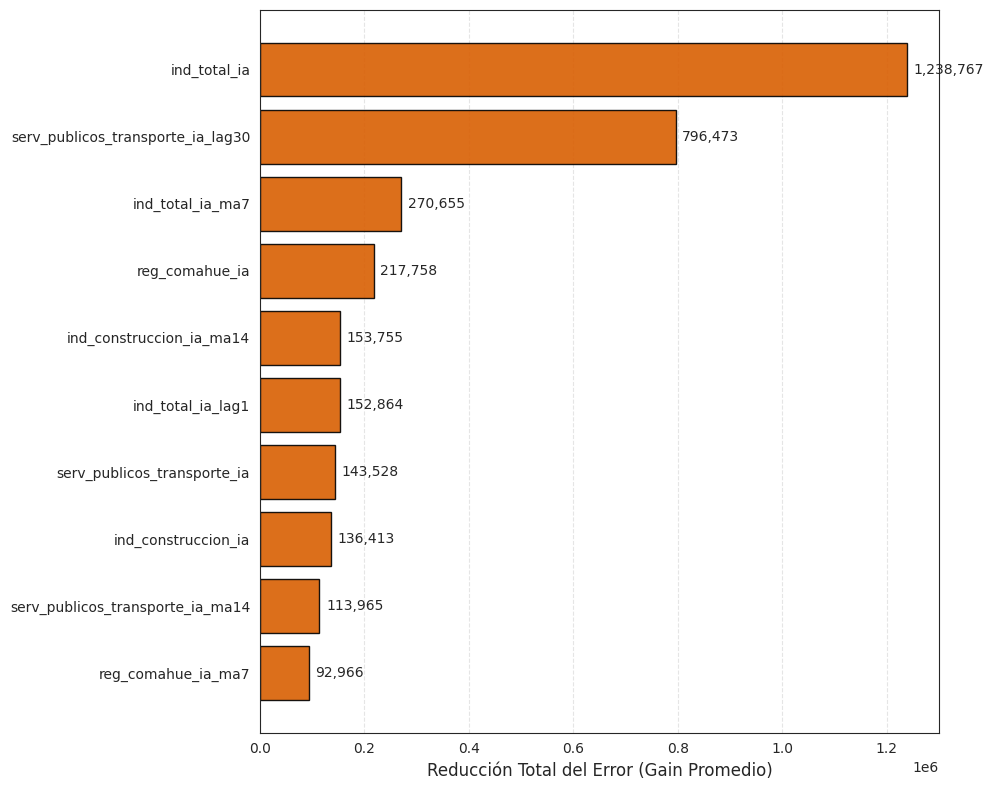

In [113]:
# Matriz para guardar las importancias
importancias_por_semilla = []

# Forzamos el cálculo por 'gain' (Ganancia de Información)
params_importancia = mejores_params_global_final.copy()
params_importancia['importance_type'] = 'gain'

# Extraemos las importancias de las 5 semillas
for seed_train in semillas_train:
    lgbm_importancia = LGBMRegressor(**params_importancia, random_state=seed_train, n_jobs=-1, verbose=-1)
    lgbm_importancia.fit(X_train_final, y_train_final, **fit_params_final)

    importancias_por_semilla.append(lgbm_importancia.feature_importances_)

# Promedio del ensamble
importancia_promedio = np.mean(importancias_por_semilla, axis=0)
nombres_variables = X_train_final.columns

df_importancia_lgbm = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia_Promedio': importancia_promedio
}).sort_values(by='Importancia_Promedio', ascending=False)

# Aislamos top 10
top_10_lgbm = df_importancia_lgbm.head(10).sort_values(by='Importancia_Promedio', ascending=True)

# Visualización
plt.figure(figsize=(10, 8))

plt.barh(top_10_lgbm['Variable'], top_10_lgbm['Importancia_Promedio'], color='#d95f02', edgecolor='black', alpha=0.9)
# plt.title('Top 10 Variables Más Importantes (Ganancia de Información)\nEnsamble LightGBM Multi-Seed', fontsize=14, pad=15)
plt.xlabel('Reducción Total del Error (Gain Promedio)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Agregamos el valor numérico (útil porque los valores de 'gain' suelen ser grandes)
for index, value in enumerate(top_10_lgbm['Importancia_Promedio']):
    # Formateamos sin decimales si los números son muy grandes, o con 1 decimal
    plt.text(value + (max(top_10_lgbm['Importancia_Promedio'])*0.01), index, f'{value:,.0f}', va='center', fontsize=10)
plt.tight_layout()

# Guardar
ruta_grafico_lgbm_ensamble = os.path.join(path_modelo_lightgbm, 'importancia_lgbm_multiseed.png')
plt.savefig(ruta_grafico_lgbm_ensamble, dpi=300)

plt.show()

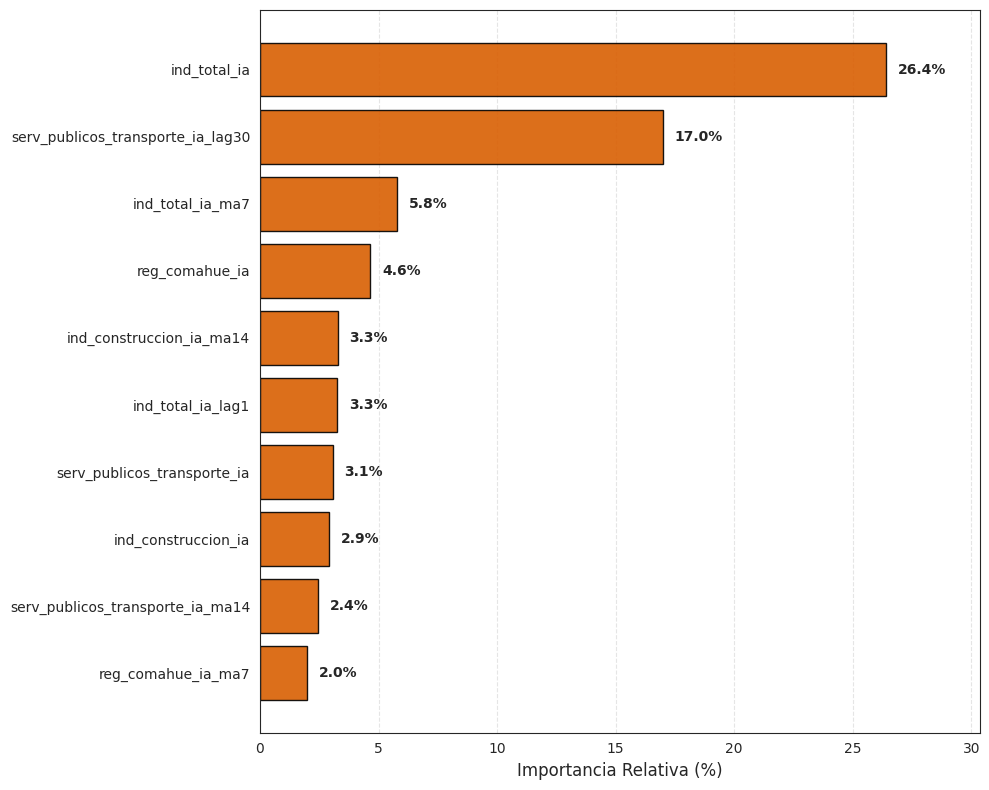

In [114]:
importancias_por_semilla = []
params_importancia = mejores_params_global_final.copy()
params_importancia['importance_type'] = 'gain'

for seed_train in semillas_train:
    lgbm_importancia = LGBMRegressor(**params_importancia, random_state=seed_train, n_jobs=-1, verbose=-1)
    lgbm_importancia.fit(X_train_final, y_train_final, **fit_params_final)
    importancias_por_semilla.append(lgbm_importancia.feature_importances_)

# Promedio del ensamble (Gain absoluto)
importancia_promedio = np.mean(importancias_por_semilla, axis=0)

#  En porcentaje
importancia_porcentual = (importancia_promedio / importancia_promedio.sum()) * 100

nombres_variables = X_train_final.columns

df_importancia_lgbm = pd.DataFrame({
    'Variable': nombres_variables,
    'Gain_Absoluto': importancia_promedio,
    'Importancia_Porcentual': importancia_porcentual
}).sort_values(by='Importancia_Porcentual', ascending=False)

top_10_lgbm = df_importancia_lgbm.head(10).sort_values(by='Importancia_Porcentual', ascending=True)

# Visualización
plt.figure(figsize=(10, 8))

plt.barh(top_10_lgbm['Variable'], top_10_lgbm['Importancia_Porcentual'], color='#d95f02', edgecolor='black', alpha=0.9)

# plt.title('Top 15 Variables Más Importantes (Contribución Porcentual al Gain)\nEnsamble LightGBM Multi-Seed', fontsize=14, pad=15)
plt.xlabel('Importancia Relativa (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Agregamos el valor numérico con el símbolo de porcentaje
for index, value in enumerate(top_10_lgbm['Importancia_Porcentual']):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=10, fontweight='bold')

# Extendemos un poco el límite del eje X para que los textos no se corten
plt.xlim(0, max(top_10_lgbm['Importancia_Porcentual']) * 1.15)
plt.tight_layout()

# Guardar
ruta_grafico_lgbm_porcentual = os.path.join(path_resultados_particular, 'importancia_lgbm_porcentual.png')
plt.savefig(ruta_grafico_lgbm_porcentual, dpi=300)

plt.show()